# Geospatial Analysis 
#### Global, Local Moran's I and Gi*

# Mean - Incidence

Rows in input data: 2,819
Rows retained for Africa: 1,150
Countries retained for Africa: 46

Top countries by summary value:
                Country  summary_value  analysis_year summary_mode
0          Burkina Faso        475.032            NaN         mean
1  Central African Rep.        419.860            NaN         mean
2                 Benin        419.384            NaN         mean
3                  Mali        383.472            NaN         mean
4       Dem. Rep. Congo        379.188            NaN         mean
5            Mozambique        379.092            NaN         mean
6          Sierra Leone        378.232            NaN         mean
7                Guinea        376.248            NaN         mean
8                  Togo        367.600            NaN         mean
9         Côte d'Ivoire        367.048            NaN         mean

Countries matched on map: 46
('WARNING: ', 24, ' is an island (no neighbors)')

Spatial islands under Queen contiguity:
  Index 24: Madag

C:\Users\lubna\anaconda3\Lib\site-packages\esda\moran.py:1398: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:362: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:476: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)


('WARNING: ', 24, ' is an island (no neighbors)')

SIGNIFICANT LISA CLUSTERS

High-High clusters (9 countries):
Benin, Burkina Faso, Cameroon, Côte d'Ivoire, Ghana, Liberia, Niger, Nigeria, Togo

Low-Low clusters (5 countries):
Botswana, Eritrea, Ethiopia, Morocco, South Africa

Low-High outliers (0 countries):
None

High-Low outliers (0 countries):
None

Spatial islands (1 countries):
Madagascar

GETIS--ORD Gi* HOTSPOTS / COLDSPOTS

Hotspots (9 countries):
Benin, Burkina Faso, Cameroon, Côte d'Ivoire, Ghana, Liberia, Niger, Nigeria, Togo

Coldspots (5 countries):
Botswana, Eritrea, Ethiopia, Morocco, South Africa

Spatial islands (1 countries):
Madagascar


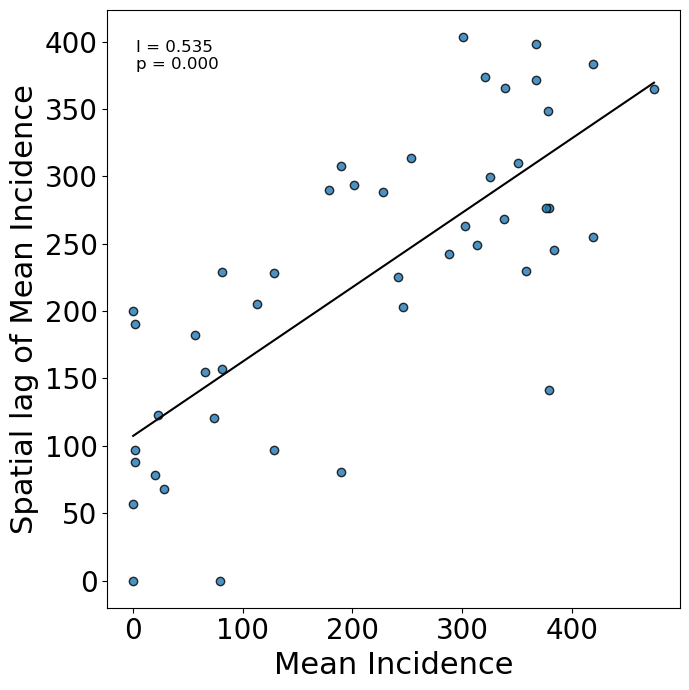

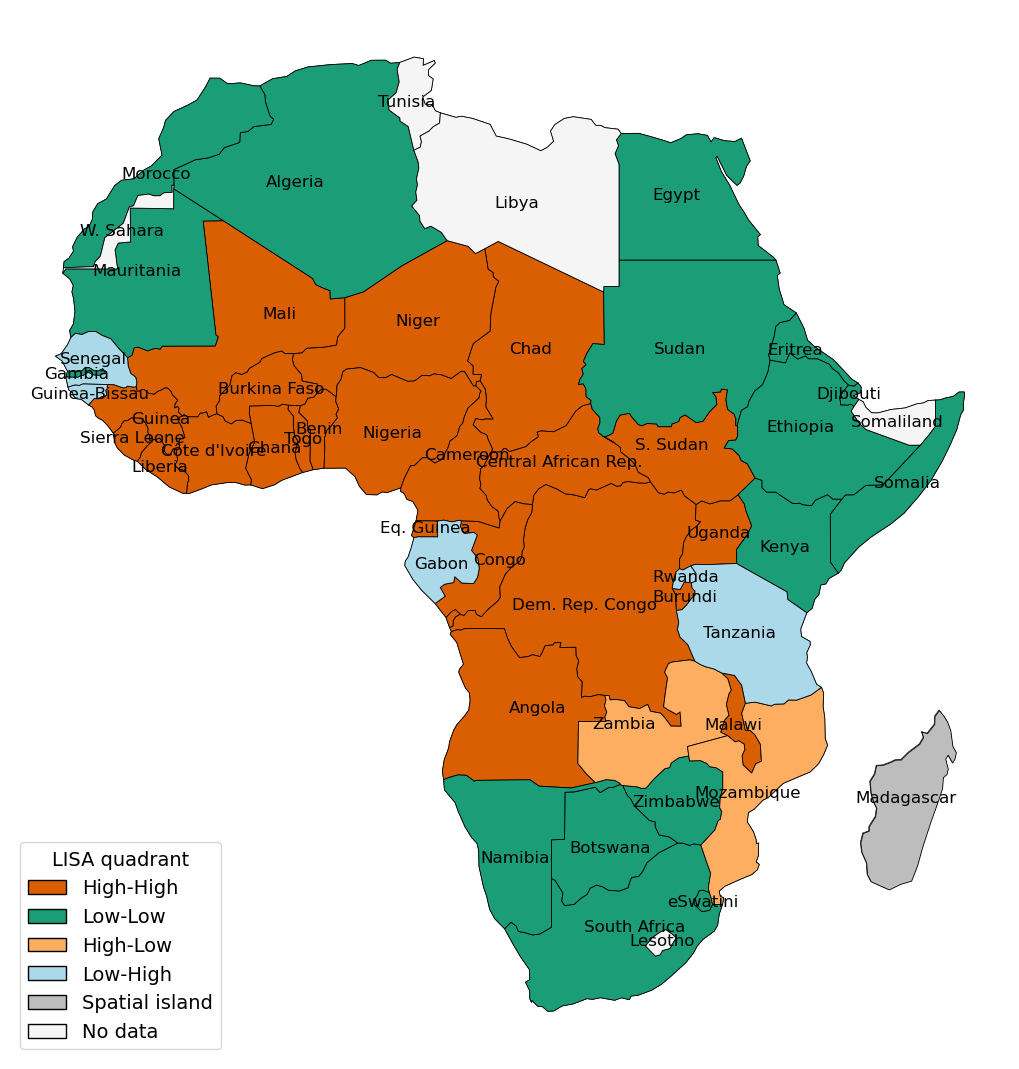

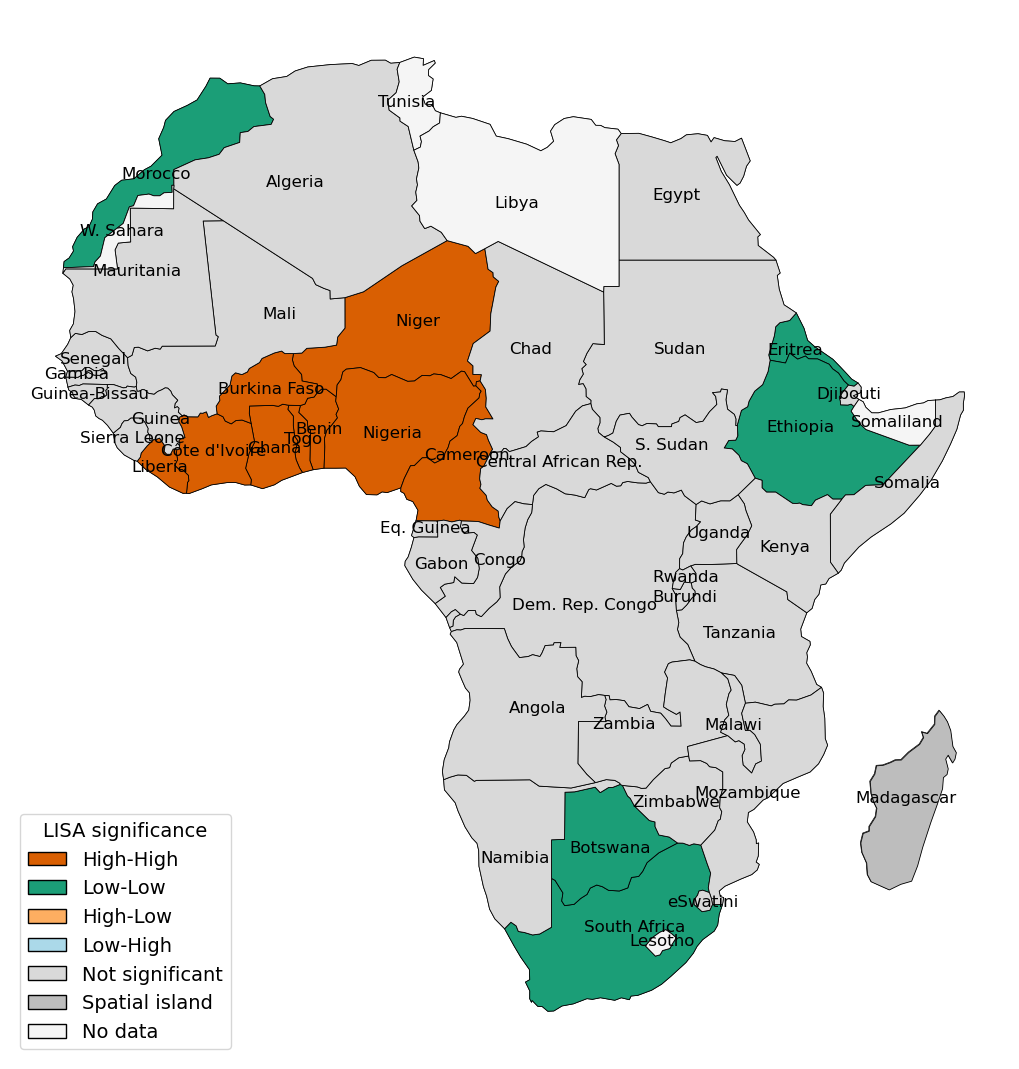

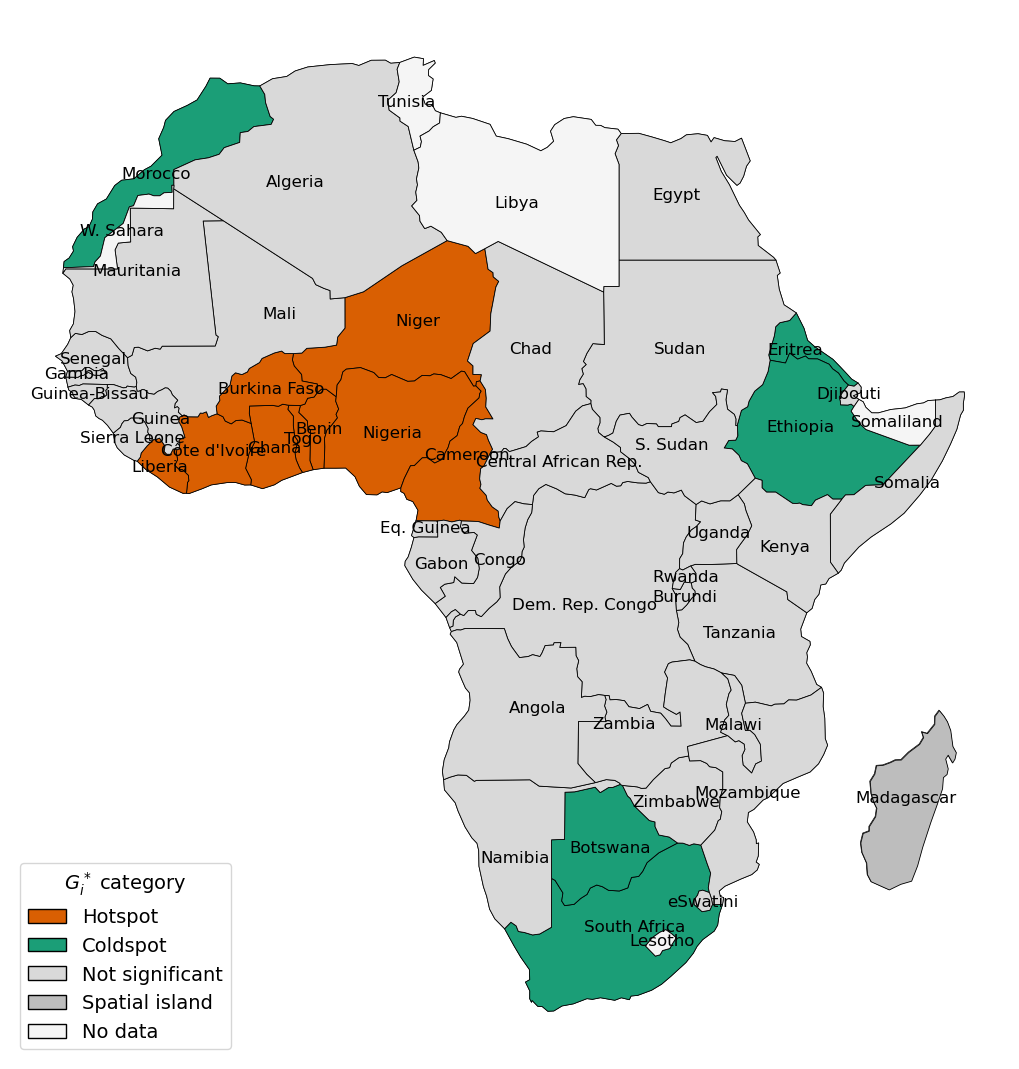

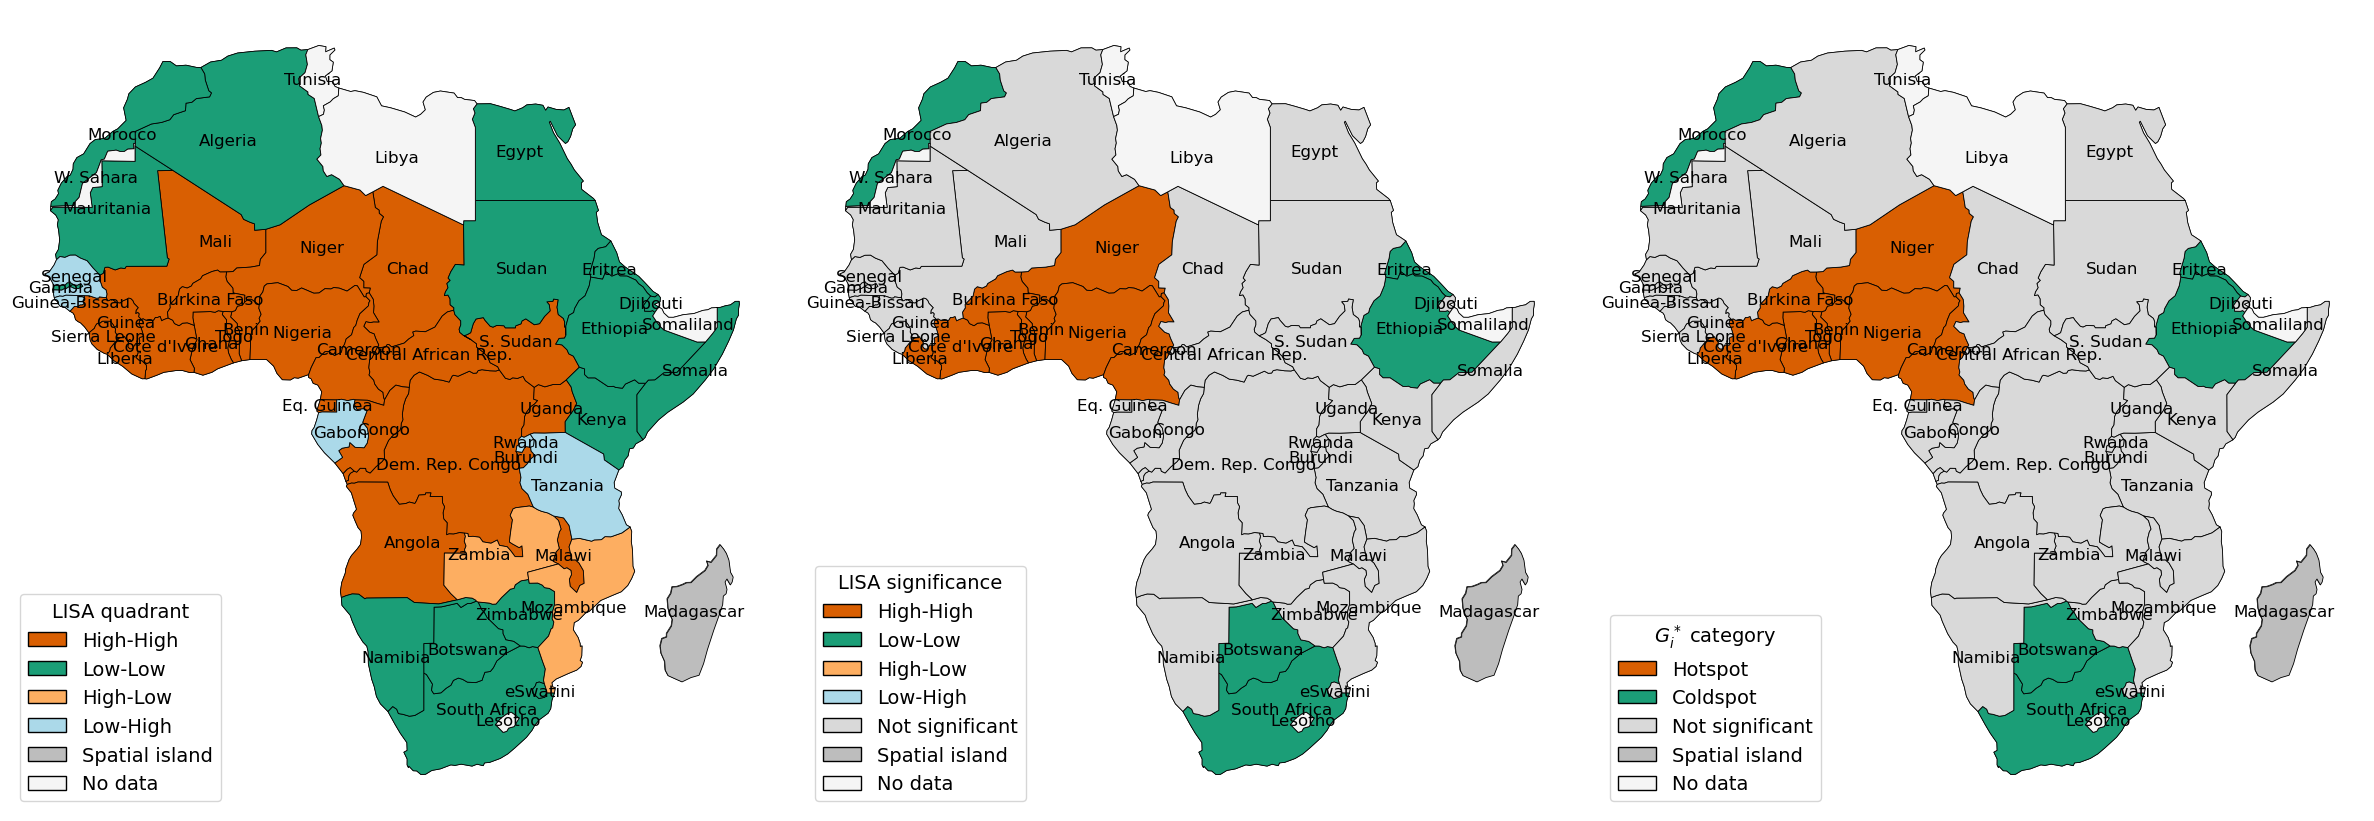


Done. Corrected spatial outputs saved in:
Geospatial/Africa_mean_malaria_est_incidence


In [11]:
# ============================================================
# CORRECTED STANDALONE SPATIAL ANALYSIS PIPELINE
# NO CLUSTERING
##  %pip install package
# Corrections included:
#   1. Explicit handling of spatial islands such as Madagascar
#   2. Correct Getis--Ord Gi* calculation using star=True
#   3. island_weight=np.nan for local inference
#   4. Explicit replacement of island statistics and p-values with NaN
#   5. Correct hotspot/coldspot classification when statistics are missing
#   6. Correct LISA classification for spatial islands
#   7. Spatial-island category added to legends and saved tables
#   8. Duplicate reporting block removed
#
# Supports:
#   - mean over study period
#   - sum over study period
#   - most recent year
#
# Supports:
#   - Africa
#   - whole world
# ============================================================

# ============================================================
# 0) IMPORTS
# ============================================================
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local


# ============================================================
# 1) GLOBAL DISPLAY + STYLE SETTINGS
# ============================================================
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 1000)

warnings.filterwarnings(
    "ignore",
    message="The weights matrix is not fully connected"
)


# ============================================================
# 2) USER SETTINGS
# ============================================================
DATA_PATH = "malaria-burden-all-WHO.csv"
ENCODING = "latin1"

WORLD_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

GEOGRAPHY = "Africa"                 # "Africa" or "World"
VALUE_COL_INPUT = "malaria_est_incidence"
SUMMARY_MODE = "mean"                # "mean", "sum", "latest_year"

# Add the input variable and summary mode to every output filename.
OUTPUT_TAG = f"{VALUE_COL_INPUT}_{SUMMARY_MODE}"

# Clean outcome label for figure axes and annotations.
if "incidence" in VALUE_COL_INPUT.lower():
    OUTCOME_LABEL = "Incidence"
elif "mortality" in VALUE_COL_INPUT.lower():
    OUTCOME_LABEL = "Mortality"
else:
    OUTCOME_LABEL = VALUE_COL_INPUT.replace("_", " ").title()

ALPHA = 0.05
SEED = 42
N_PERM = 9999

# Plot switches
SHOW_LEGEND = True
SHOW_COUNTRY_LABELS = True

# Font settings
LABEL_FS = 22
TICK_FS = 20
LEGEND_FS = 14
MAP_LABEL_FS = 12

OUTDIR_BASE = (
    f"Geospatial/"
    f"{GEOGRAPHY}_{SUMMARY_MODE}_{VALUE_COL_INPUT}"
)
OUTDIR_TABLES = os.path.join(OUTDIR_BASE, "tables")
OUTDIR_FIGS = os.path.join(OUTDIR_BASE, "figures")

os.makedirs(OUTDIR_BASE, exist_ok=True)
os.makedirs(OUTDIR_TABLES, exist_ok=True)
os.makedirs(OUTDIR_FIGS, exist_ok=True)


# ============================================================
# 3) COUNTRY NAME HARMONISATION
# ============================================================
NAME_MAP = {
    "Cabo Verde": "Cape Verde",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Republic of the Congo": "Congo",
    "Eswatini": "eSwatini",
    "The Gambia": "Gambia",
    "Sao Tome and Principe": "São Tomé and Principe",
    "United Republic of Tanzania": "Tanzania",
    "Central African Republic": "Central African Rep.",
    "South Sudan": "S. Sudan",
    "Equatorial Guinea": "Eq. Guinea",
    "Syrian Arab Republic": "Syria",
    "Lao People's Democratic Republic": "Laos",
    "Viet Nam": "Vietnam",
    "Brunei Darussalam": "Brunei",
    "Iran (Islamic Republic of)": "Iran",
    "Russian Federation": "Russia",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Moldova, Republic of": "Moldova",
    "Türkiye": "Turkey",
    "Micronesia (Federated States of)": "Micronesia",
}


# ============================================================
# 4) DATA AND MAP HELPERS
# ============================================================
def load_data(data_path, encoding="latin1"):
    """Load the malaria dataset."""
    return pd.read_csv(data_path, encoding=encoding)


def load_world_map(world_url):
    """Load the Natural Earth country map."""
    world = gpd.read_file(world_url)

    world = world[world["NAME"] != "Antarctica"].copy()
    world = world[
        world.geometry.notna()
        & (~world.geometry.is_empty)
    ].copy()

    return world


def load_analysis_map(world_url, geography="Africa"):
    """Return the full world map and the requested analysis region."""
    world = load_world_map(world_url)

    if geography == "World":
        return world.copy(), world.copy()

    if geography == "Africa":
        region = world[world["CONTINENT"] == "Africa"].copy()
        region = region[
            region.geometry.notna()
            & (~region.geometry.is_empty)
        ].copy()

        return world, region

    raise ValueError("GEOGRAPHY must be 'Africa' or 'World'.")


def harmonise_country_names(
    df,
    country_col="Country",
    name_map=None
):
    """Harmonise country names between the data and map."""
    out = df.copy()
    out[country_col] = out[country_col].astype(str).str.strip()

    if name_map is not None:
        out[country_col] = out[country_col].replace(name_map)

    return out


def filter_df_to_map(
    df,
    map_gdf,
    country_col="Country",
    map_name_col="NAME"
):
    """Retain only countries represented in the selected map."""
    valid_names = set(
        map_gdf[map_name_col]
        .astype(str)
        .str.strip()
    )

    return df[
        df[country_col]
        .astype(str)
        .str.strip()
        .isin(valid_names)
    ].copy()


def compute_country_summary(
    df,
    country_col="Country",
    year_col="Year",
    value_col="malaria_est_incidence",
    summary_mode="mean"
):
    """Calculate a country-level mean, sum, or latest-year value."""
    temp = df[[country_col, year_col, value_col]].copy()

    temp[country_col] = (
        temp[country_col]
        .astype(str)
        .str.strip()
    )
    temp[year_col] = pd.to_numeric(
        temp[year_col],
        errors="coerce"
    )
    temp[value_col] = pd.to_numeric(
        temp[value_col],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=[country_col, year_col, value_col]
    ).copy()

    if summary_mode == "latest_year":
        latest_year = int(temp[year_col].max())

        temp = temp[
            temp[year_col] == latest_year
        ].copy()

        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = latest_year
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "mean":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "sum":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .sum()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    raise ValueError(
        "SUMMARY_MODE must be 'mean', 'sum', or 'latest_year'."
    )


def merge_to_map(
    region_gdf,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
):
    """Merge the country summary values onto the geographic map."""
    return region_gdf.merge(
        country_summary,
        left_on=map_name_col,
        right_on=country_col,
        how="left"
    )


def add_country_labels(
    ax,
    gdf,
    label_col="NAME",
    fontsize=8,
    fontweight="normal",
    color="black"
):
    """Add country names at representative points."""
    if gdf.empty:
        return

    for _, row in gdf.iterrows():
        if pd.isna(row[label_col]):
            continue

        if row.geometry is None or row.geometry.is_empty:
            continue

        point = row.geometry.representative_point()

        ax.text(
            point.x,
            point.y,
            str(row[label_col]),
            fontsize=fontsize,
            ha="center",
            va="center",
            fontweight=fontweight,
            color=color
        )


# ============================================================
# 5) SPATIAL CLASSIFICATION HELPERS
# ============================================================
def lisa_category_sig(row, alpha=0.05):
    """Classify statistically significant local Moran results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if (
        pd.isna(row["local_I"])
        or pd.isna(row["local_p"])
        or pd.isna(row["quadrant"])
    ):
        return "No data"

    if row["local_p"] >= alpha:
        return "Not significant"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "Not significant"
    )


def lisa_quadrant_only(row):
    """Return the LISA quadrant regardless of significance."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if pd.isna(row["quadrant"]):
        return "No data"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "No data"
    )


def gi_category(row, alpha=0.05):
    """Classify statistically significant Getis--Ord Gi* results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    gi_z = row["GiZ"]
    gi_p = row["GiP"]

    if pd.isna(gi_z) or pd.isna(gi_p):
        return "No data"

    if gi_p >= alpha:
        return "Not significant"

    if gi_z > 0:
        return "Hotspot"

    if gi_z < 0:
        return "Coldspot"

    return "Not significant"


# ============================================================
# 6) SPATIAL STATISTICS
# ============================================================
def compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=0.05,
    seed=42,
    n_perm=9999
):
    """
    Calculate Global Moran's I, Local Moran's I, and Getis--Ord Gi*.

    Spatial islands are retained in the output but excluded from
    local inferential interpretation because Queen contiguity
    provides them with no geographic neighbors.
    """
    region_stats = region_map.dropna(
        subset=[value_col]
    ).copy()

    region_stats = region_stats[
        region_stats.geometry.notna()
        & (~region_stats.geometry.is_empty)
    ].copy()

    region_stats = (
        region_stats
        .sort_values("NAME")
        .reset_index(drop=True)
    )

    if len(region_stats) < 3:
        raise ValueError(
            "At least three countries with valid geometry and "
            "outcome data are required."
        )

    # --------------------------------------------------------
    # Queen-contiguity spatial weights
    # --------------------------------------------------------
    w = Queen.from_dataframe(
        region_stats,
        use_index=False
    )

    w.transform = "r"

    y = region_stats[value_col].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Identify spatial islands
    # --------------------------------------------------------
    island_indices = set(w.islands)

    region_stats["Spatial_Island"] = [
        idx in island_indices
        for idx in range(len(region_stats))
    ]

    print("\nSpatial islands under Queen contiguity:")

    if island_indices:
        for idx in sorted(island_indices):
            print(
                f"  Index {idx}: "
                f"{region_stats.loc[idx, 'NAME']}"
            )
    else:
        print("  None")

    # --------------------------------------------------------
    # Global Moran's I
    # --------------------------------------------------------
    moran = Moran(
        y,
        w,
        permutations=n_perm
    )

    # --------------------------------------------------------
    # Local Moran's I
    # --------------------------------------------------------
    lisa_obj = Moran_Local(
        y,
        w,
        permutations=n_perm,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["local_I"] = lisa_obj.Is
    region_stats["local_p"] = lisa_obj.p_sim
    region_stats["quadrant"] = lisa_obj.q

    # Explicitly remove invalid island results
    island_mask = region_stats["Spatial_Island"]

    region_stats.loc[
        island_mask,
        ["local_I", "local_p", "quadrant"]
    ] = np.nan

    region_stats["LISA_Category_Sig"] = (
        region_stats.apply(
            lambda row: lisa_category_sig(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    region_stats["LISA_Category_All"] = (
        region_stats.apply(
            lisa_quadrant_only,
            axis=1
        )
    )

    # --------------------------------------------------------
    # Local Getis--Ord Gi*
    # star=True is required for Gi*
    # --------------------------------------------------------
    g_local = G_Local(
        y,
        w,
        transform="R",
        permutations=n_perm,
        star=True,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["GiZ"] = g_local.Zs
    region_stats["GiP"] = g_local.p_sim

    # Explicitly remove invalid island results
    region_stats.loc[
        island_mask,
        ["GiZ", "GiP"]
    ] = np.nan

    region_stats["Gi_Category"] = (
        region_stats.apply(
            lambda row: gi_category(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    # --------------------------------------------------------
    # Merge LISA results back to full regional map
    # --------------------------------------------------------
    region_lisa = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "local_I",
                "local_p",
                "quadrant",
                "LISA_Category_Sig",
                "LISA_Category_All"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_lisa["LISA_Category_Sig"] = (
        region_lisa["LISA_Category_Sig"]
        .fillna("No data")
    )

    region_lisa["LISA_Category_All"] = (
        region_lisa["LISA_Category_All"]
        .fillna("No data")
    )

    # --------------------------------------------------------
    # Merge Gi* results back to full regional map
    # --------------------------------------------------------
    region_gi = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "GiZ",
                "GiP",
                "Gi_Category"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_gi["Gi_Category"] = (
        region_gi["Gi_Category"]
        .fillna("No data")
    )

    return {
        "region_stats": region_stats,
        "w": w,
        "y": y,
        "moran": moran,
        "lisa_obj": lisa_obj,
        "g_local": g_local,
        "region_lisa": region_lisa,
        "region_gi": region_gi,
        "island_indices": sorted(island_indices)
    }


# ============================================================
# 7) PLOTTING FUNCTIONS
# ============================================================
def plot_moran_scatter(
    y,
    w,
    moran,
    xlabel,
    ylabel,
    out_png,
    out_pdf,
    figsize=(7, 7)
):
    """Plot the global Moran scatterplot."""
    lag_y = w.sparse.dot(y)

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        y,
        lag_y,
        edgecolor="black",
        alpha=0.8
    )

    coef = np.polyfit(y, lag_y, 1)
    x_line = np.linspace(
        y.min(),
        y.max(),
        100
    )
    y_line = (
        coef[0] * x_line
        + coef[1]
    )

    ax.plot(
        x_line,
        y_line,
        color="black",
        linewidth=1.5
    )

    ax.set_xlabel(
        xlabel,
        fontsize=LABEL_FS
    )
    ax.set_ylabel(
        ylabel,
        fontsize=LABEL_FS
    )

    ax.tick_params(
        axis="x",
        labelsize=TICK_FS
    )
    ax.tick_params(
        axis="y",
        labelsize=TICK_FS
    )

    ax.grid(False)

    ax.text(
        0.05,
        0.95,
        (
            f"I = {moran.I:.3f}\n"
            f"p = {moran.p_sim:.3f}"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12
    )

    plt.tight_layout()
    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_quadrant_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot all LISA quadrants, regardless of significance."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_All"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA quadrant",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_significance_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant LISA clusters and outliers."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_Sig"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA significance",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_gi_map(
    base_gdf,
    region_gi,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant Getis--Ord Gi* results."""
    color_map = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_gi[
            region_gi["Gi_Category"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_gi[
            region_gi.geometry.notna()
            & (~region_gi.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title=r"$G_i^*$ category",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_combined_lisa_sig_gi(
    base_gdf,
    region_lisa,
    region_gi,
    out_png,
    out_pdf,
    figsize=(24, 10),
    show_legend=True,
    show_labels=True
):
    """Plot LISA quadrant, significant LISA, and Gi* maps together."""
    lisa_quad_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    lisa_sig_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    gi_colors = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize
    )

    panels = [
        (
            axes[0],
            region_lisa,
            "LISA_Category_All",
            lisa_quad_colors,
            "LISA quadrant"
        ),
        (
            axes[1],
            region_lisa,
            "LISA_Category_Sig",
            lisa_sig_colors,
            "LISA significance"
        ),
        (
            axes[2],
            region_gi,
            "Gi_Category",
            gi_colors,
            r"$G_i^*$ category"
        )
    ]

    for ax, gdf, category_col, color_map, legend_title in panels:
        base_gdf.plot(
            ax=ax,
            color="white",
            edgecolor="black",
            linewidth=0.5,
            aspect=1
        )

        for category, color in color_map.items():
            subset = gdf[
                gdf[category_col] == category
            ].copy()

            subset = subset[
                subset.geometry.notna()
                & (~subset.geometry.is_empty)
            ].copy()

            if not subset.empty:
                subset.plot(
                    ax=ax,
                    color=color,
                    edgecolor="black",
                    linewidth=0.6,
                    aspect=1
                )

        if show_labels:
            label_gdf = gdf[
                gdf.geometry.notna()
                & (~gdf.geometry.is_empty)
            ].copy()

            add_country_labels(
                ax,
                label_gdf,
                label_col="NAME",
                fontsize=MAP_LABEL_FS
            )

        if show_legend:
            legend_elements = [
                Patch(
                    facecolor=color,
                    edgecolor="black",
                    label=category
                )
                for category, color in color_map.items()
            ]

            ax.legend(
                handles=legend_elements,
                loc="lower left",
                fontsize=LEGEND_FS,
                frameon=True,
                title=legend_title,
                title_fontsize=LEGEND_FS
            )

        ax.set_axis_off()

    plt.tight_layout()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


# ============================================================
# 8) LOAD DATA
# ============================================================
df = load_data(
    DATA_PATH,
    ENCODING
)

df = harmonise_country_names(
    df,
    country_col="Country",
    name_map=NAME_MAP
)

required_cols = [
    "Country",
    "Year",
    VALUE_COL_INPUT
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Input data is missing required columns: {missing_cols}"
    )

world_full, analysis_map = load_analysis_map(
    WORLD_URL,
    GEOGRAPHY
)

df_use = filter_df_to_map(
    df,
    analysis_map,
    country_col="Country",
    map_name_col="NAME"
)

print(f"Rows in input data: {len(df):,}")
print(
    f"Rows retained for {GEOGRAPHY}: "
    f"{len(df_use):,}"
)
print(
    f"Countries retained for {GEOGRAPHY}: "
    f"{df_use['Country'].nunique()}"
)


# ============================================================
# 9) COUNTRY SUMMARY
# ============================================================
country_summary = compute_country_summary(
    df_use,
    country_col="Country",
    year_col="Year",
    value_col=VALUE_COL_INPUT,
    summary_mode=SUMMARY_MODE
)

country_summary.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"country_summary_{OUTPUT_TAG}.csv"
    ),
    index=False
)

print("\nTop countries by summary value:")
print(country_summary.head(10))


# ============================================================
# 10) MERGE TO MAP
# ============================================================
region_map = merge_to_map(
    analysis_map,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
)

region_map.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"map_attributes_{OUTPUT_TAG}.csv"
    ),
    index=False
)

print(
    "\nCountries matched on map:",
    region_map["summary_value"]
    .notna()
    .sum()
)


# ============================================================
# 11) SPATIAL ANALYSIS
# ============================================================
spatial_results = compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=ALPHA,
    seed=SEED,
    n_perm=N_PERM
)

region_stats = spatial_results["region_stats"]
w = spatial_results["w"]
y = spatial_results["y"]
moran = spatial_results["moran"]
region_lisa = spatial_results["region_lisa"]
region_gi = spatial_results["region_gi"]


# ============================================================
# 12) SAVE TABLES
# ============================================================
pd.DataFrame(
    {
        "Metric": [
            "Global Moran's I",
            "Permutation p-value"
        ],
        "Value": [
            moran.I,
            moran.p_sim
        ]
    }
).to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"global_morans_I_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_stats.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"region_stats_with_local_stats_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_lisa.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"lisa_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_gi.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"gi_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

quadrant_map = {
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
}

lisa_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "Quadrant": region_stats["quadrant"],
        "Quadrant_Label": (
            region_stats["quadrant"]
            .map(quadrant_map)
        ),
        "Local_I": region_stats["local_I"],
        "p_value": region_stats["local_p"],
        "Final_Category_Sig": (
            region_stats["LISA_Category_Sig"]
        ),
        "Final_Category_All": (
            region_stats["LISA_Category_All"]
        )
    }
)

lisa_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"lisa_diagnostic_table_{OUTPUT_TAG}.csv"
    ),
    index=False
)

gi_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "GiZ": region_stats["GiZ"],
        "GiP": region_stats["GiP"],
        "Gi_Category": region_stats["Gi_Category"]
    }
)

gi_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"gi_diagnostic_table_{OUTPUT_TAG}.csv"
    ),
    index=False
)


# ============================================================
# 13) PRINT AND SAVE SIGNIFICANT SPATIAL GROUPS
# ============================================================
print("\n" + "=" * 70)
print("SIGNIFICANT LISA CLUSTERS")
print("=" * 70)

hh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

ll_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

hl_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lisa_islands = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHigh-High clusters ({len(hh_countries)} countries):"
)
print(", ".join(hh_countries) or "None")

print(
    f"\nLow-Low clusters ({len(ll_countries)} countries):"
)
print(", ".join(ll_countries) or "None")

print(
    f"\nLow-High outliers ({len(lh_countries)} countries):"
)
print(", ".join(lh_countries) or "None")

print(
    f"\nHigh-Low outliers ({len(hl_countries)} countries):"
)
print(", ".join(hl_countries) or "None")

print(
    f"\nSpatial islands ({len(lisa_islands)} countries):"
)
print(", ".join(lisa_islands) or "None")

print("\n" + "=" * 70)
print("GETIS--ORD Gi* HOTSPOTS / COLDSPOTS")
print("=" * 70)

hotspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Hotspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

coldspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Coldspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

gi_islands = (
    region_gi[
        region_gi["Gi_Category"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHotspots ({len(hotspot_countries)} countries):"
)
print(", ".join(hotspot_countries) or "None")

print(
    f"\nColdspots ({len(coldspot_countries)} countries):"
)
print(", ".join(coldspot_countries) or "None")

print(
    f"\nSpatial islands ({len(gi_islands)} countries):"
)
print(", ".join(gi_islands) or "None")

with open(
    os.path.join(
        OUTDIR_TABLES,
        f"significant_spatial_groups_{OUTPUT_TAG}.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write("SIGNIFICANT LISA CLUSTERS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"High-High ({len(hh_countries)} countries)\n"
    )
    file.write(
        (", ".join(hh_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-Low ({len(ll_countries)} countries)\n"
    )
    file.write(
        (", ".join(ll_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-High ({len(lh_countries)} countries)\n"
    )
    file.write(
        (", ".join(lh_countries) or "None") + "\n\n"
    )

    file.write(
        f"High-Low ({len(hl_countries)} countries)\n"
    )
    file.write(
        (", ".join(hl_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(lisa_islands)} countries)\n"
    )
    file.write(
        (", ".join(lisa_islands) or "None") + "\n\n"
    )

    file.write("GETIS--ORD Gi* RESULTS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"Hotspots ({len(hotspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(hotspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Coldspots ({len(coldspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(coldspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(gi_islands)} countries)\n"
    )
    file.write(
        (", ".join(gi_islands) or "None") + "\n"
    )


# ============================================================
# 14) BUILD AXIS LABELS
# ============================================================
if SUMMARY_MODE == "latest_year":
    latest_year = int(
        country_summary["analysis_year"]
        .dropna()
        .iloc[0]
    )

    legend_label = f"{OUTCOME_LABEL} in {latest_year}"
else:
    latest_year = None

    summary_label_map = {
        "mean": "Mean",
        "sum": "Total"
    }

    summary_label = summary_label_map.get(
        SUMMARY_MODE,
        SUMMARY_MODE.replace("_", " ").title()
    )

    legend_label = f"{summary_label} {OUTCOME_LABEL}"

figsize_main = (
    (10, 12)
    if GEOGRAPHY == "Africa"
    else (20, 10)
)


# ============================================================
# 15) MORAN SCATTERPLOT
# ============================================================
plot_moran_scatter(
    y=y,
    w=w,
    moran=moran,
    xlabel=legend_label,
    ylabel=f"Spatial lag of {legend_label}",
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"moran_scatter_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"moran_scatter_{OUTPUT_TAG}.pdf"
    ),
    figsize=(7, 7)
)


# ============================================================
# 16) LISA QUADRANT MAP
# ============================================================
plot_lisa_quadrant_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"lisa_quadrant_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"lisa_quadrant_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 17) LISA SIGNIFICANCE MAP
# ============================================================
plot_lisa_significance_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"lisa_significance_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"lisa_significance_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 18) GETIS--ORD Gi* MAP
# ============================================================
plot_gi_map(
    base_gdf=analysis_map,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"gi_star_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"gi_star_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 19) COMBINED LISA + LISA SIGNIFICANCE + Gi* FIGURE
# ============================================================
plot_combined_lisa_sig_gi(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"combined_lisa_sig_gi_star_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"combined_lisa_sig_gi_star_{OUTPUT_TAG}.pdf"
    ),
    figsize=(
        (24, 10)
        if GEOGRAPHY == "Africa"
        else (30, 10)
    ),
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 20) WORKFLOW SUMMARY
# ============================================================
with open(
    os.path.join(
        OUTDIR_BASE,
        f"workflow_summary_{OUTPUT_TAG}.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write(
        "Corrected spatial-only analysis completed.\n\n"
    )

    file.write(f"Input file: {DATA_PATH}\n")
    file.write(f"Geography: {GEOGRAPHY}\n")
    file.write(f"Variable: {VALUE_COL_INPUT}\n")
    file.write(f"Summary mode: {SUMMARY_MODE}\n")

    if latest_year is not None:
        file.write(f"Analysis year: {latest_year}\n")

    file.write(f"Alpha: {ALPHA}\n")
    file.write(f"Seed: {SEED}\n")
    file.write(f"Permutations: {N_PERM}\n")
    file.write("Spatial weights: Queen contiguity\n")
    file.write("Local Getis--Ord statistic: Gi* (star=True)\n")
    file.write(
        "Spatial-island treatment: retained but local "
        "statistics set to missing\n"
    )
    file.write(f"Show legend: {SHOW_LEGEND}\n")
    file.write(
        f"Show country labels: {SHOW_COUNTRY_LABELS}\n\n"
    )

    file.write("Outputs:\n")
    file.write(f"- country_summary_{OUTPUT_TAG}.csv\n")
    file.write(f"- map_attributes_{OUTPUT_TAG}.csv\n")
    file.write(f"- global_morans_I_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- region_stats_with_local_stats_{OUTPUT_TAG}.csv\n")
    file.write(f"- lisa_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- gi_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- lisa_diagnostic_table_{OUTPUT_TAG}.csv\n")
    file.write(f"- gi_diagnostic_table_{OUTPUT_TAG}.csv\n")
    file.write(f"- significant_spatial_groups_{OUTPUT_TAG}.txt\n")
    file.write(f"- moran_scatter_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- lisa_quadrant_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- lisa_significance_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- gi_star_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- combined_lisa_sig_gi_star_{OUTPUT_TAG}.png/.pdf\n")

print(
    f"\nDone. Corrected spatial outputs saved in:\n"
    f"{OUTDIR_BASE}"
)


# Latest Year - Incidence

Rows in input data: 2,819
Rows retained for Africa: 1,150
Countries retained for Africa: 46

Top countries by summary value:
                Country  summary_value  analysis_year summary_mode
0                 Benin          354.3           2024  latest_year
1          Burkina Faso          353.5           2024  latest_year
2                  Mali          346.2           2024  latest_year
3  Central African Rep.          343.8           2024  latest_year
4       Dem. Rep. Congo          321.9           2024  latest_year
5               Burundi          314.9           2024  latest_year
6                 Niger          305.1           2024  latest_year
7            Mozambique          295.1           2024  latest_year
8                Malawi          294.5           2024  latest_year
9               Nigeria          294.3           2024  latest_year

Countries matched on map: 46
('WARNING: ', 24, ' is an island (no neighbors)')

Spatial islands under Queen contiguity:
  Index 24: Madag

C:\Users\lubna\anaconda3\Lib\site-packages\esda\moran.py:1398: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:362: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:476: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)


('WARNING: ', 24, ' is an island (no neighbors)')

SIGNIFICANT LISA CLUSTERS

High-High clusters (10 countries):
Benin, Burkina Faso, Cameroon, Congo, Côte d'Ivoire, Dem. Rep. Congo, Ghana, Niger, Nigeria, Togo

Low-Low clusters (3 countries):
Botswana, Morocco, South Africa

Low-High outliers (0 countries):
None

High-Low outliers (0 countries):
None

Spatial islands (1 countries):
Madagascar

GETIS--ORD Gi* HOTSPOTS / COLDSPOTS

Hotspots (10 countries):
Benin, Burkina Faso, Cameroon, Congo, Côte d'Ivoire, Dem. Rep. Congo, Ghana, Niger, Nigeria, Togo

Coldspots (3 countries):
Botswana, Morocco, South Africa

Spatial islands (1 countries):
Madagascar


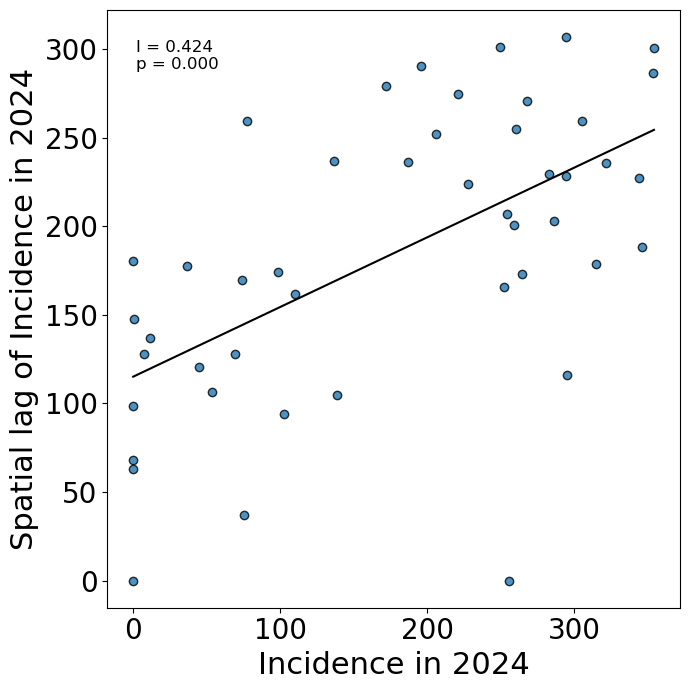

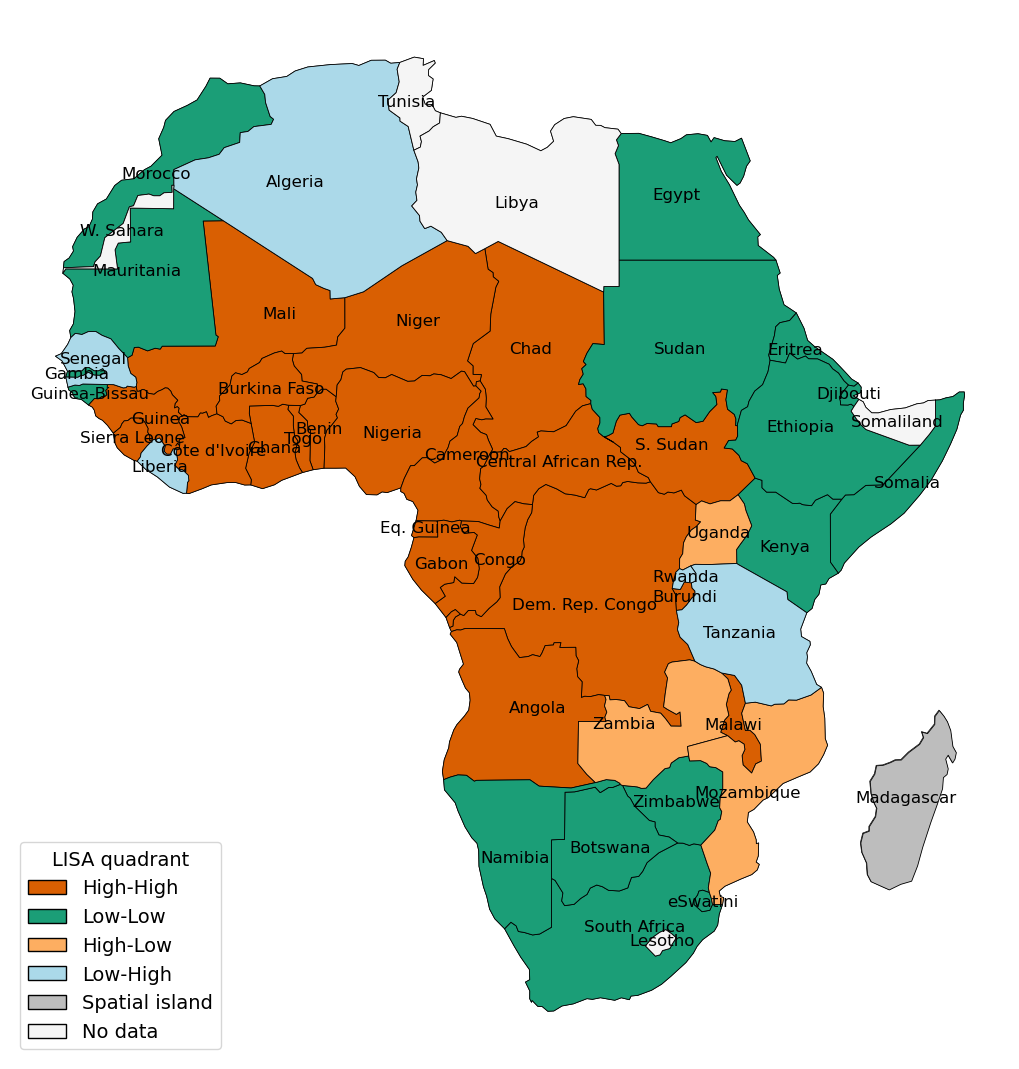

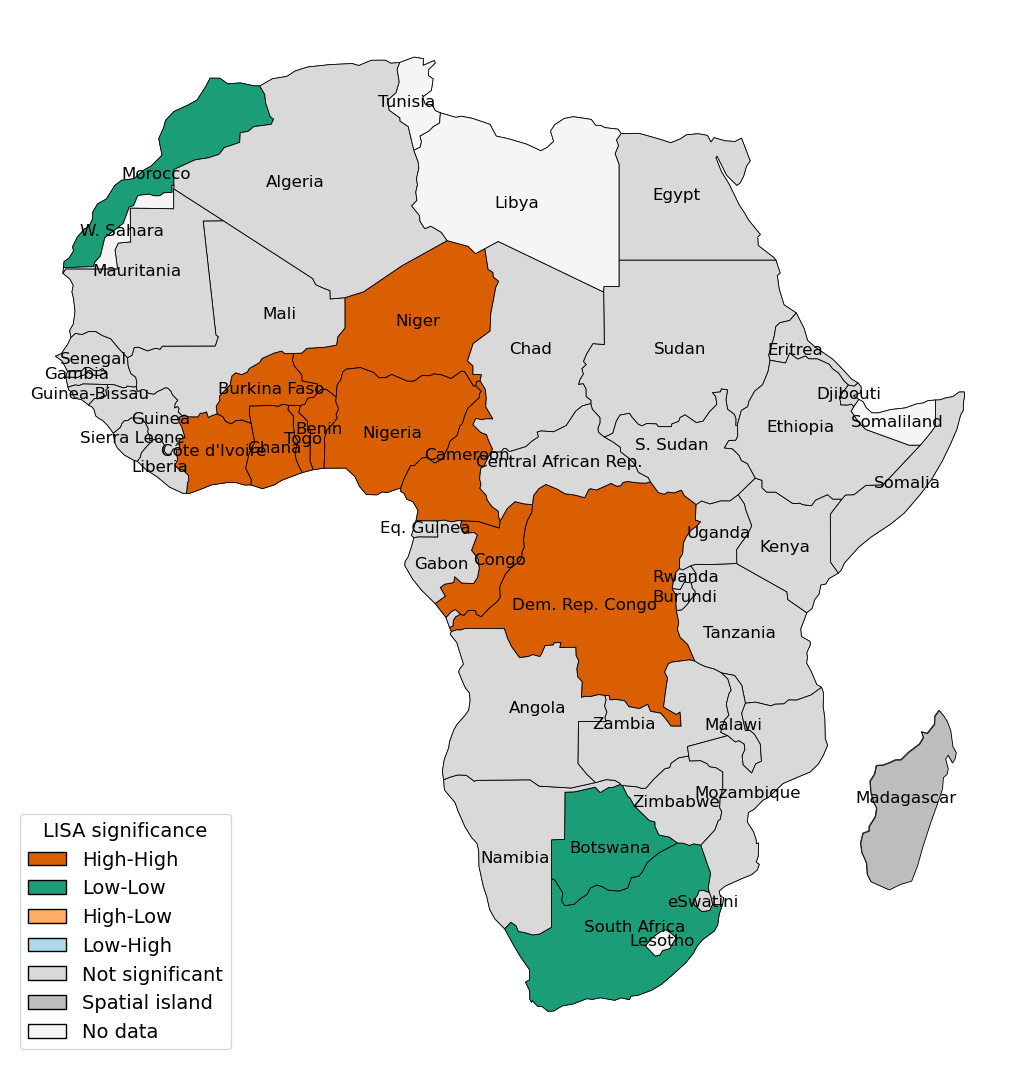

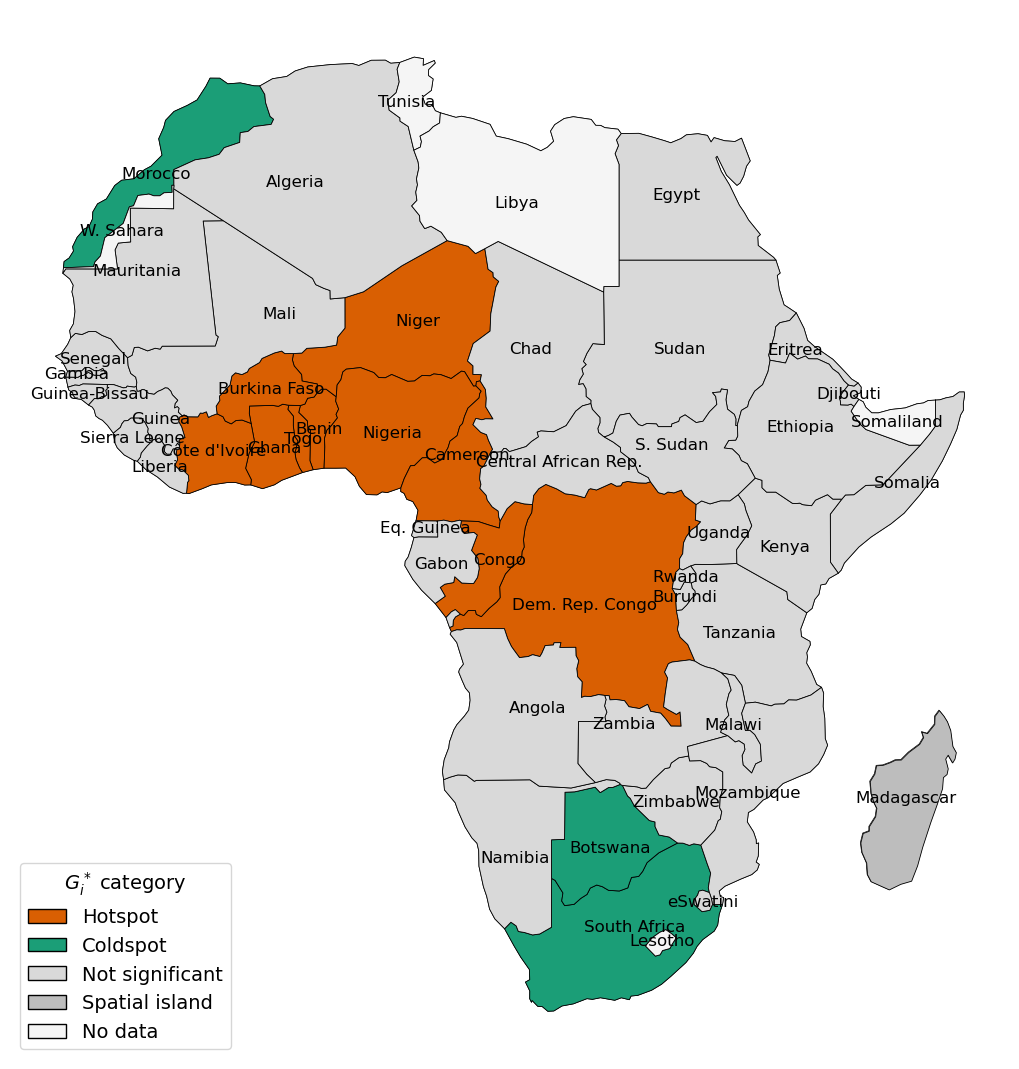

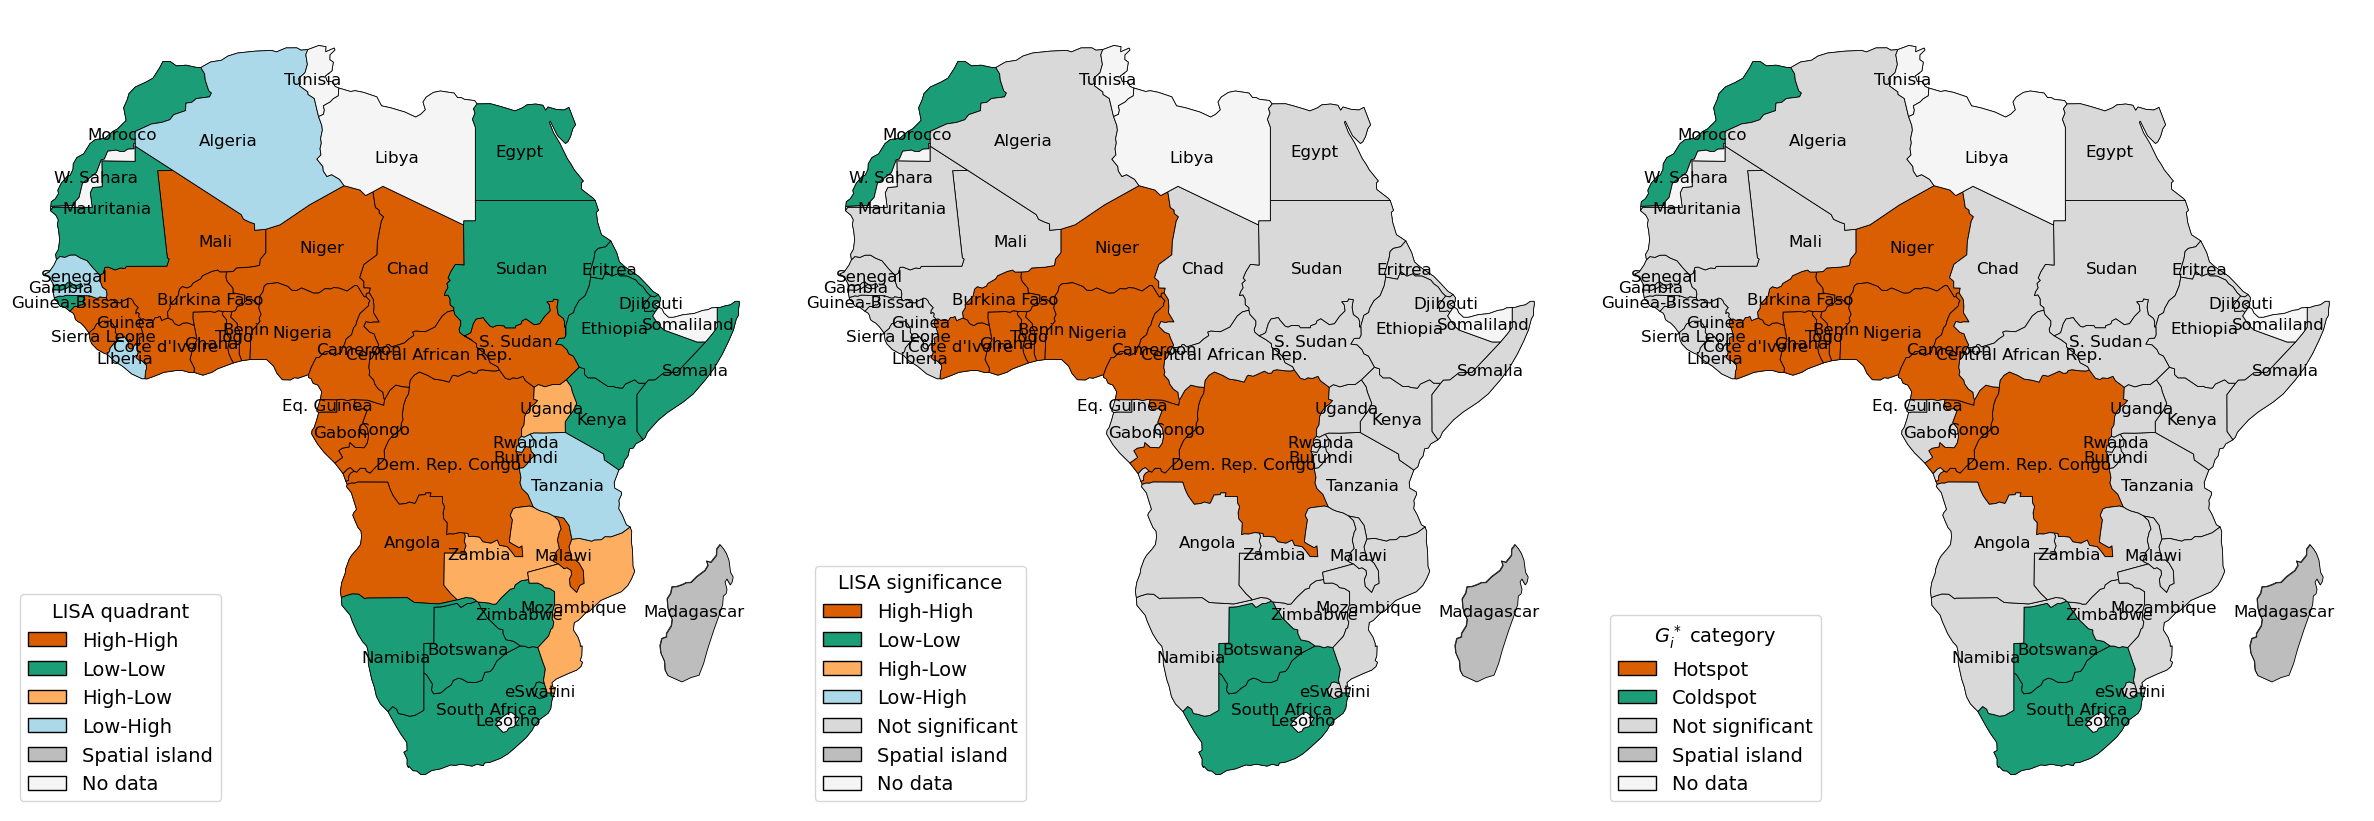


Done. Corrected spatial outputs saved in:
Geospatial/Africa_latest_year_malaria_est_incidence


In [4]:
# ============================================================
# CORRECTED STANDALONE SPATIAL ANALYSIS PIPELINE
# NO CLUSTERING
##  %pip install package
# Corrections included:
#   1. Explicit handling of spatial islands such as Madagascar
#   2. Correct Getis--Ord Gi* calculation using star=True
#   3. island_weight=np.nan for local inference
#   4. Explicit replacement of island statistics and p-values with NaN
#   5. Correct hotspot/coldspot classification when statistics are missing
#   6. Correct LISA classification for spatial islands
#   7. Spatial-island category added to legends and saved tables
#   8. Duplicate reporting block removed
#
# Supports:
#   - mean over study period
#   - sum over study period
#   - most recent year
#
# Supports:
#   - Africa
#   - whole world
# ============================================================

# ============================================================
# 0) IMPORTS
# ============================================================
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local


# ============================================================
# 1) GLOBAL DISPLAY + STYLE SETTINGS
# ============================================================
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 1000)

warnings.filterwarnings(
    "ignore",
    message="The weights matrix is not fully connected"
)


# ============================================================
# 2) USER SETTINGS
# ============================================================
DATA_PATH = "malaria-burden-all-WHO.csv"
ENCODING = "latin1"

WORLD_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

GEOGRAPHY = "Africa"                 # "Africa" or "World"
VALUE_COL_INPUT = "malaria_est_incidence"
SUMMARY_MODE = "latest_year"                # "mean", "sum", "latest_year"

# Add the input variable and summary mode to every output filename.
OUTPUT_TAG = f"{VALUE_COL_INPUT}_{SUMMARY_MODE}"

# Clean outcome label for figure axes and annotations.
if "incidence" in VALUE_COL_INPUT.lower():
    OUTCOME_LABEL = "Incidence"
elif "mortality" in VALUE_COL_INPUT.lower():
    OUTCOME_LABEL = "Mortality"
else:
    OUTCOME_LABEL = VALUE_COL_INPUT.replace("_", " ").title()

ALPHA = 0.05
SEED = 42
N_PERM = 9999

# Plot switches
SHOW_LEGEND = True
SHOW_COUNTRY_LABELS = True

# Font settings
LABEL_FS = 22
TICK_FS = 20
LEGEND_FS = 14
MAP_LABEL_FS = 12

OUTDIR_BASE = (
    f"Geospatial/"
    f"{GEOGRAPHY}_{SUMMARY_MODE}_{VALUE_COL_INPUT}"
)
OUTDIR_TABLES = os.path.join(OUTDIR_BASE, "tables")
OUTDIR_FIGS = os.path.join(OUTDIR_BASE, "figures")

os.makedirs(OUTDIR_BASE, exist_ok=True)
os.makedirs(OUTDIR_TABLES, exist_ok=True)
os.makedirs(OUTDIR_FIGS, exist_ok=True)


# ============================================================
# 3) COUNTRY NAME HARMONISATION
# ============================================================
NAME_MAP = {
    "Cabo Verde": "Cape Verde",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Republic of the Congo": "Congo",
    "Eswatini": "eSwatini",
    "The Gambia": "Gambia",
    "Sao Tome and Principe": "São Tomé and Principe",
    "United Republic of Tanzania": "Tanzania",
    "Central African Republic": "Central African Rep.",
    "South Sudan": "S. Sudan",
    "Equatorial Guinea": "Eq. Guinea",
    "Syrian Arab Republic": "Syria",
    "Lao People's Democratic Republic": "Laos",
    "Viet Nam": "Vietnam",
    "Brunei Darussalam": "Brunei",
    "Iran (Islamic Republic of)": "Iran",
    "Russian Federation": "Russia",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Moldova, Republic of": "Moldova",
    "Türkiye": "Turkey",
    "Micronesia (Federated States of)": "Micronesia",
}


# ============================================================
# 4) DATA AND MAP HELPERS
# ============================================================
def load_data(data_path, encoding="latin1"):
    """Load the malaria dataset."""
    return pd.read_csv(data_path, encoding=encoding)


def load_world_map(world_url):
    """Load the Natural Earth country map."""
    world = gpd.read_file(world_url)

    world = world[world["NAME"] != "Antarctica"].copy()
    world = world[
        world.geometry.notna()
        & (~world.geometry.is_empty)
    ].copy()

    return world


def load_analysis_map(world_url, geography="Africa"):
    """Return the full world map and the requested analysis region."""
    world = load_world_map(world_url)

    if geography == "World":
        return world.copy(), world.copy()

    if geography == "Africa":
        region = world[world["CONTINENT"] == "Africa"].copy()
        region = region[
            region.geometry.notna()
            & (~region.geometry.is_empty)
        ].copy()

        return world, region

    raise ValueError("GEOGRAPHY must be 'Africa' or 'World'.")


def harmonise_country_names(
    df,
    country_col="Country",
    name_map=None
):
    """Harmonise country names between the data and map."""
    out = df.copy()
    out[country_col] = out[country_col].astype(str).str.strip()

    if name_map is not None:
        out[country_col] = out[country_col].replace(name_map)

    return out


def filter_df_to_map(
    df,
    map_gdf,
    country_col="Country",
    map_name_col="NAME"
):
    """Retain only countries represented in the selected map."""
    valid_names = set(
        map_gdf[map_name_col]
        .astype(str)
        .str.strip()
    )

    return df[
        df[country_col]
        .astype(str)
        .str.strip()
        .isin(valid_names)
    ].copy()


def compute_country_summary(
    df,
    country_col="Country",
    year_col="Year",
    value_col="malaria_est_incidence",
    summary_mode="mean"
):
    """Calculate a country-level mean, sum, or latest-year value."""
    temp = df[[country_col, year_col, value_col]].copy()

    temp[country_col] = (
        temp[country_col]
        .astype(str)
        .str.strip()
    )
    temp[year_col] = pd.to_numeric(
        temp[year_col],
        errors="coerce"
    )
    temp[value_col] = pd.to_numeric(
        temp[value_col],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=[country_col, year_col, value_col]
    ).copy()

    if summary_mode == "latest_year":
        latest_year = int(temp[year_col].max())

        temp = temp[
            temp[year_col] == latest_year
        ].copy()

        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = latest_year
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "mean":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "sum":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .sum()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    raise ValueError(
        "SUMMARY_MODE must be 'mean', 'sum', or 'latest_year'."
    )


def merge_to_map(
    region_gdf,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
):
    """Merge the country summary values onto the geographic map."""
    return region_gdf.merge(
        country_summary,
        left_on=map_name_col,
        right_on=country_col,
        how="left"
    )


def add_country_labels(
    ax,
    gdf,
    label_col="NAME",
    fontsize=8,
    fontweight="normal",
    color="black"
):
    """Add country names at representative points."""
    if gdf.empty:
        return

    for _, row in gdf.iterrows():
        if pd.isna(row[label_col]):
            continue

        if row.geometry is None or row.geometry.is_empty:
            continue

        point = row.geometry.representative_point()

        ax.text(
            point.x,
            point.y,
            str(row[label_col]),
            fontsize=fontsize,
            ha="center",
            va="center",
            fontweight=fontweight,
            color=color
        )


# ============================================================
# 5) SPATIAL CLASSIFICATION HELPERS
# ============================================================
def lisa_category_sig(row, alpha=0.05):
    """Classify statistically significant local Moran results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if (
        pd.isna(row["local_I"])
        or pd.isna(row["local_p"])
        or pd.isna(row["quadrant"])
    ):
        return "No data"

    if row["local_p"] >= alpha:
        return "Not significant"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "Not significant"
    )


def lisa_quadrant_only(row):
    """Return the LISA quadrant regardless of significance."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if pd.isna(row["quadrant"]):
        return "No data"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "No data"
    )


def gi_category(row, alpha=0.05):
    """Classify statistically significant Getis--Ord Gi* results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    gi_z = row["GiZ"]
    gi_p = row["GiP"]

    if pd.isna(gi_z) or pd.isna(gi_p):
        return "No data"

    if gi_p >= alpha:
        return "Not significant"

    if gi_z > 0:
        return "Hotspot"

    if gi_z < 0:
        return "Coldspot"

    return "Not significant"


# ============================================================
# 6) SPATIAL STATISTICS
# ============================================================
def compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=0.05,
    seed=42,
    n_perm=9999
):
    """
    Calculate Global Moran's I, Local Moran's I, and Getis--Ord Gi*.

    Spatial islands are retained in the output but excluded from
    local inferential interpretation because Queen contiguity
    provides them with no geographic neighbors.
    """
    region_stats = region_map.dropna(
        subset=[value_col]
    ).copy()

    region_stats = region_stats[
        region_stats.geometry.notna()
        & (~region_stats.geometry.is_empty)
    ].copy()

    region_stats = (
        region_stats
        .sort_values("NAME")
        .reset_index(drop=True)
    )

    if len(region_stats) < 3:
        raise ValueError(
            "At least three countries with valid geometry and "
            "outcome data are required."
        )

    # --------------------------------------------------------
    # Queen-contiguity spatial weights
    # --------------------------------------------------------
    w = Queen.from_dataframe(
        region_stats,
        use_index=False
    )

    w.transform = "r"

    y = region_stats[value_col].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Identify spatial islands
    # --------------------------------------------------------
    island_indices = set(w.islands)

    region_stats["Spatial_Island"] = [
        idx in island_indices
        for idx in range(len(region_stats))
    ]

    print("\nSpatial islands under Queen contiguity:")

    if island_indices:
        for idx in sorted(island_indices):
            print(
                f"  Index {idx}: "
                f"{region_stats.loc[idx, 'NAME']}"
            )
    else:
        print("  None")

    # --------------------------------------------------------
    # Global Moran's I
    # --------------------------------------------------------
    moran = Moran(
        y,
        w,
        permutations=n_perm
    )

    # --------------------------------------------------------
    # Local Moran's I
    # --------------------------------------------------------
    lisa_obj = Moran_Local(
        y,
        w,
        permutations=n_perm,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["local_I"] = lisa_obj.Is
    region_stats["local_p"] = lisa_obj.p_sim
    region_stats["quadrant"] = lisa_obj.q

    # Explicitly remove invalid island results
    island_mask = region_stats["Spatial_Island"]

    region_stats.loc[
        island_mask,
        ["local_I", "local_p", "quadrant"]
    ] = np.nan

    region_stats["LISA_Category_Sig"] = (
        region_stats.apply(
            lambda row: lisa_category_sig(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    region_stats["LISA_Category_All"] = (
        region_stats.apply(
            lisa_quadrant_only,
            axis=1
        )
    )

    # --------------------------------------------------------
    # Local Getis--Ord Gi*
    # star=True is required for Gi*
    # --------------------------------------------------------
    g_local = G_Local(
        y,
        w,
        transform="R",
        permutations=n_perm,
        star=True,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["GiZ"] = g_local.Zs
    region_stats["GiP"] = g_local.p_sim

    # Explicitly remove invalid island results
    region_stats.loc[
        island_mask,
        ["GiZ", "GiP"]
    ] = np.nan

    region_stats["Gi_Category"] = (
        region_stats.apply(
            lambda row: gi_category(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    # --------------------------------------------------------
    # Merge LISA results back to full regional map
    # --------------------------------------------------------
    region_lisa = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "local_I",
                "local_p",
                "quadrant",
                "LISA_Category_Sig",
                "LISA_Category_All"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_lisa["LISA_Category_Sig"] = (
        region_lisa["LISA_Category_Sig"]
        .fillna("No data")
    )

    region_lisa["LISA_Category_All"] = (
        region_lisa["LISA_Category_All"]
        .fillna("No data")
    )

    # --------------------------------------------------------
    # Merge Gi* results back to full regional map
    # --------------------------------------------------------
    region_gi = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "GiZ",
                "GiP",
                "Gi_Category"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_gi["Gi_Category"] = (
        region_gi["Gi_Category"]
        .fillna("No data")
    )

    return {
        "region_stats": region_stats,
        "w": w,
        "y": y,
        "moran": moran,
        "lisa_obj": lisa_obj,
        "g_local": g_local,
        "region_lisa": region_lisa,
        "region_gi": region_gi,
        "island_indices": sorted(island_indices)
    }


# ============================================================
# 7) PLOTTING FUNCTIONS
# ============================================================
def plot_moran_scatter(
    y,
    w,
    moran,
    xlabel,
    ylabel,
    out_png,
    out_pdf,
    figsize=(7, 7)
):
    """Plot the global Moran scatterplot."""
    lag_y = w.sparse.dot(y)

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        y,
        lag_y,
        edgecolor="black",
        alpha=0.8
    )

    coef = np.polyfit(y, lag_y, 1)
    x_line = np.linspace(
        y.min(),
        y.max(),
        100
    )
    y_line = (
        coef[0] * x_line
        + coef[1]
    )

    ax.plot(
        x_line,
        y_line,
        color="black",
        linewidth=1.5
    )

    ax.set_xlabel(
        xlabel,
        fontsize=LABEL_FS
    )
    ax.set_ylabel(
        ylabel,
        fontsize=LABEL_FS
    )

    ax.tick_params(
        axis="x",
        labelsize=TICK_FS
    )
    ax.tick_params(
        axis="y",
        labelsize=TICK_FS
    )

    ax.grid(False)

    ax.text(
        0.05,
        0.95,
        (
            f"I = {moran.I:.3f}\n"
            f"p = {moran.p_sim:.3f}"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12
    )

    plt.tight_layout()
    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_quadrant_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot all LISA quadrants, regardless of significance."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_All"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA quadrant",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_significance_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant LISA clusters and outliers."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_Sig"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA significance",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_gi_map(
    base_gdf,
    region_gi,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant Getis--Ord Gi* results."""
    color_map = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_gi[
            region_gi["Gi_Category"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_gi[
            region_gi.geometry.notna()
            & (~region_gi.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title=r"$G_i^*$ category",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_combined_lisa_sig_gi(
    base_gdf,
    region_lisa,
    region_gi,
    out_png,
    out_pdf,
    figsize=(24, 10),
    show_legend=True,
    show_labels=True
):
    """Plot LISA quadrant, significant LISA, and Gi* maps together."""
    lisa_quad_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    lisa_sig_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    gi_colors = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize
    )

    panels = [
        (
            axes[0],
            region_lisa,
            "LISA_Category_All",
            lisa_quad_colors,
            "LISA quadrant"
        ),
        (
            axes[1],
            region_lisa,
            "LISA_Category_Sig",
            lisa_sig_colors,
            "LISA significance"
        ),
        (
            axes[2],
            region_gi,
            "Gi_Category",
            gi_colors,
            r"$G_i^*$ category"
        )
    ]

    for ax, gdf, category_col, color_map, legend_title in panels:
        base_gdf.plot(
            ax=ax,
            color="white",
            edgecolor="black",
            linewidth=0.5,
            aspect=1
        )

        for category, color in color_map.items():
            subset = gdf[
                gdf[category_col] == category
            ].copy()

            subset = subset[
                subset.geometry.notna()
                & (~subset.geometry.is_empty)
            ].copy()

            if not subset.empty:
                subset.plot(
                    ax=ax,
                    color=color,
                    edgecolor="black",
                    linewidth=0.6,
                    aspect=1
                )

        if show_labels:
            label_gdf = gdf[
                gdf.geometry.notna()
                & (~gdf.geometry.is_empty)
            ].copy()

            add_country_labels(
                ax,
                label_gdf,
                label_col="NAME",
                fontsize=MAP_LABEL_FS
            )

        if show_legend:
            legend_elements = [
                Patch(
                    facecolor=color,
                    edgecolor="black",
                    label=category
                )
                for category, color in color_map.items()
            ]

            ax.legend(
                handles=legend_elements,
                loc="lower left",
                fontsize=LEGEND_FS,
                frameon=True,
                title=legend_title,
                title_fontsize=LEGEND_FS
            )

        ax.set_axis_off()

    plt.tight_layout()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


# ============================================================
# 8) LOAD DATA
# ============================================================
df = load_data(
    DATA_PATH,
    ENCODING
)

df = harmonise_country_names(
    df,
    country_col="Country",
    name_map=NAME_MAP
)

required_cols = [
    "Country",
    "Year",
    VALUE_COL_INPUT
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Input data is missing required columns: {missing_cols}"
    )

world_full, analysis_map = load_analysis_map(
    WORLD_URL,
    GEOGRAPHY
)

df_use = filter_df_to_map(
    df,
    analysis_map,
    country_col="Country",
    map_name_col="NAME"
)

print(f"Rows in input data: {len(df):,}")
print(
    f"Rows retained for {GEOGRAPHY}: "
    f"{len(df_use):,}"
)
print(
    f"Countries retained for {GEOGRAPHY}: "
    f"{df_use['Country'].nunique()}"
)


# ============================================================
# 9) COUNTRY SUMMARY
# ============================================================
country_summary = compute_country_summary(
    df_use,
    country_col="Country",
    year_col="Year",
    value_col=VALUE_COL_INPUT,
    summary_mode=SUMMARY_MODE
)

country_summary.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"country_summary_{OUTPUT_TAG}.csv"
    ),
    index=False
)

print("\nTop countries by summary value:")
print(country_summary.head(10))


# ============================================================
# 10) MERGE TO MAP
# ============================================================
region_map = merge_to_map(
    analysis_map,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
)

region_map.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"map_attributes_{OUTPUT_TAG}.csv"
    ),
    index=False
)

print(
    "\nCountries matched on map:",
    region_map["summary_value"]
    .notna()
    .sum()
)


# ============================================================
# 11) SPATIAL ANALYSIS
# ============================================================
spatial_results = compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=ALPHA,
    seed=SEED,
    n_perm=N_PERM
)

region_stats = spatial_results["region_stats"]
w = spatial_results["w"]
y = spatial_results["y"]
moran = spatial_results["moran"]
region_lisa = spatial_results["region_lisa"]
region_gi = spatial_results["region_gi"]


# ============================================================
# 12) SAVE TABLES
# ============================================================
pd.DataFrame(
    {
        "Metric": [
            "Global Moran's I",
            "Permutation p-value"
        ],
        "Value": [
            moran.I,
            moran.p_sim
        ]
    }
).to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"global_morans_I_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_stats.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"region_stats_with_local_stats_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_lisa.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"lisa_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_gi.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"gi_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

quadrant_map = {
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
}

lisa_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "Quadrant": region_stats["quadrant"],
        "Quadrant_Label": (
            region_stats["quadrant"]
            .map(quadrant_map)
        ),
        "Local_I": region_stats["local_I"],
        "p_value": region_stats["local_p"],
        "Final_Category_Sig": (
            region_stats["LISA_Category_Sig"]
        ),
        "Final_Category_All": (
            region_stats["LISA_Category_All"]
        )
    }
)

lisa_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"lisa_diagnostic_table_{OUTPUT_TAG}.csv"
    ),
    index=False
)

gi_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "GiZ": region_stats["GiZ"],
        "GiP": region_stats["GiP"],
        "Gi_Category": region_stats["Gi_Category"]
    }
)

gi_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"gi_diagnostic_table_{OUTPUT_TAG}.csv"
    ),
    index=False
)


# ============================================================
# 13) PRINT AND SAVE SIGNIFICANT SPATIAL GROUPS
# ============================================================
print("\n" + "=" * 70)
print("SIGNIFICANT LISA CLUSTERS")
print("=" * 70)

hh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

ll_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

hl_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lisa_islands = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHigh-High clusters ({len(hh_countries)} countries):"
)
print(", ".join(hh_countries) or "None")

print(
    f"\nLow-Low clusters ({len(ll_countries)} countries):"
)
print(", ".join(ll_countries) or "None")

print(
    f"\nLow-High outliers ({len(lh_countries)} countries):"
)
print(", ".join(lh_countries) or "None")

print(
    f"\nHigh-Low outliers ({len(hl_countries)} countries):"
)
print(", ".join(hl_countries) or "None")

print(
    f"\nSpatial islands ({len(lisa_islands)} countries):"
)
print(", ".join(lisa_islands) or "None")

print("\n" + "=" * 70)
print("GETIS--ORD Gi* HOTSPOTS / COLDSPOTS")
print("=" * 70)

hotspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Hotspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

coldspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Coldspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

gi_islands = (
    region_gi[
        region_gi["Gi_Category"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHotspots ({len(hotspot_countries)} countries):"
)
print(", ".join(hotspot_countries) or "None")

print(
    f"\nColdspots ({len(coldspot_countries)} countries):"
)
print(", ".join(coldspot_countries) or "None")

print(
    f"\nSpatial islands ({len(gi_islands)} countries):"
)
print(", ".join(gi_islands) or "None")

with open(
    os.path.join(
        OUTDIR_TABLES,
        f"significant_spatial_groups_{OUTPUT_TAG}.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write("SIGNIFICANT LISA CLUSTERS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"High-High ({len(hh_countries)} countries)\n"
    )
    file.write(
        (", ".join(hh_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-Low ({len(ll_countries)} countries)\n"
    )
    file.write(
        (", ".join(ll_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-High ({len(lh_countries)} countries)\n"
    )
    file.write(
        (", ".join(lh_countries) or "None") + "\n\n"
    )

    file.write(
        f"High-Low ({len(hl_countries)} countries)\n"
    )
    file.write(
        (", ".join(hl_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(lisa_islands)} countries)\n"
    )
    file.write(
        (", ".join(lisa_islands) or "None") + "\n\n"
    )

    file.write("GETIS--ORD Gi* RESULTS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"Hotspots ({len(hotspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(hotspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Coldspots ({len(coldspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(coldspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(gi_islands)} countries)\n"
    )
    file.write(
        (", ".join(gi_islands) or "None") + "\n"
    )


# ============================================================
# 14) BUILD AXIS LABELS
# ============================================================
if SUMMARY_MODE == "latest_year":
    latest_year = int(
        country_summary["analysis_year"]
        .dropna()
        .iloc[0]
    )

    legend_label = f"{OUTCOME_LABEL} in {latest_year}"
else:
    latest_year = None

    summary_label_map = {
        "mean": "Mean",
        "sum": "Total"
    }

    summary_label = summary_label_map.get(
        SUMMARY_MODE,
        SUMMARY_MODE.replace("_", " ").title()
    )

    legend_label = f"{summary_label} {OUTCOME_LABEL}"

figsize_main = (
    (10, 12)
    if GEOGRAPHY == "Africa"
    else (20, 10)
)


# ============================================================
# 15) MORAN SCATTERPLOT
# ============================================================
plot_moran_scatter(
    y=y,
    w=w,
    moran=moran,
    xlabel=legend_label,
    ylabel=f"Spatial lag of {legend_label}",
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"moran_scatter_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"moran_scatter_{OUTPUT_TAG}.pdf"
    ),
    figsize=(7, 7)
)


# ============================================================
# 16) LISA QUADRANT MAP
# ============================================================
plot_lisa_quadrant_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"lisa_quadrant_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"lisa_quadrant_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 17) LISA SIGNIFICANCE MAP
# ============================================================
plot_lisa_significance_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"lisa_significance_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"lisa_significance_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 18) GETIS--ORD Gi* MAP
# ============================================================
plot_gi_map(
    base_gdf=analysis_map,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"gi_star_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"gi_star_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 19) COMBINED LISA + LISA SIGNIFICANCE + Gi* FIGURE
# ============================================================
plot_combined_lisa_sig_gi(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"combined_lisa_sig_gi_star_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"combined_lisa_sig_gi_star_{OUTPUT_TAG}.pdf"
    ),
    figsize=(
        (24, 10)
        if GEOGRAPHY == "Africa"
        else (30, 10)
    ),
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 20) WORKFLOW SUMMARY
# ============================================================
with open(
    os.path.join(
        OUTDIR_BASE,
        f"workflow_summary_{OUTPUT_TAG}.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write(
        "Corrected spatial-only analysis completed.\n\n"
    )

    file.write(f"Input file: {DATA_PATH}\n")
    file.write(f"Geography: {GEOGRAPHY}\n")
    file.write(f"Variable: {VALUE_COL_INPUT}\n")
    file.write(f"Summary mode: {SUMMARY_MODE}\n")

    if latest_year is not None:
        file.write(f"Analysis year: {latest_year}\n")

    file.write(f"Alpha: {ALPHA}\n")
    file.write(f"Seed: {SEED}\n")
    file.write(f"Permutations: {N_PERM}\n")
    file.write("Spatial weights: Queen contiguity\n")
    file.write("Local Getis--Ord statistic: Gi* (star=True)\n")
    file.write(
        "Spatial-island treatment: retained but local "
        "statistics set to missing\n"
    )
    file.write(f"Show legend: {SHOW_LEGEND}\n")
    file.write(
        f"Show country labels: {SHOW_COUNTRY_LABELS}\n\n"
    )

    file.write("Outputs:\n")
    file.write(f"- country_summary_{OUTPUT_TAG}.csv\n")
    file.write(f"- map_attributes_{OUTPUT_TAG}.csv\n")
    file.write(f"- global_morans_I_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- region_stats_with_local_stats_{OUTPUT_TAG}.csv\n")
    file.write(f"- lisa_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- gi_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- lisa_diagnostic_table_{OUTPUT_TAG}.csv\n")
    file.write(f"- gi_diagnostic_table_{OUTPUT_TAG}.csv\n")
    file.write(f"- significant_spatial_groups_{OUTPUT_TAG}.txt\n")
    file.write(f"- moran_scatter_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- lisa_quadrant_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- lisa_significance_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- gi_star_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- combined_lisa_sig_gi_star_{OUTPUT_TAG}.png/.pdf\n")

print(
    f"\nDone. Corrected spatial outputs saved in:\n"
    f"{OUTDIR_BASE}"
)


Rows in input data: 2,819
Rows retained for Africa: 1,150
Countries retained for Africa: 46

Top countries by summary value:
                Country  summary_value  analysis_year summary_mode
0          Burkina Faso       184.5004            NaN         mean
1          Sierra Leone       179.4608            NaN         mean
2                 Niger       152.8880            NaN         mean
3       Dem. Rep. Congo       119.7356            NaN         mean
4                  Mali       119.2368            NaN         mean
5  Central African Rep.       118.7708            NaN         mean
6               Nigeria       117.4632            NaN         mean
7            Mozambique       111.4052            NaN         mean
8                Guinea       109.2656            NaN         mean
9                 Benin       101.3956            NaN         mean

Countries matched on map: 46
('WARNING: ', 24, ' is an island (no neighbors)')

Spatial islands under Queen contiguity:
  Index 24: Madag

C:\Users\lubna\anaconda3\Lib\site-packages\esda\moran.py:1398: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:362: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:476: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)


('WARNING: ', 24, ' is an island (no neighbors)')

SIGNIFICANT LISA CLUSTERS

High-High clusters (8 countries):
Benin, Burkina Faso, Côte d'Ivoire, Guinea, Liberia, Niger, Nigeria, Togo

Low-Low clusters (3 countries):
Eritrea, Ethiopia, Morocco

Low-High outliers (1 countries):
Ghana

High-Low outliers (0 countries):
None

Spatial islands (1 countries):
Madagascar

GETIS--ORD Gi* HOTSPOTS / COLDSPOTS

Hotspots (9 countries):
Benin, Burkina Faso, Côte d'Ivoire, Ghana, Guinea, Liberia, Niger, Nigeria, Togo

Coldspots (3 countries):
Eritrea, Ethiopia, Morocco

Spatial islands (1 countries):
Madagascar


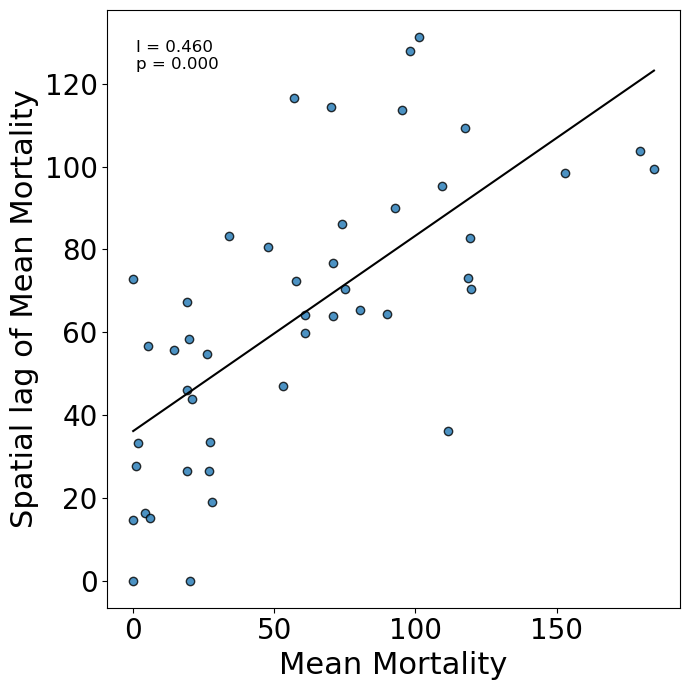

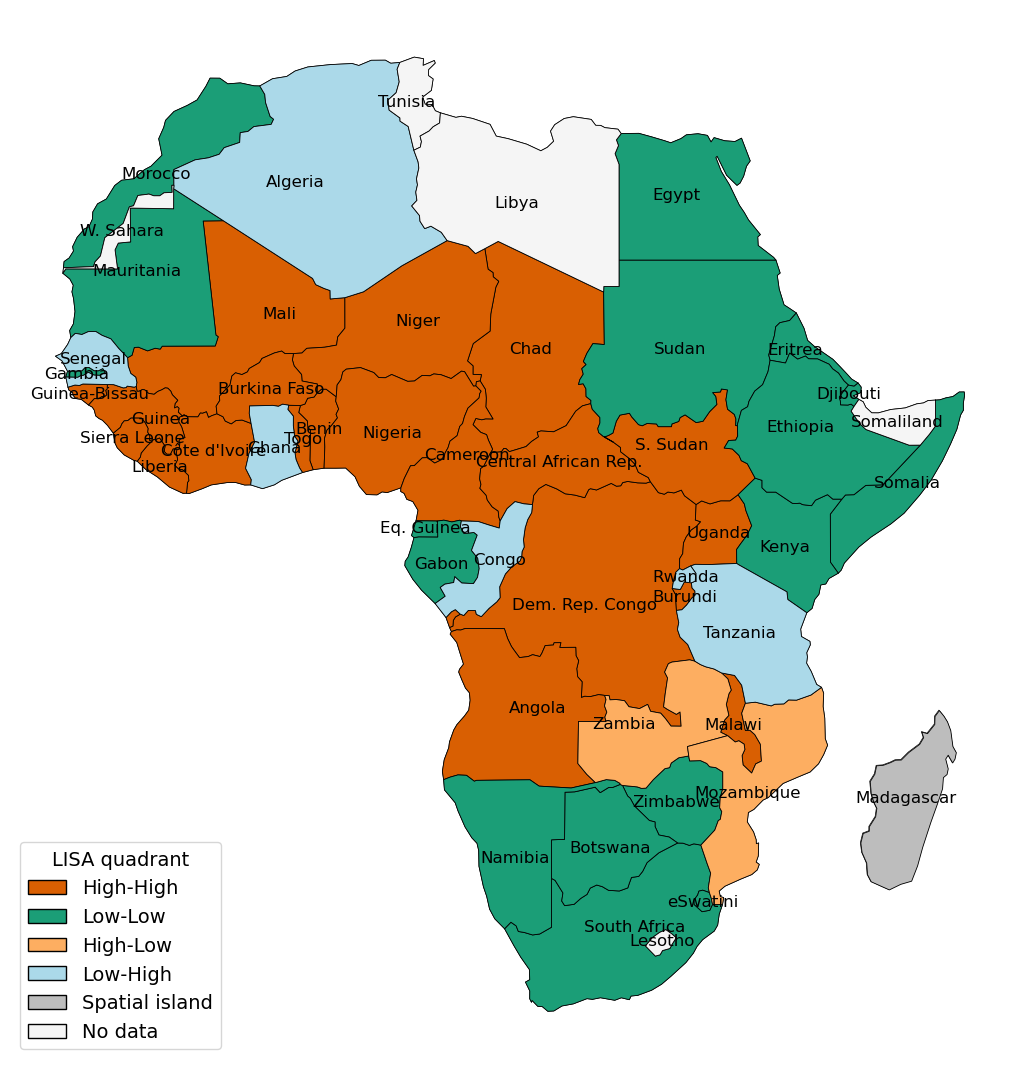

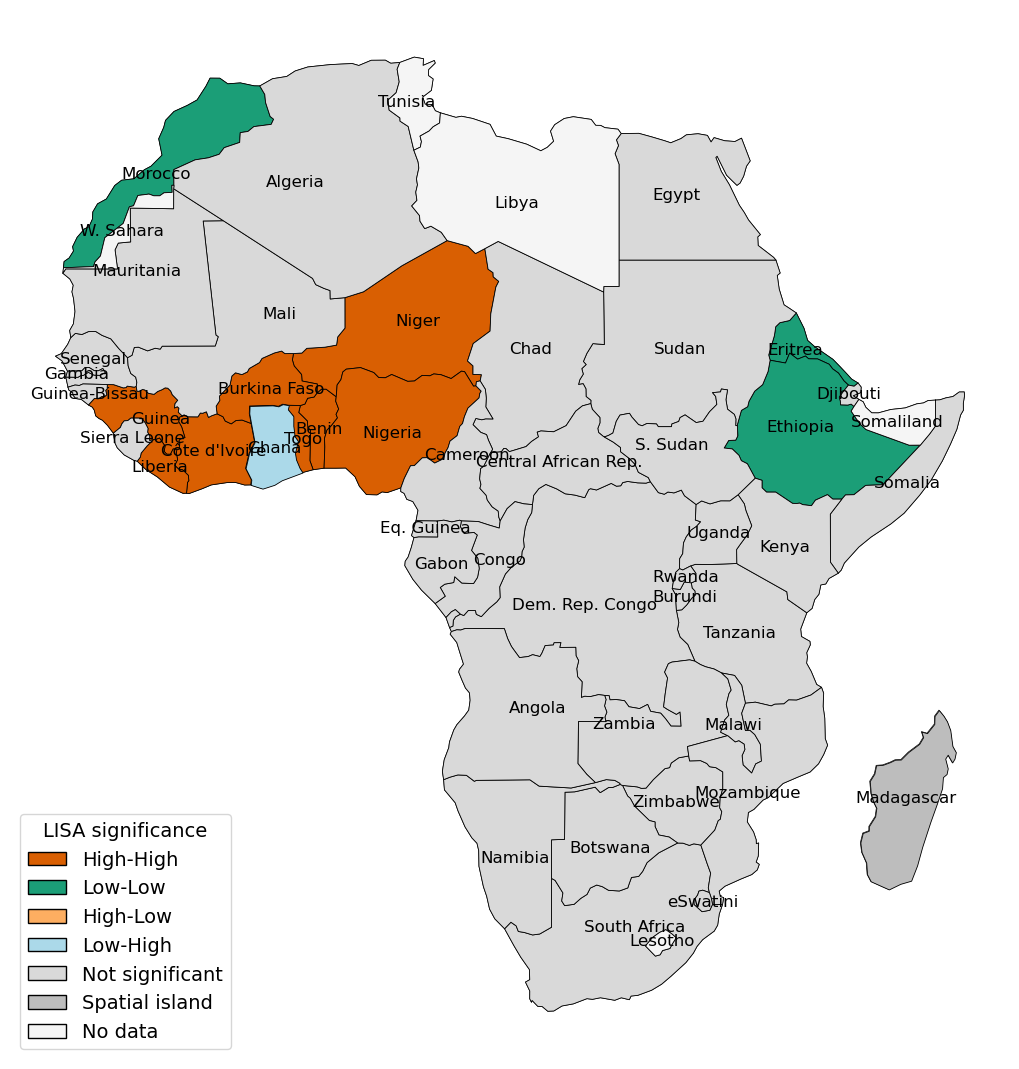

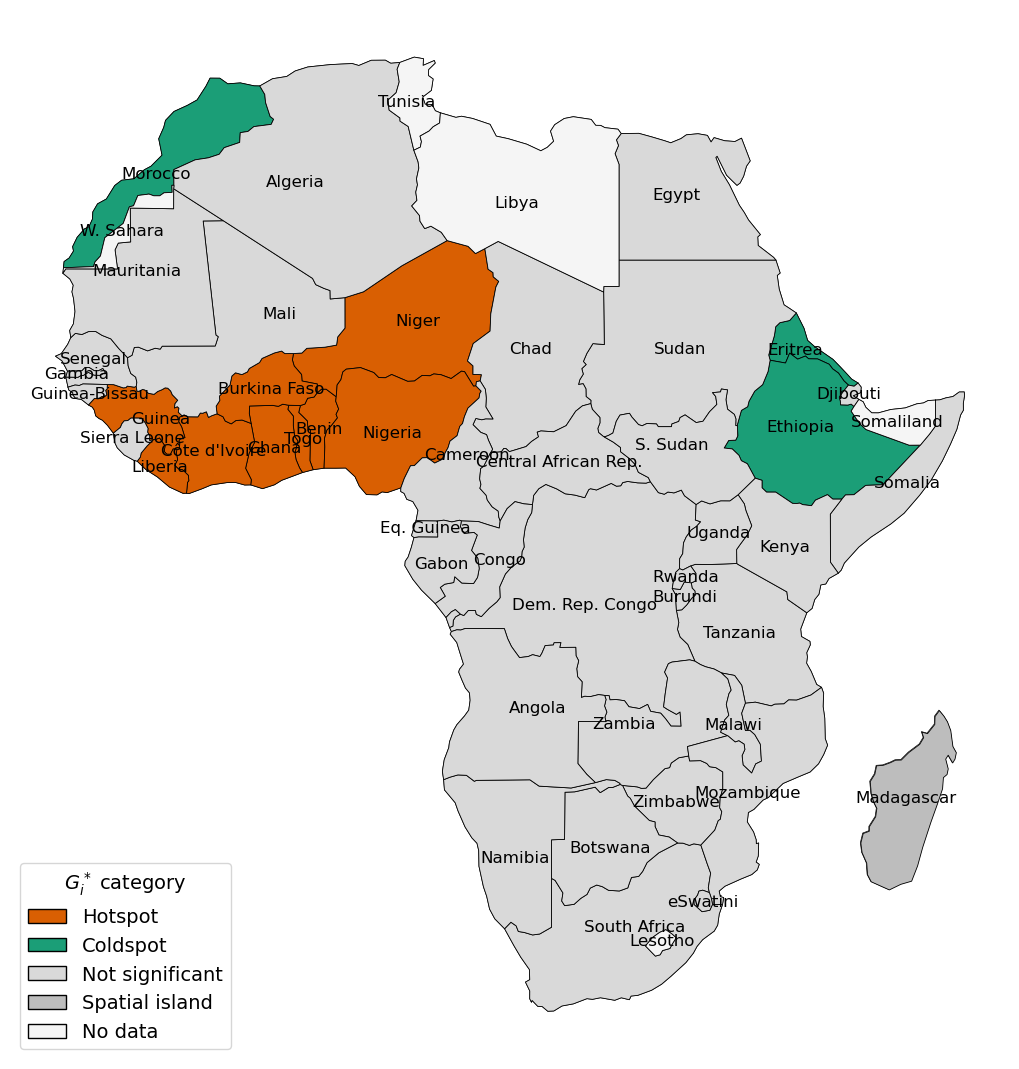

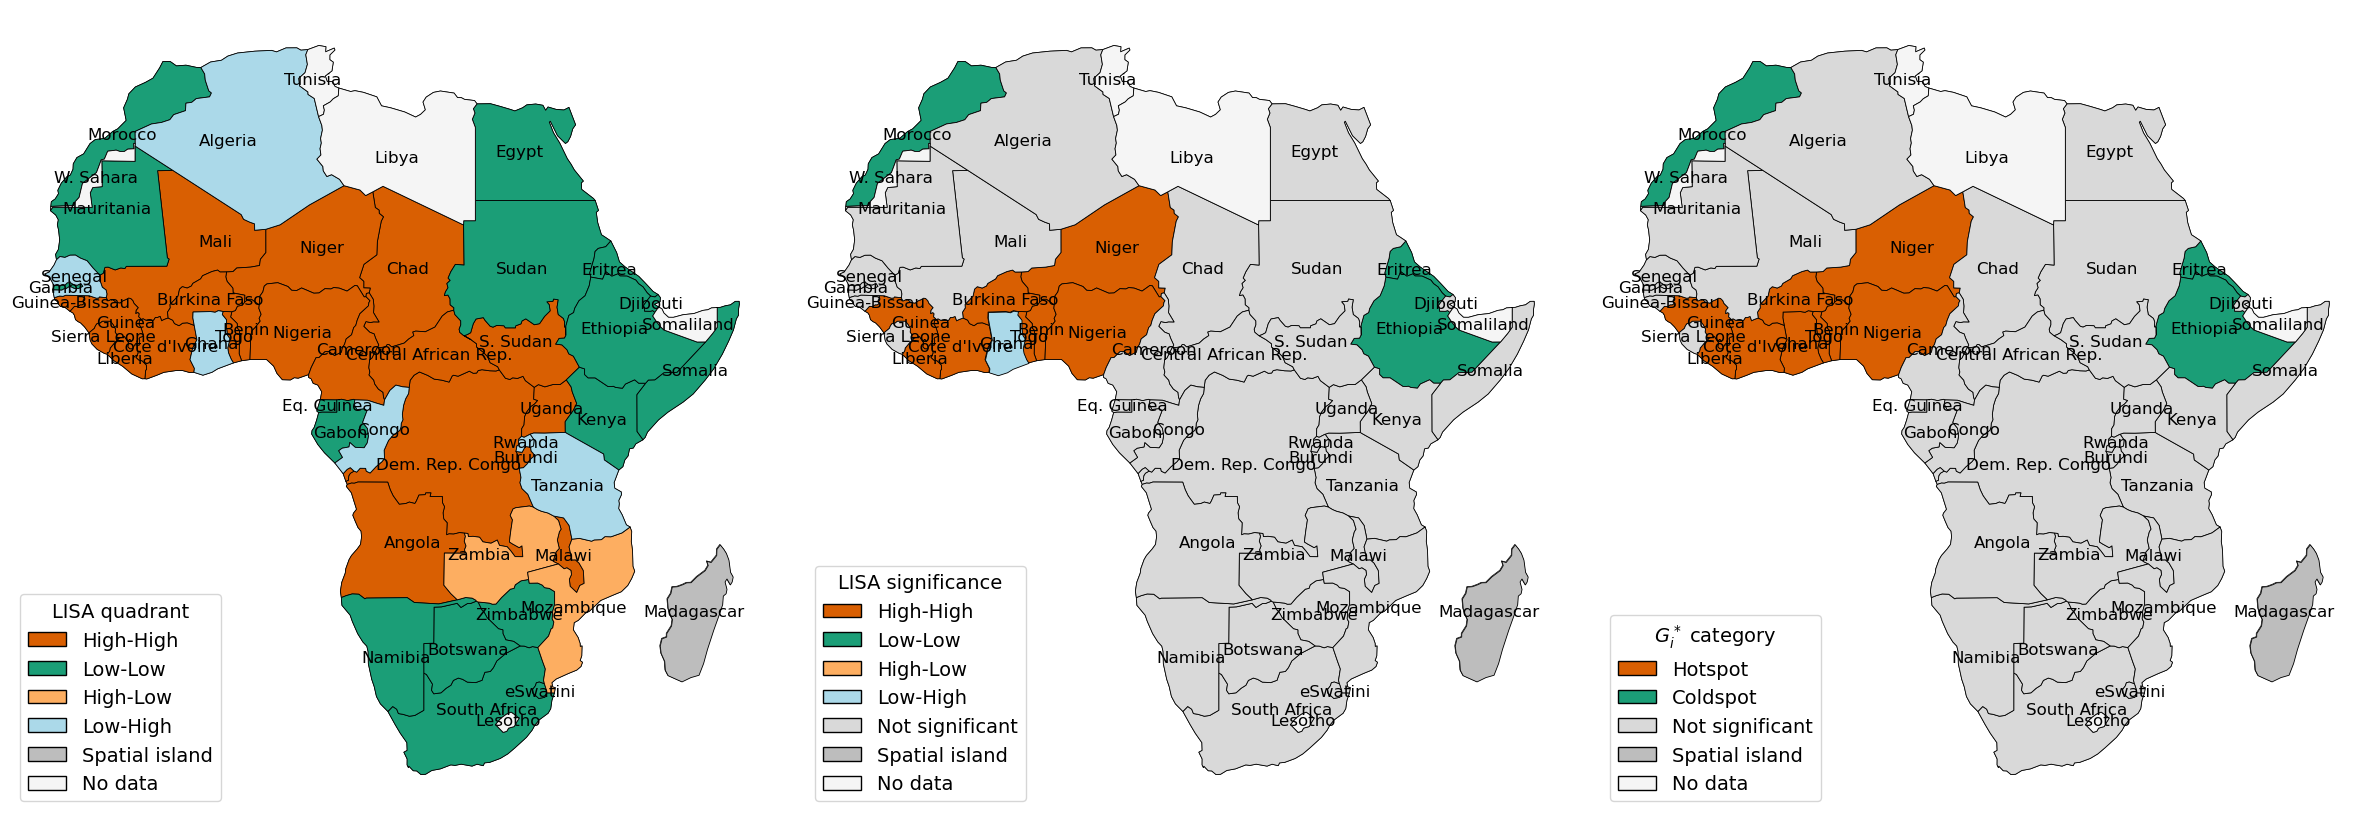


Done. Corrected spatial outputs saved in:
Geospatial/Africa_mean_malaria_est_mortality


In [5]:
# ============================================================
# CORRECTED STANDALONE SPATIAL ANALYSIS PIPELINE
# NO CLUSTERING
##  %pip install package
# Corrections included:
#   1. Explicit handling of spatial islands such as Madagascar
#   2. Correct Getis--Ord Gi* calculation using star=True
#   3. island_weight=np.nan for local inference
#   4. Explicit replacement of island statistics and p-values with NaN
#   5. Correct hotspot/coldspot classification when statistics are missing
#   6. Correct LISA classification for spatial islands
#   7. Spatial-island category added to legends and saved tables
#   8. Duplicate reporting block removed
#
# Supports:
#   - mean over study period
#   - sum over study period
#   - most recent year
#
# Supports:
#   - Africa
#   - whole world
# ============================================================

# ============================================================
# 0) IMPORTS
# ============================================================
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local


# ============================================================
# 1) GLOBAL DISPLAY + STYLE SETTINGS
# ============================================================
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 1000)

warnings.filterwarnings(
    "ignore",
    message="The weights matrix is not fully connected"
)


# ============================================================
# 2) USER SETTINGS
# ============================================================
DATA_PATH = "malaria-burden-all-WHO.csv"
ENCODING = "latin1"

WORLD_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

GEOGRAPHY = "Africa"                 # "Africa" or "World"
VALUE_COL_INPUT = "malaria_est_mortality"
SUMMARY_MODE = "mean"                # "mean", "sum", "latest_year"

# Add the input variable and summary mode to every output filename.
OUTPUT_TAG = f"{VALUE_COL_INPUT}_{SUMMARY_MODE}"

# Clean outcome label for figure axes and annotations.
if "incidence" in VALUE_COL_INPUT.lower():
    OUTCOME_LABEL = "Incidence"
elif "mortality" in VALUE_COL_INPUT.lower():
    OUTCOME_LABEL = "Mortality"
else:
    OUTCOME_LABEL = VALUE_COL_INPUT.replace("_", " ").title()

ALPHA = 0.05
SEED = 42
N_PERM = 9999

# Plot switches
SHOW_LEGEND = True
SHOW_COUNTRY_LABELS = True

# Font settings
LABEL_FS = 22
TICK_FS = 20
LEGEND_FS = 14
MAP_LABEL_FS = 12

OUTDIR_BASE = (
    f"Geospatial/"
    f"{GEOGRAPHY}_{SUMMARY_MODE}_{VALUE_COL_INPUT}"
)
OUTDIR_TABLES = os.path.join(OUTDIR_BASE, "tables")
OUTDIR_FIGS = os.path.join(OUTDIR_BASE, "figures")

os.makedirs(OUTDIR_BASE, exist_ok=True)
os.makedirs(OUTDIR_TABLES, exist_ok=True)
os.makedirs(OUTDIR_FIGS, exist_ok=True)


# ============================================================
# 3) COUNTRY NAME HARMONISATION
# ============================================================
NAME_MAP = {
    "Cabo Verde": "Cape Verde",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Republic of the Congo": "Congo",
    "Eswatini": "eSwatini",
    "The Gambia": "Gambia",
    "Sao Tome and Principe": "São Tomé and Principe",
    "United Republic of Tanzania": "Tanzania",
    "Central African Republic": "Central African Rep.",
    "South Sudan": "S. Sudan",
    "Equatorial Guinea": "Eq. Guinea",
    "Syrian Arab Republic": "Syria",
    "Lao People's Democratic Republic": "Laos",
    "Viet Nam": "Vietnam",
    "Brunei Darussalam": "Brunei",
    "Iran (Islamic Republic of)": "Iran",
    "Russian Federation": "Russia",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Moldova, Republic of": "Moldova",
    "Türkiye": "Turkey",
    "Micronesia (Federated States of)": "Micronesia",
}


# ============================================================
# 4) DATA AND MAP HELPERS
# ============================================================
def load_data(data_path, encoding="latin1"):
    """Load the malaria dataset."""
    return pd.read_csv(data_path, encoding=encoding)


def load_world_map(world_url):
    """Load the Natural Earth country map."""
    world = gpd.read_file(world_url)

    world = world[world["NAME"] != "Antarctica"].copy()
    world = world[
        world.geometry.notna()
        & (~world.geometry.is_empty)
    ].copy()

    return world


def load_analysis_map(world_url, geography="Africa"):
    """Return the full world map and the requested analysis region."""
    world = load_world_map(world_url)

    if geography == "World":
        return world.copy(), world.copy()

    if geography == "Africa":
        region = world[world["CONTINENT"] == "Africa"].copy()
        region = region[
            region.geometry.notna()
            & (~region.geometry.is_empty)
        ].copy()

        return world, region

    raise ValueError("GEOGRAPHY must be 'Africa' or 'World'.")


def harmonise_country_names(
    df,
    country_col="Country",
    name_map=None
):
    """Harmonise country names between the data and map."""
    out = df.copy()
    out[country_col] = out[country_col].astype(str).str.strip()

    if name_map is not None:
        out[country_col] = out[country_col].replace(name_map)

    return out


def filter_df_to_map(
    df,
    map_gdf,
    country_col="Country",
    map_name_col="NAME"
):
    """Retain only countries represented in the selected map."""
    valid_names = set(
        map_gdf[map_name_col]
        .astype(str)
        .str.strip()
    )

    return df[
        df[country_col]
        .astype(str)
        .str.strip()
        .isin(valid_names)
    ].copy()


def compute_country_summary(
    df,
    country_col="Country",
    year_col="Year",
    value_col="malaria_est_incidence",
    summary_mode="mean"
):
    """Calculate a country-level mean, sum, or latest-year value."""
    temp = df[[country_col, year_col, value_col]].copy()

    temp[country_col] = (
        temp[country_col]
        .astype(str)
        .str.strip()
    )
    temp[year_col] = pd.to_numeric(
        temp[year_col],
        errors="coerce"
    )
    temp[value_col] = pd.to_numeric(
        temp[value_col],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=[country_col, year_col, value_col]
    ).copy()

    if summary_mode == "latest_year":
        latest_year = int(temp[year_col].max())

        temp = temp[
            temp[year_col] == latest_year
        ].copy()

        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = latest_year
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "mean":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "sum":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .sum()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    raise ValueError(
        "SUMMARY_MODE must be 'mean', 'sum', or 'latest_year'."
    )


def merge_to_map(
    region_gdf,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
):
    """Merge the country summary values onto the geographic map."""
    return region_gdf.merge(
        country_summary,
        left_on=map_name_col,
        right_on=country_col,
        how="left"
    )


def add_country_labels(
    ax,
    gdf,
    label_col="NAME",
    fontsize=8,
    fontweight="normal",
    color="black"
):
    """Add country names at representative points."""
    if gdf.empty:
        return

    for _, row in gdf.iterrows():
        if pd.isna(row[label_col]):
            continue

        if row.geometry is None or row.geometry.is_empty:
            continue

        point = row.geometry.representative_point()

        ax.text(
            point.x,
            point.y,
            str(row[label_col]),
            fontsize=fontsize,
            ha="center",
            va="center",
            fontweight=fontweight,
            color=color
        )


# ============================================================
# 5) SPATIAL CLASSIFICATION HELPERS
# ============================================================
def lisa_category_sig(row, alpha=0.05):
    """Classify statistically significant local Moran results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if (
        pd.isna(row["local_I"])
        or pd.isna(row["local_p"])
        or pd.isna(row["quadrant"])
    ):
        return "No data"

    if row["local_p"] >= alpha:
        return "Not significant"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "Not significant"
    )


def lisa_quadrant_only(row):
    """Return the LISA quadrant regardless of significance."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if pd.isna(row["quadrant"]):
        return "No data"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "No data"
    )


def gi_category(row, alpha=0.05):
    """Classify statistically significant Getis--Ord Gi* results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    gi_z = row["GiZ"]
    gi_p = row["GiP"]

    if pd.isna(gi_z) or pd.isna(gi_p):
        return "No data"

    if gi_p >= alpha:
        return "Not significant"

    if gi_z > 0:
        return "Hotspot"

    if gi_z < 0:
        return "Coldspot"

    return "Not significant"


# ============================================================
# 6) SPATIAL STATISTICS
# ============================================================
def compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=0.05,
    seed=42,
    n_perm=9999
):
    """
    Calculate Global Moran's I, Local Moran's I, and Getis--Ord Gi*.

    Spatial islands are retained in the output but excluded from
    local inferential interpretation because Queen contiguity
    provides them with no geographic neighbors.
    """
    region_stats = region_map.dropna(
        subset=[value_col]
    ).copy()

    region_stats = region_stats[
        region_stats.geometry.notna()
        & (~region_stats.geometry.is_empty)
    ].copy()

    region_stats = (
        region_stats
        .sort_values("NAME")
        .reset_index(drop=True)
    )

    if len(region_stats) < 3:
        raise ValueError(
            "At least three countries with valid geometry and "
            "outcome data are required."
        )

    # --------------------------------------------------------
    # Queen-contiguity spatial weights
    # --------------------------------------------------------
    w = Queen.from_dataframe(
        region_stats,
        use_index=False
    )

    w.transform = "r"

    y = region_stats[value_col].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Identify spatial islands
    # --------------------------------------------------------
    island_indices = set(w.islands)

    region_stats["Spatial_Island"] = [
        idx in island_indices
        for idx in range(len(region_stats))
    ]

    print("\nSpatial islands under Queen contiguity:")

    if island_indices:
        for idx in sorted(island_indices):
            print(
                f"  Index {idx}: "
                f"{region_stats.loc[idx, 'NAME']}"
            )
    else:
        print("  None")

    # --------------------------------------------------------
    # Global Moran's I
    # --------------------------------------------------------
    moran = Moran(
        y,
        w,
        permutations=n_perm
    )

    # --------------------------------------------------------
    # Local Moran's I
    # --------------------------------------------------------
    lisa_obj = Moran_Local(
        y,
        w,
        permutations=n_perm,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["local_I"] = lisa_obj.Is
    region_stats["local_p"] = lisa_obj.p_sim
    region_stats["quadrant"] = lisa_obj.q

    # Explicitly remove invalid island results
    island_mask = region_stats["Spatial_Island"]

    region_stats.loc[
        island_mask,
        ["local_I", "local_p", "quadrant"]
    ] = np.nan

    region_stats["LISA_Category_Sig"] = (
        region_stats.apply(
            lambda row: lisa_category_sig(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    region_stats["LISA_Category_All"] = (
        region_stats.apply(
            lisa_quadrant_only,
            axis=1
        )
    )

    # --------------------------------------------------------
    # Local Getis--Ord Gi*
    # star=True is required for Gi*
    # --------------------------------------------------------
    g_local = G_Local(
        y,
        w,
        transform="R",
        permutations=n_perm,
        star=True,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["GiZ"] = g_local.Zs
    region_stats["GiP"] = g_local.p_sim

    # Explicitly remove invalid island results
    region_stats.loc[
        island_mask,
        ["GiZ", "GiP"]
    ] = np.nan

    region_stats["Gi_Category"] = (
        region_stats.apply(
            lambda row: gi_category(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    # --------------------------------------------------------
    # Merge LISA results back to full regional map
    # --------------------------------------------------------
    region_lisa = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "local_I",
                "local_p",
                "quadrant",
                "LISA_Category_Sig",
                "LISA_Category_All"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_lisa["LISA_Category_Sig"] = (
        region_lisa["LISA_Category_Sig"]
        .fillna("No data")
    )

    region_lisa["LISA_Category_All"] = (
        region_lisa["LISA_Category_All"]
        .fillna("No data")
    )

    # --------------------------------------------------------
    # Merge Gi* results back to full regional map
    # --------------------------------------------------------
    region_gi = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "GiZ",
                "GiP",
                "Gi_Category"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_gi["Gi_Category"] = (
        region_gi["Gi_Category"]
        .fillna("No data")
    )

    return {
        "region_stats": region_stats,
        "w": w,
        "y": y,
        "moran": moran,
        "lisa_obj": lisa_obj,
        "g_local": g_local,
        "region_lisa": region_lisa,
        "region_gi": region_gi,
        "island_indices": sorted(island_indices)
    }


# ============================================================
# 7) PLOTTING FUNCTIONS
# ============================================================
def plot_moran_scatter(
    y,
    w,
    moran,
    xlabel,
    ylabel,
    out_png,
    out_pdf,
    figsize=(7, 7)
):
    """Plot the global Moran scatterplot."""
    lag_y = w.sparse.dot(y)

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        y,
        lag_y,
        edgecolor="black",
        alpha=0.8
    )

    coef = np.polyfit(y, lag_y, 1)
    x_line = np.linspace(
        y.min(),
        y.max(),
        100
    )
    y_line = (
        coef[0] * x_line
        + coef[1]
    )

    ax.plot(
        x_line,
        y_line,
        color="black",
        linewidth=1.5
    )

    ax.set_xlabel(
        xlabel,
        fontsize=LABEL_FS
    )
    ax.set_ylabel(
        ylabel,
        fontsize=LABEL_FS
    )

    ax.tick_params(
        axis="x",
        labelsize=TICK_FS
    )
    ax.tick_params(
        axis="y",
        labelsize=TICK_FS
    )

    ax.grid(False)

    ax.text(
        0.05,
        0.95,
        (
            f"I = {moran.I:.3f}\n"
            f"p = {moran.p_sim:.3f}"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12
    )

    plt.tight_layout()
    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_quadrant_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot all LISA quadrants, regardless of significance."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_All"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA quadrant",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_significance_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant LISA clusters and outliers."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_Sig"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA significance",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_gi_map(
    base_gdf,
    region_gi,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant Getis--Ord Gi* results."""
    color_map = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_gi[
            region_gi["Gi_Category"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_gi[
            region_gi.geometry.notna()
            & (~region_gi.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title=r"$G_i^*$ category",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_combined_lisa_sig_gi(
    base_gdf,
    region_lisa,
    region_gi,
    out_png,
    out_pdf,
    figsize=(24, 10),
    show_legend=True,
    show_labels=True
):
    """Plot LISA quadrant, significant LISA, and Gi* maps together."""
    lisa_quad_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    lisa_sig_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    gi_colors = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize
    )

    panels = [
        (
            axes[0],
            region_lisa,
            "LISA_Category_All",
            lisa_quad_colors,
            "LISA quadrant"
        ),
        (
            axes[1],
            region_lisa,
            "LISA_Category_Sig",
            lisa_sig_colors,
            "LISA significance"
        ),
        (
            axes[2],
            region_gi,
            "Gi_Category",
            gi_colors,
            r"$G_i^*$ category"
        )
    ]

    for ax, gdf, category_col, color_map, legend_title in panels:
        base_gdf.plot(
            ax=ax,
            color="white",
            edgecolor="black",
            linewidth=0.5,
            aspect=1
        )

        for category, color in color_map.items():
            subset = gdf[
                gdf[category_col] == category
            ].copy()

            subset = subset[
                subset.geometry.notna()
                & (~subset.geometry.is_empty)
            ].copy()

            if not subset.empty:
                subset.plot(
                    ax=ax,
                    color=color,
                    edgecolor="black",
                    linewidth=0.6,
                    aspect=1
                )

        if show_labels:
            label_gdf = gdf[
                gdf.geometry.notna()
                & (~gdf.geometry.is_empty)
            ].copy()

            add_country_labels(
                ax,
                label_gdf,
                label_col="NAME",
                fontsize=MAP_LABEL_FS
            )

        if show_legend:
            legend_elements = [
                Patch(
                    facecolor=color,
                    edgecolor="black",
                    label=category
                )
                for category, color in color_map.items()
            ]

            ax.legend(
                handles=legend_elements,
                loc="lower left",
                fontsize=LEGEND_FS,
                frameon=True,
                title=legend_title,
                title_fontsize=LEGEND_FS
            )

        ax.set_axis_off()

    plt.tight_layout()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


# ============================================================
# 8) LOAD DATA
# ============================================================
df = load_data(
    DATA_PATH,
    ENCODING
)

df = harmonise_country_names(
    df,
    country_col="Country",
    name_map=NAME_MAP
)

required_cols = [
    "Country",
    "Year",
    VALUE_COL_INPUT
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Input data is missing required columns: {missing_cols}"
    )

world_full, analysis_map = load_analysis_map(
    WORLD_URL,
    GEOGRAPHY
)

df_use = filter_df_to_map(
    df,
    analysis_map,
    country_col="Country",
    map_name_col="NAME"
)

print(f"Rows in input data: {len(df):,}")
print(
    f"Rows retained for {GEOGRAPHY}: "
    f"{len(df_use):,}"
)
print(
    f"Countries retained for {GEOGRAPHY}: "
    f"{df_use['Country'].nunique()}"
)


# ============================================================
# 9) COUNTRY SUMMARY
# ============================================================
country_summary = compute_country_summary(
    df_use,
    country_col="Country",
    year_col="Year",
    value_col=VALUE_COL_INPUT,
    summary_mode=SUMMARY_MODE
)

country_summary.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"country_summary_{OUTPUT_TAG}.csv"
    ),
    index=False
)

print("\nTop countries by summary value:")
print(country_summary.head(10))


# ============================================================
# 10) MERGE TO MAP
# ============================================================
region_map = merge_to_map(
    analysis_map,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
)

region_map.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"map_attributes_{OUTPUT_TAG}.csv"
    ),
    index=False
)

print(
    "\nCountries matched on map:",
    region_map["summary_value"]
    .notna()
    .sum()
)


# ============================================================
# 11) SPATIAL ANALYSIS
# ============================================================
spatial_results = compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=ALPHA,
    seed=SEED,
    n_perm=N_PERM
)

region_stats = spatial_results["region_stats"]
w = spatial_results["w"]
y = spatial_results["y"]
moran = spatial_results["moran"]
region_lisa = spatial_results["region_lisa"]
region_gi = spatial_results["region_gi"]


# ============================================================
# 12) SAVE TABLES
# ============================================================
pd.DataFrame(
    {
        "Metric": [
            "Global Moran's I",
            "Permutation p-value"
        ],
        "Value": [
            moran.I,
            moran.p_sim
        ]
    }
).to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"global_morans_I_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_stats.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"region_stats_with_local_stats_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_lisa.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"lisa_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_gi.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"gi_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

quadrant_map = {
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
}

lisa_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "Quadrant": region_stats["quadrant"],
        "Quadrant_Label": (
            region_stats["quadrant"]
            .map(quadrant_map)
        ),
        "Local_I": region_stats["local_I"],
        "p_value": region_stats["local_p"],
        "Final_Category_Sig": (
            region_stats["LISA_Category_Sig"]
        ),
        "Final_Category_All": (
            region_stats["LISA_Category_All"]
        )
    }
)

lisa_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"lisa_diagnostic_table_{OUTPUT_TAG}.csv"
    ),
    index=False
)

gi_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "GiZ": region_stats["GiZ"],
        "GiP": region_stats["GiP"],
        "Gi_Category": region_stats["Gi_Category"]
    }
)

gi_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"gi_diagnostic_table_{OUTPUT_TAG}.csv"
    ),
    index=False
)


# ============================================================
# 13) PRINT AND SAVE SIGNIFICANT SPATIAL GROUPS
# ============================================================
print("\n" + "=" * 70)
print("SIGNIFICANT LISA CLUSTERS")
print("=" * 70)

hh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

ll_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

hl_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lisa_islands = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHigh-High clusters ({len(hh_countries)} countries):"
)
print(", ".join(hh_countries) or "None")

print(
    f"\nLow-Low clusters ({len(ll_countries)} countries):"
)
print(", ".join(ll_countries) or "None")

print(
    f"\nLow-High outliers ({len(lh_countries)} countries):"
)
print(", ".join(lh_countries) or "None")

print(
    f"\nHigh-Low outliers ({len(hl_countries)} countries):"
)
print(", ".join(hl_countries) or "None")

print(
    f"\nSpatial islands ({len(lisa_islands)} countries):"
)
print(", ".join(lisa_islands) or "None")

print("\n" + "=" * 70)
print("GETIS--ORD Gi* HOTSPOTS / COLDSPOTS")
print("=" * 70)

hotspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Hotspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

coldspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Coldspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

gi_islands = (
    region_gi[
        region_gi["Gi_Category"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHotspots ({len(hotspot_countries)} countries):"
)
print(", ".join(hotspot_countries) or "None")

print(
    f"\nColdspots ({len(coldspot_countries)} countries):"
)
print(", ".join(coldspot_countries) or "None")

print(
    f"\nSpatial islands ({len(gi_islands)} countries):"
)
print(", ".join(gi_islands) or "None")

with open(
    os.path.join(
        OUTDIR_TABLES,
        f"significant_spatial_groups_{OUTPUT_TAG}.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write("SIGNIFICANT LISA CLUSTERS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"High-High ({len(hh_countries)} countries)\n"
    )
    file.write(
        (", ".join(hh_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-Low ({len(ll_countries)} countries)\n"
    )
    file.write(
        (", ".join(ll_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-High ({len(lh_countries)} countries)\n"
    )
    file.write(
        (", ".join(lh_countries) or "None") + "\n\n"
    )

    file.write(
        f"High-Low ({len(hl_countries)} countries)\n"
    )
    file.write(
        (", ".join(hl_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(lisa_islands)} countries)\n"
    )
    file.write(
        (", ".join(lisa_islands) or "None") + "\n\n"
    )

    file.write("GETIS--ORD Gi* RESULTS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"Hotspots ({len(hotspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(hotspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Coldspots ({len(coldspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(coldspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(gi_islands)} countries)\n"
    )
    file.write(
        (", ".join(gi_islands) or "None") + "\n"
    )


# ============================================================
# 14) BUILD AXIS LABELS
# ============================================================
if SUMMARY_MODE == "latest_year":
    latest_year = int(
        country_summary["analysis_year"]
        .dropna()
        .iloc[0]
    )

    legend_label = f"{OUTCOME_LABEL} in {latest_year}"
else:
    latest_year = None

    summary_label_map = {
        "mean": "Mean",
        "sum": "Total"
    }

    summary_label = summary_label_map.get(
        SUMMARY_MODE,
        SUMMARY_MODE.replace("_", " ").title()
    )

    legend_label = f"{summary_label} {OUTCOME_LABEL}"

figsize_main = (
    (10, 12)
    if GEOGRAPHY == "Africa"
    else (20, 10)
)


# ============================================================
# 15) MORAN SCATTERPLOT
# ============================================================
plot_moran_scatter(
    y=y,
    w=w,
    moran=moran,
    xlabel=legend_label,
    ylabel=f"Spatial lag of {legend_label}",
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"moran_scatter_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"moran_scatter_{OUTPUT_TAG}.pdf"
    ),
    figsize=(7, 7)
)


# ============================================================
# 16) LISA QUADRANT MAP
# ============================================================
plot_lisa_quadrant_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"lisa_quadrant_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"lisa_quadrant_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 17) LISA SIGNIFICANCE MAP
# ============================================================
plot_lisa_significance_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"lisa_significance_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"lisa_significance_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 18) GETIS--ORD Gi* MAP
# ============================================================
plot_gi_map(
    base_gdf=analysis_map,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"gi_star_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"gi_star_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 19) COMBINED LISA + LISA SIGNIFICANCE + Gi* FIGURE
# ============================================================
plot_combined_lisa_sig_gi(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"combined_lisa_sig_gi_star_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"combined_lisa_sig_gi_star_{OUTPUT_TAG}.pdf"
    ),
    figsize=(
        (24, 10)
        if GEOGRAPHY == "Africa"
        else (30, 10)
    ),
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 20) WORKFLOW SUMMARY
# ============================================================
with open(
    os.path.join(
        OUTDIR_BASE,
        f"workflow_summary_{OUTPUT_TAG}.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write(
        "Corrected spatial-only analysis completed.\n\n"
    )

    file.write(f"Input file: {DATA_PATH}\n")
    file.write(f"Geography: {GEOGRAPHY}\n")
    file.write(f"Variable: {VALUE_COL_INPUT}\n")
    file.write(f"Summary mode: {SUMMARY_MODE}\n")

    if latest_year is not None:
        file.write(f"Analysis year: {latest_year}\n")

    file.write(f"Alpha: {ALPHA}\n")
    file.write(f"Seed: {SEED}\n")
    file.write(f"Permutations: {N_PERM}\n")
    file.write("Spatial weights: Queen contiguity\n")
    file.write("Local Getis--Ord statistic: Gi* (star=True)\n")
    file.write(
        "Spatial-island treatment: retained but local "
        "statistics set to missing\n"
    )
    file.write(f"Show legend: {SHOW_LEGEND}\n")
    file.write(
        f"Show country labels: {SHOW_COUNTRY_LABELS}\n\n"
    )

    file.write("Outputs:\n")
    file.write(f"- country_summary_{OUTPUT_TAG}.csv\n")
    file.write(f"- map_attributes_{OUTPUT_TAG}.csv\n")
    file.write(f"- global_morans_I_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- region_stats_with_local_stats_{OUTPUT_TAG}.csv\n")
    file.write(f"- lisa_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- gi_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- lisa_diagnostic_table_{OUTPUT_TAG}.csv\n")
    file.write(f"- gi_diagnostic_table_{OUTPUT_TAG}.csv\n")
    file.write(f"- significant_spatial_groups_{OUTPUT_TAG}.txt\n")
    file.write(f"- moran_scatter_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- lisa_quadrant_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- lisa_significance_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- gi_star_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- combined_lisa_sig_gi_star_{OUTPUT_TAG}.png/.pdf\n")

print(
    f"\nDone. Corrected spatial outputs saved in:\n"
    f"{OUTDIR_BASE}"
)


Rows in input data: 2,819
Rows retained for Africa: 1,150
Countries retained for Africa: 46

Top countries by summary value:
                Country  summary_value  analysis_year summary_mode
0                 Niger         131.20           2024  latest_year
1  Central African Rep.          94.96           2024  latest_year
2               Nigeria          79.48           2024  latest_year
3          Sierra Leone          76.90           2024  latest_year
4                Guinea          69.44           2024  latest_year
5                  Chad          69.04           2024  latest_year
6                 Benin          68.77           2024  latest_year
7          Burkina Faso          68.73           2024  latest_year
8            Madagascar          65.39           2024  latest_year
9               Liberia          63.48           2024  latest_year

Countries matched on map: 46
('WARNING: ', 24, ' is an island (no neighbors)')

Spatial islands under Queen contiguity:
  Index 24: Madag

C:\Users\lubna\anaconda3\Lib\site-packages\esda\moran.py:1398: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:362: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:476: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)


('WARNING: ', 24, ' is an island (no neighbors)')

SIGNIFICANT LISA CLUSTERS

High-High clusters (6 countries):
Benin, Burkina Faso, Cameroon, Chad, Niger, Nigeria

Low-Low clusters (2 countries):
Botswana, South Africa

Low-High outliers (0 countries):
None

High-Low outliers (1 countries):
Mozambique

Spatial islands (1 countries):
Madagascar

GETIS--ORD Gi* HOTSPOTS / COLDSPOTS

Hotspots (6 countries):
Benin, Burkina Faso, Cameroon, Chad, Niger, Nigeria

Coldspots (4 countries):
Botswana, Morocco, Mozambique, South Africa

Spatial islands (1 countries):
Madagascar


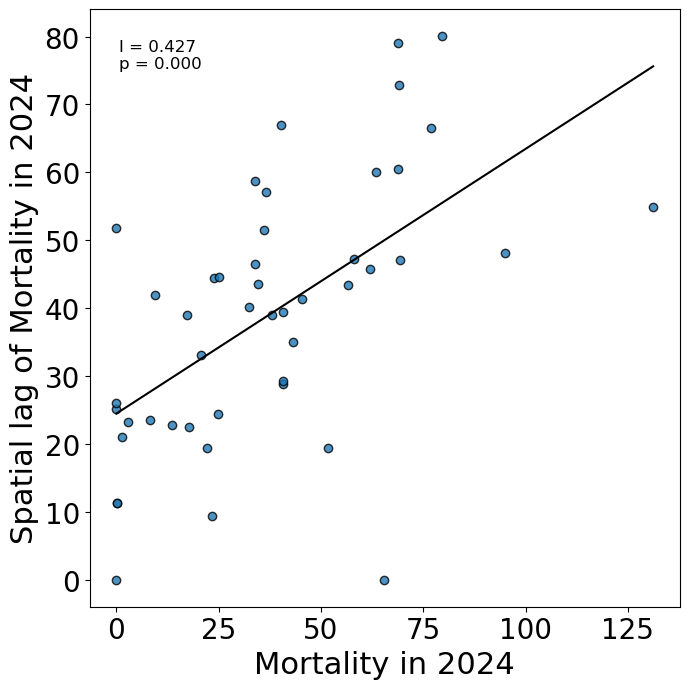

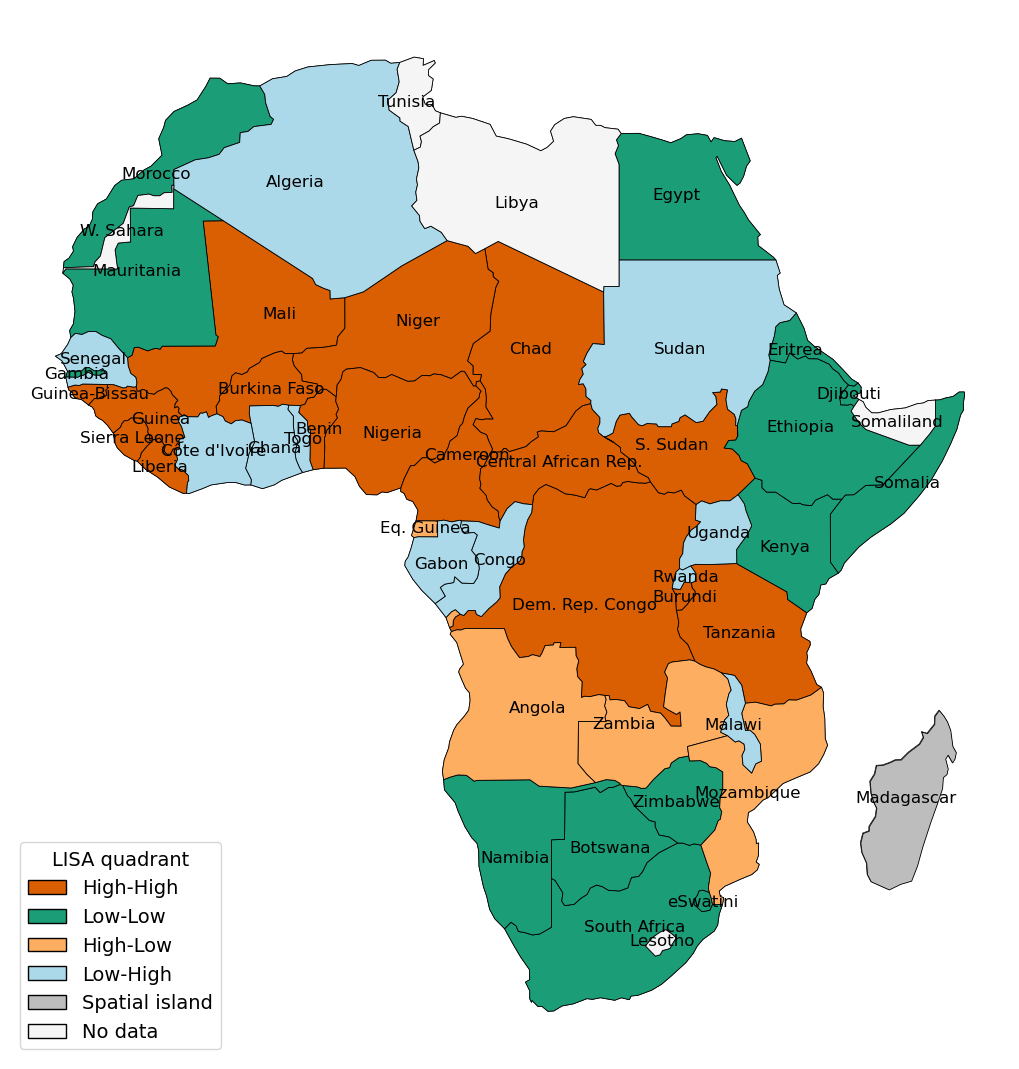

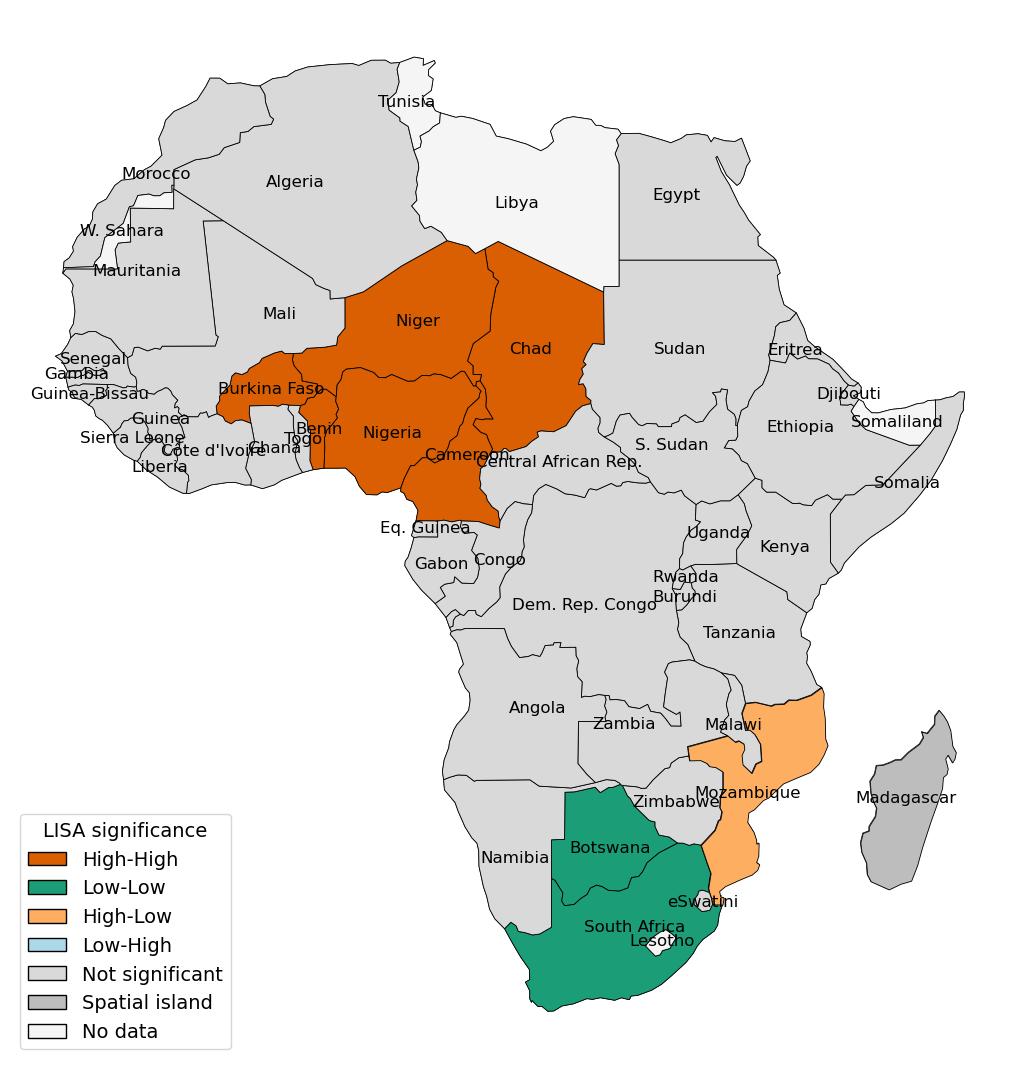

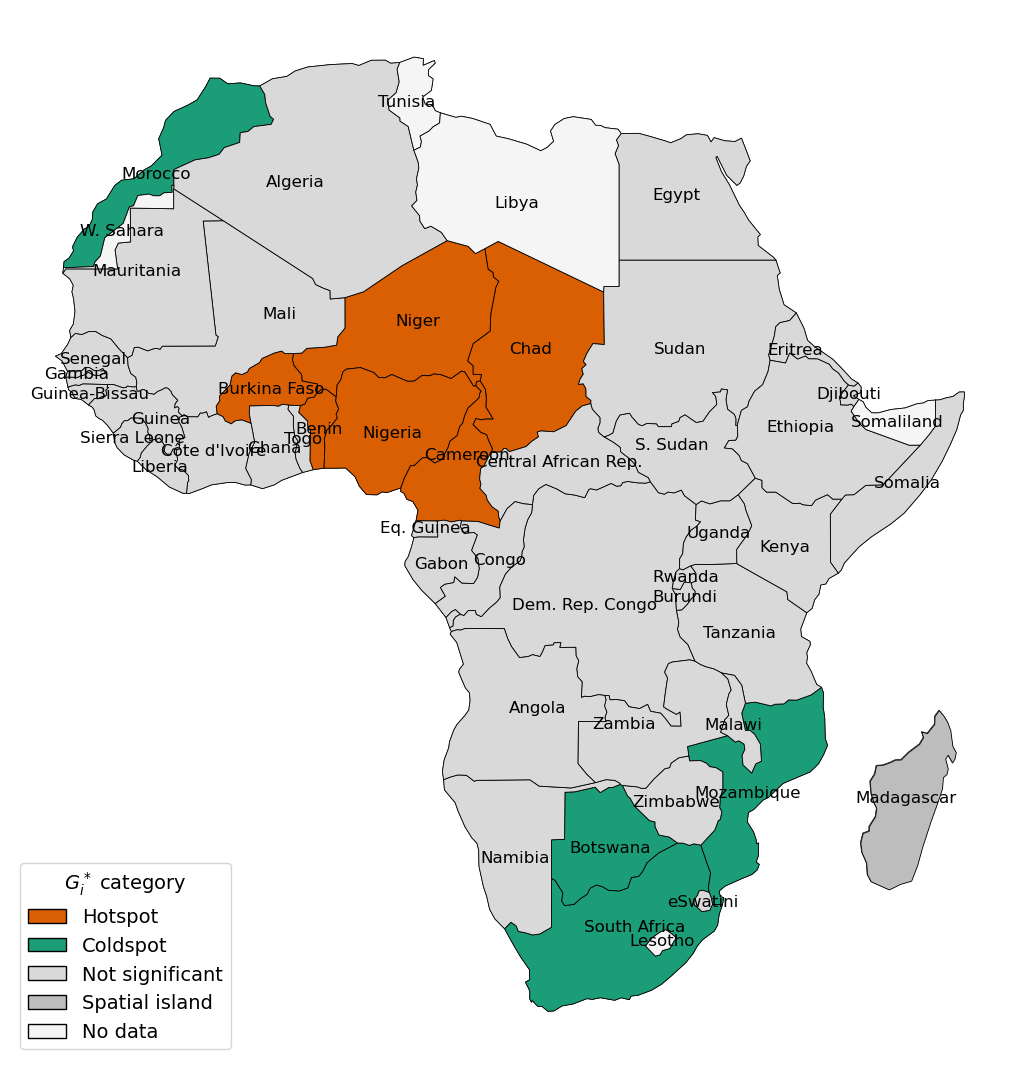

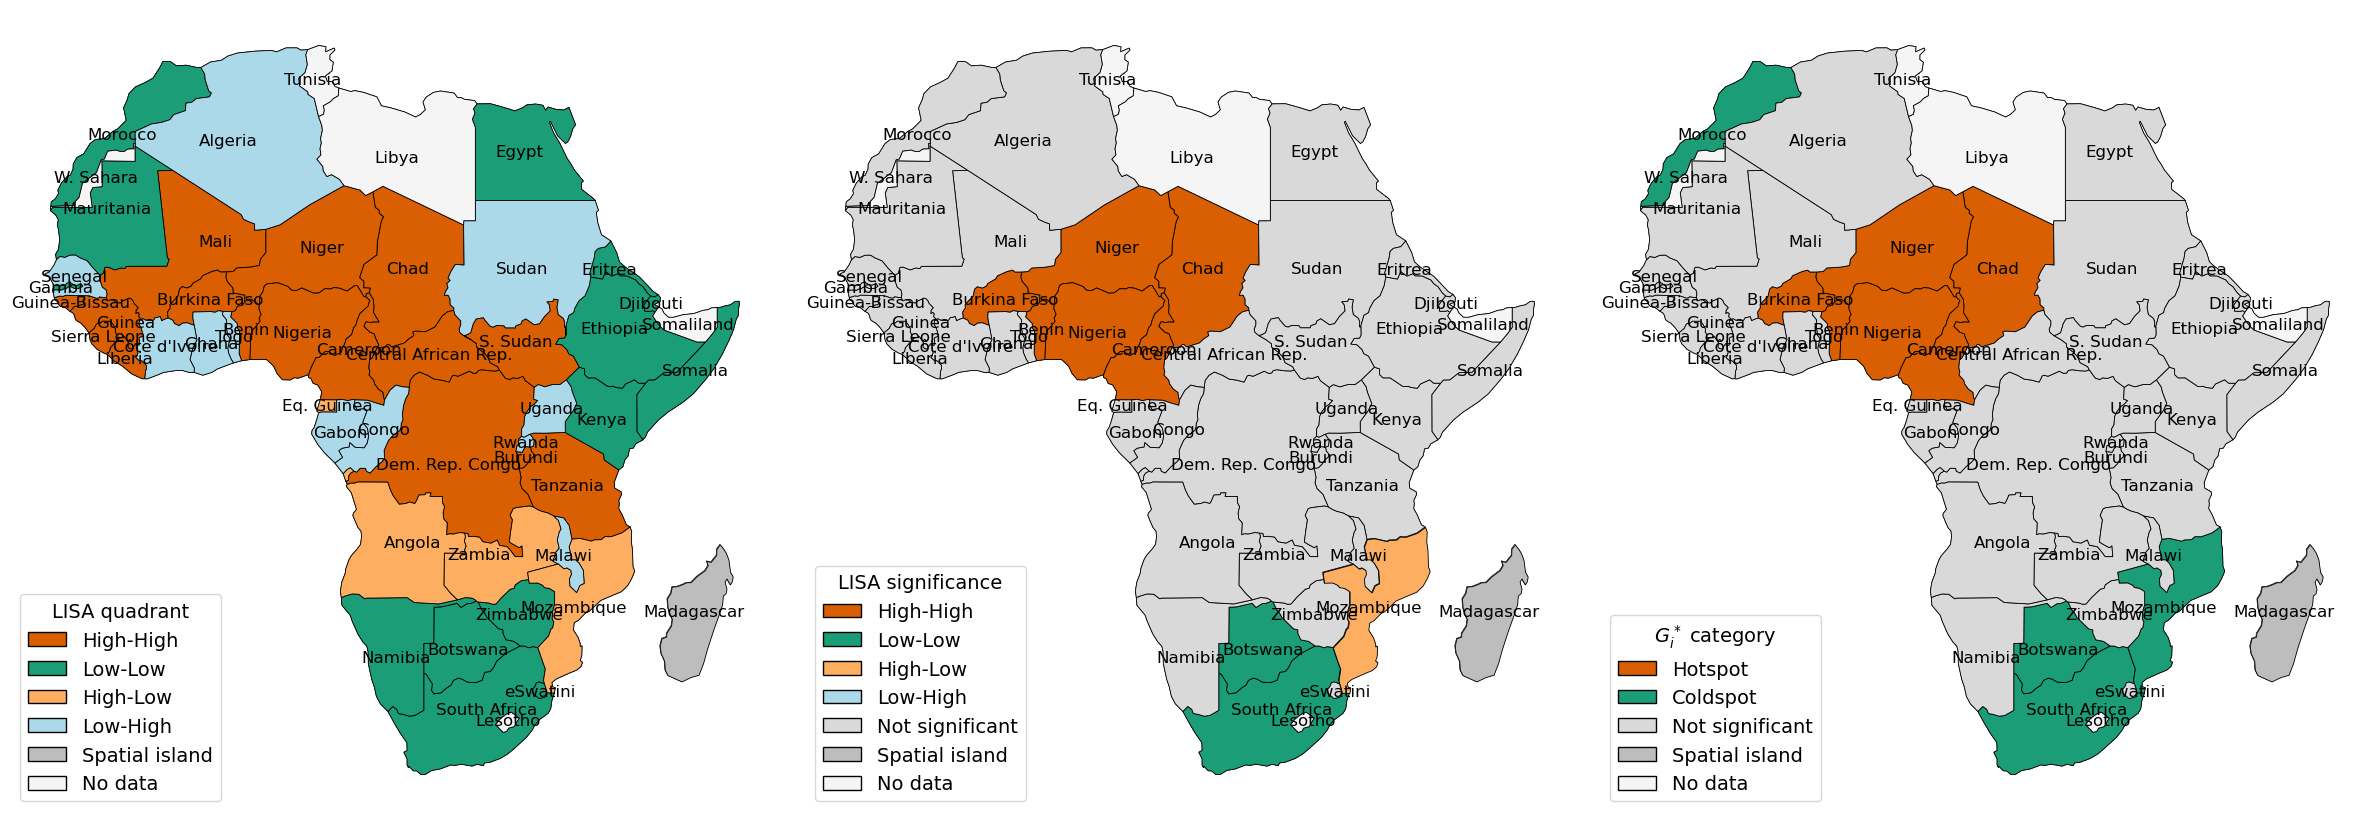


Done. Corrected spatial outputs saved in:
Geospatial/Africa_latest_year_malaria_est_mortality


In [6]:
# ============================================================
# CORRECTED STANDALONE SPATIAL ANALYSIS PIPELINE
# NO CLUSTERING
##  %pip install package
# Corrections included:
#   1. Explicit handling of spatial islands such as Madagascar
#   2. Correct Getis--Ord Gi* calculation using star=True
#   3. island_weight=np.nan for local inference
#   4. Explicit replacement of island statistics and p-values with NaN
#   5. Correct hotspot/coldspot classification when statistics are missing
#   6. Correct LISA classification for spatial islands
#   7. Spatial-island category added to legends and saved tables
#   8. Duplicate reporting block removed
#
# Supports:
#   - mean over study period
#   - sum over study period
#   - most recent year
#
# Supports:
#   - Africa
#   - whole world
# ============================================================

# ============================================================
# 0) IMPORTS
# ============================================================
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local


# ============================================================
# 1) GLOBAL DISPLAY + STYLE SETTINGS
# ============================================================
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 1000)

warnings.filterwarnings(
    "ignore",
    message="The weights matrix is not fully connected"
)


# ============================================================
# 2) USER SETTINGS
# ============================================================
DATA_PATH = "malaria-burden-all-WHO.csv"
ENCODING = "latin1"

WORLD_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

GEOGRAPHY = "Africa"                 # "Africa" or "World"
VALUE_COL_INPUT = "malaria_est_mortality"
SUMMARY_MODE = "latest_year"                # "mean", "sum", "latest_year"

# Add the input variable and summary mode to every output filename.
OUTPUT_TAG = f"{VALUE_COL_INPUT}_{SUMMARY_MODE}"

# Clean outcome label for figure axes and annotations.
if "incidence" in VALUE_COL_INPUT.lower():
    OUTCOME_LABEL = "Incidence"
elif "mortality" in VALUE_COL_INPUT.lower():
    OUTCOME_LABEL = "Mortality"
else:
    OUTCOME_LABEL = VALUE_COL_INPUT.replace("_", " ").title()

ALPHA = 0.05
SEED = 42
N_PERM = 9999

# Plot switches
SHOW_LEGEND = True
SHOW_COUNTRY_LABELS = True

# Font settings
LABEL_FS = 22
TICK_FS = 20
LEGEND_FS = 14
MAP_LABEL_FS = 12

OUTDIR_BASE = (
    f"Geospatial/"
    f"{GEOGRAPHY}_{SUMMARY_MODE}_{VALUE_COL_INPUT}"
)
OUTDIR_TABLES = os.path.join(OUTDIR_BASE, "tables")
OUTDIR_FIGS = os.path.join(OUTDIR_BASE, "figures")

os.makedirs(OUTDIR_BASE, exist_ok=True)
os.makedirs(OUTDIR_TABLES, exist_ok=True)
os.makedirs(OUTDIR_FIGS, exist_ok=True)


# ============================================================
# 3) COUNTRY NAME HARMONISATION
# ============================================================
NAME_MAP = {
    "Cabo Verde": "Cape Verde",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Republic of the Congo": "Congo",
    "Eswatini": "eSwatini",
    "The Gambia": "Gambia",
    "Sao Tome and Principe": "São Tomé and Principe",
    "United Republic of Tanzania": "Tanzania",
    "Central African Republic": "Central African Rep.",
    "South Sudan": "S. Sudan",
    "Equatorial Guinea": "Eq. Guinea",
    "Syrian Arab Republic": "Syria",
    "Lao People's Democratic Republic": "Laos",
    "Viet Nam": "Vietnam",
    "Brunei Darussalam": "Brunei",
    "Iran (Islamic Republic of)": "Iran",
    "Russian Federation": "Russia",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Moldova, Republic of": "Moldova",
    "Türkiye": "Turkey",
    "Micronesia (Federated States of)": "Micronesia",
}


# ============================================================
# 4) DATA AND MAP HELPERS
# ============================================================
def load_data(data_path, encoding="latin1"):
    """Load the malaria dataset."""
    return pd.read_csv(data_path, encoding=encoding)


def load_world_map(world_url):
    """Load the Natural Earth country map."""
    world = gpd.read_file(world_url)

    world = world[world["NAME"] != "Antarctica"].copy()
    world = world[
        world.geometry.notna()
        & (~world.geometry.is_empty)
    ].copy()

    return world


def load_analysis_map(world_url, geography="Africa"):
    """Return the full world map and the requested analysis region."""
    world = load_world_map(world_url)

    if geography == "World":
        return world.copy(), world.copy()

    if geography == "Africa":
        region = world[world["CONTINENT"] == "Africa"].copy()
        region = region[
            region.geometry.notna()
            & (~region.geometry.is_empty)
        ].copy()

        return world, region

    raise ValueError("GEOGRAPHY must be 'Africa' or 'World'.")


def harmonise_country_names(
    df,
    country_col="Country",
    name_map=None
):
    """Harmonise country names between the data and map."""
    out = df.copy()
    out[country_col] = out[country_col].astype(str).str.strip()

    if name_map is not None:
        out[country_col] = out[country_col].replace(name_map)

    return out


def filter_df_to_map(
    df,
    map_gdf,
    country_col="Country",
    map_name_col="NAME"
):
    """Retain only countries represented in the selected map."""
    valid_names = set(
        map_gdf[map_name_col]
        .astype(str)
        .str.strip()
    )

    return df[
        df[country_col]
        .astype(str)
        .str.strip()
        .isin(valid_names)
    ].copy()


def compute_country_summary(
    df,
    country_col="Country",
    year_col="Year",
    value_col="malaria_est_incidence",
    summary_mode="mean"
):
    """Calculate a country-level mean, sum, or latest-year value."""
    temp = df[[country_col, year_col, value_col]].copy()

    temp[country_col] = (
        temp[country_col]
        .astype(str)
        .str.strip()
    )
    temp[year_col] = pd.to_numeric(
        temp[year_col],
        errors="coerce"
    )
    temp[value_col] = pd.to_numeric(
        temp[value_col],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=[country_col, year_col, value_col]
    ).copy()

    if summary_mode == "latest_year":
        latest_year = int(temp[year_col].max())

        temp = temp[
            temp[year_col] == latest_year
        ].copy()

        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = latest_year
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "mean":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "sum":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .sum()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    raise ValueError(
        "SUMMARY_MODE must be 'mean', 'sum', or 'latest_year'."
    )


def merge_to_map(
    region_gdf,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
):
    """Merge the country summary values onto the geographic map."""
    return region_gdf.merge(
        country_summary,
        left_on=map_name_col,
        right_on=country_col,
        how="left"
    )


def add_country_labels(
    ax,
    gdf,
    label_col="NAME",
    fontsize=8,
    fontweight="normal",
    color="black"
):
    """Add country names at representative points."""
    if gdf.empty:
        return

    for _, row in gdf.iterrows():
        if pd.isna(row[label_col]):
            continue

        if row.geometry is None or row.geometry.is_empty:
            continue

        point = row.geometry.representative_point()

        ax.text(
            point.x,
            point.y,
            str(row[label_col]),
            fontsize=fontsize,
            ha="center",
            va="center",
            fontweight=fontweight,
            color=color
        )


# ============================================================
# 5) SPATIAL CLASSIFICATION HELPERS
# ============================================================
def lisa_category_sig(row, alpha=0.05):
    """Classify statistically significant local Moran results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if (
        pd.isna(row["local_I"])
        or pd.isna(row["local_p"])
        or pd.isna(row["quadrant"])
    ):
        return "No data"

    if row["local_p"] >= alpha:
        return "Not significant"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "Not significant"
    )


def lisa_quadrant_only(row):
    """Return the LISA quadrant regardless of significance."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if pd.isna(row["quadrant"]):
        return "No data"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "No data"
    )


def gi_category(row, alpha=0.05):
    """Classify statistically significant Getis--Ord Gi* results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    gi_z = row["GiZ"]
    gi_p = row["GiP"]

    if pd.isna(gi_z) or pd.isna(gi_p):
        return "No data"

    if gi_p >= alpha:
        return "Not significant"

    if gi_z > 0:
        return "Hotspot"

    if gi_z < 0:
        return "Coldspot"

    return "Not significant"


# ============================================================
# 6) SPATIAL STATISTICS
# ============================================================
def compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=0.05,
    seed=42,
    n_perm=9999
):
    """
    Calculate Global Moran's I, Local Moran's I, and Getis--Ord Gi*.

    Spatial islands are retained in the output but excluded from
    local inferential interpretation because Queen contiguity
    provides them with no geographic neighbors.
    """
    region_stats = region_map.dropna(
        subset=[value_col]
    ).copy()

    region_stats = region_stats[
        region_stats.geometry.notna()
        & (~region_stats.geometry.is_empty)
    ].copy()

    region_stats = (
        region_stats
        .sort_values("NAME")
        .reset_index(drop=True)
    )

    if len(region_stats) < 3:
        raise ValueError(
            "At least three countries with valid geometry and "
            "outcome data are required."
        )

    # --------------------------------------------------------
    # Queen-contiguity spatial weights
    # --------------------------------------------------------
    w = Queen.from_dataframe(
        region_stats,
        use_index=False
    )

    w.transform = "r"

    y = region_stats[value_col].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Identify spatial islands
    # --------------------------------------------------------
    island_indices = set(w.islands)

    region_stats["Spatial_Island"] = [
        idx in island_indices
        for idx in range(len(region_stats))
    ]

    print("\nSpatial islands under Queen contiguity:")

    if island_indices:
        for idx in sorted(island_indices):
            print(
                f"  Index {idx}: "
                f"{region_stats.loc[idx, 'NAME']}"
            )
    else:
        print("  None")

    # --------------------------------------------------------
    # Global Moran's I
    # --------------------------------------------------------
    moran = Moran(
        y,
        w,
        permutations=n_perm
    )

    # --------------------------------------------------------
    # Local Moran's I
    # --------------------------------------------------------
    lisa_obj = Moran_Local(
        y,
        w,
        permutations=n_perm,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["local_I"] = lisa_obj.Is
    region_stats["local_p"] = lisa_obj.p_sim
    region_stats["quadrant"] = lisa_obj.q

    # Explicitly remove invalid island results
    island_mask = region_stats["Spatial_Island"]

    region_stats.loc[
        island_mask,
        ["local_I", "local_p", "quadrant"]
    ] = np.nan

    region_stats["LISA_Category_Sig"] = (
        region_stats.apply(
            lambda row: lisa_category_sig(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    region_stats["LISA_Category_All"] = (
        region_stats.apply(
            lisa_quadrant_only,
            axis=1
        )
    )

    # --------------------------------------------------------
    # Local Getis--Ord Gi*
    # star=True is required for Gi*
    # --------------------------------------------------------
    g_local = G_Local(
        y,
        w,
        transform="R",
        permutations=n_perm,
        star=True,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["GiZ"] = g_local.Zs
    region_stats["GiP"] = g_local.p_sim

    # Explicitly remove invalid island results
    region_stats.loc[
        island_mask,
        ["GiZ", "GiP"]
    ] = np.nan

    region_stats["Gi_Category"] = (
        region_stats.apply(
            lambda row: gi_category(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    # --------------------------------------------------------
    # Merge LISA results back to full regional map
    # --------------------------------------------------------
    region_lisa = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "local_I",
                "local_p",
                "quadrant",
                "LISA_Category_Sig",
                "LISA_Category_All"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_lisa["LISA_Category_Sig"] = (
        region_lisa["LISA_Category_Sig"]
        .fillna("No data")
    )

    region_lisa["LISA_Category_All"] = (
        region_lisa["LISA_Category_All"]
        .fillna("No data")
    )

    # --------------------------------------------------------
    # Merge Gi* results back to full regional map
    # --------------------------------------------------------
    region_gi = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "GiZ",
                "GiP",
                "Gi_Category"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_gi["Gi_Category"] = (
        region_gi["Gi_Category"]
        .fillna("No data")
    )

    return {
        "region_stats": region_stats,
        "w": w,
        "y": y,
        "moran": moran,
        "lisa_obj": lisa_obj,
        "g_local": g_local,
        "region_lisa": region_lisa,
        "region_gi": region_gi,
        "island_indices": sorted(island_indices)
    }


# ============================================================
# 7) PLOTTING FUNCTIONS
# ============================================================
def plot_moran_scatter(
    y,
    w,
    moran,
    xlabel,
    ylabel,
    out_png,
    out_pdf,
    figsize=(7, 7)
):
    """Plot the global Moran scatterplot."""
    lag_y = w.sparse.dot(y)

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        y,
        lag_y,
        edgecolor="black",
        alpha=0.8
    )

    coef = np.polyfit(y, lag_y, 1)
    x_line = np.linspace(
        y.min(),
        y.max(),
        100
    )
    y_line = (
        coef[0] * x_line
        + coef[1]
    )

    ax.plot(
        x_line,
        y_line,
        color="black",
        linewidth=1.5
    )

    ax.set_xlabel(
        xlabel,
        fontsize=LABEL_FS
    )
    ax.set_ylabel(
        ylabel,
        fontsize=LABEL_FS
    )

    ax.tick_params(
        axis="x",
        labelsize=TICK_FS
    )
    ax.tick_params(
        axis="y",
        labelsize=TICK_FS
    )

    ax.grid(False)

    ax.text(
        0.05,
        0.95,
        (
            f"I = {moran.I:.3f}\n"
            f"p = {moran.p_sim:.3f}"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12
    )

    plt.tight_layout()
    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_quadrant_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot all LISA quadrants, regardless of significance."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_All"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA quadrant",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_significance_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant LISA clusters and outliers."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_Sig"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA significance",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_gi_map(
    base_gdf,
    region_gi,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant Getis--Ord Gi* results."""
    color_map = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_gi[
            region_gi["Gi_Category"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_gi[
            region_gi.geometry.notna()
            & (~region_gi.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title=r"$G_i^*$ category",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_combined_lisa_sig_gi(
    base_gdf,
    region_lisa,
    region_gi,
    out_png,
    out_pdf,
    figsize=(24, 10),
    show_legend=True,
    show_labels=True
):
    """Plot LISA quadrant, significant LISA, and Gi* maps together."""
    lisa_quad_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    lisa_sig_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    gi_colors = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize
    )

    panels = [
        (
            axes[0],
            region_lisa,
            "LISA_Category_All",
            lisa_quad_colors,
            "LISA quadrant"
        ),
        (
            axes[1],
            region_lisa,
            "LISA_Category_Sig",
            lisa_sig_colors,
            "LISA significance"
        ),
        (
            axes[2],
            region_gi,
            "Gi_Category",
            gi_colors,
            r"$G_i^*$ category"
        )
    ]

    for ax, gdf, category_col, color_map, legend_title in panels:
        base_gdf.plot(
            ax=ax,
            color="white",
            edgecolor="black",
            linewidth=0.5,
            aspect=1
        )

        for category, color in color_map.items():
            subset = gdf[
                gdf[category_col] == category
            ].copy()

            subset = subset[
                subset.geometry.notna()
                & (~subset.geometry.is_empty)
            ].copy()

            if not subset.empty:
                subset.plot(
                    ax=ax,
                    color=color,
                    edgecolor="black",
                    linewidth=0.6,
                    aspect=1
                )

        if show_labels:
            label_gdf = gdf[
                gdf.geometry.notna()
                & (~gdf.geometry.is_empty)
            ].copy()

            add_country_labels(
                ax,
                label_gdf,
                label_col="NAME",
                fontsize=MAP_LABEL_FS
            )

        if show_legend:
            legend_elements = [
                Patch(
                    facecolor=color,
                    edgecolor="black",
                    label=category
                )
                for category, color in color_map.items()
            ]

            ax.legend(
                handles=legend_elements,
                loc="lower left",
                fontsize=LEGEND_FS,
                frameon=True,
                title=legend_title,
                title_fontsize=LEGEND_FS
            )

        ax.set_axis_off()

    plt.tight_layout()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


# ============================================================
# 8) LOAD DATA
# ============================================================
df = load_data(
    DATA_PATH,
    ENCODING
)

df = harmonise_country_names(
    df,
    country_col="Country",
    name_map=NAME_MAP
)

required_cols = [
    "Country",
    "Year",
    VALUE_COL_INPUT
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Input data is missing required columns: {missing_cols}"
    )

world_full, analysis_map = load_analysis_map(
    WORLD_URL,
    GEOGRAPHY
)

df_use = filter_df_to_map(
    df,
    analysis_map,
    country_col="Country",
    map_name_col="NAME"
)

print(f"Rows in input data: {len(df):,}")
print(
    f"Rows retained for {GEOGRAPHY}: "
    f"{len(df_use):,}"
)
print(
    f"Countries retained for {GEOGRAPHY}: "
    f"{df_use['Country'].nunique()}"
)


# ============================================================
# 9) COUNTRY SUMMARY
# ============================================================
country_summary = compute_country_summary(
    df_use,
    country_col="Country",
    year_col="Year",
    value_col=VALUE_COL_INPUT,
    summary_mode=SUMMARY_MODE
)

country_summary.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"country_summary_{OUTPUT_TAG}.csv"
    ),
    index=False
)

print("\nTop countries by summary value:")
print(country_summary.head(10))


# ============================================================
# 10) MERGE TO MAP
# ============================================================
region_map = merge_to_map(
    analysis_map,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
)

region_map.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"map_attributes_{OUTPUT_TAG}.csv"
    ),
    index=False
)

print(
    "\nCountries matched on map:",
    region_map["summary_value"]
    .notna()
    .sum()
)


# ============================================================
# 11) SPATIAL ANALYSIS
# ============================================================
spatial_results = compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=ALPHA,
    seed=SEED,
    n_perm=N_PERM
)

region_stats = spatial_results["region_stats"]
w = spatial_results["w"]
y = spatial_results["y"]
moran = spatial_results["moran"]
region_lisa = spatial_results["region_lisa"]
region_gi = spatial_results["region_gi"]


# ============================================================
# 12) SAVE TABLES
# ============================================================
pd.DataFrame(
    {
        "Metric": [
            "Global Moran's I",
            "Permutation p-value"
        ],
        "Value": [
            moran.I,
            moran.p_sim
        ]
    }
).to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"global_morans_I_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_stats.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"region_stats_with_local_stats_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_lisa.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"lisa_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

region_gi.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"gi_results_{OUTPUT_TAG}.csv"
    ),
    index=False
)

quadrant_map = {
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
}

lisa_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "Quadrant": region_stats["quadrant"],
        "Quadrant_Label": (
            region_stats["quadrant"]
            .map(quadrant_map)
        ),
        "Local_I": region_stats["local_I"],
        "p_value": region_stats["local_p"],
        "Final_Category_Sig": (
            region_stats["LISA_Category_Sig"]
        ),
        "Final_Category_All": (
            region_stats["LISA_Category_All"]
        )
    }
)

lisa_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"lisa_diagnostic_table_{OUTPUT_TAG}.csv"
    ),
    index=False
)

gi_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "GiZ": region_stats["GiZ"],
        "GiP": region_stats["GiP"],
        "Gi_Category": region_stats["Gi_Category"]
    }
)

gi_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        f"gi_diagnostic_table_{OUTPUT_TAG}.csv"
    ),
    index=False
)


# ============================================================
# 13) PRINT AND SAVE SIGNIFICANT SPATIAL GROUPS
# ============================================================
print("\n" + "=" * 70)
print("SIGNIFICANT LISA CLUSTERS")
print("=" * 70)

hh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

ll_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

hl_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lisa_islands = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHigh-High clusters ({len(hh_countries)} countries):"
)
print(", ".join(hh_countries) or "None")

print(
    f"\nLow-Low clusters ({len(ll_countries)} countries):"
)
print(", ".join(ll_countries) or "None")

print(
    f"\nLow-High outliers ({len(lh_countries)} countries):"
)
print(", ".join(lh_countries) or "None")

print(
    f"\nHigh-Low outliers ({len(hl_countries)} countries):"
)
print(", ".join(hl_countries) or "None")

print(
    f"\nSpatial islands ({len(lisa_islands)} countries):"
)
print(", ".join(lisa_islands) or "None")

print("\n" + "=" * 70)
print("GETIS--ORD Gi* HOTSPOTS / COLDSPOTS")
print("=" * 70)

hotspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Hotspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

coldspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Coldspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

gi_islands = (
    region_gi[
        region_gi["Gi_Category"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHotspots ({len(hotspot_countries)} countries):"
)
print(", ".join(hotspot_countries) or "None")

print(
    f"\nColdspots ({len(coldspot_countries)} countries):"
)
print(", ".join(coldspot_countries) or "None")

print(
    f"\nSpatial islands ({len(gi_islands)} countries):"
)
print(", ".join(gi_islands) or "None")

with open(
    os.path.join(
        OUTDIR_TABLES,
        f"significant_spatial_groups_{OUTPUT_TAG}.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write("SIGNIFICANT LISA CLUSTERS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"High-High ({len(hh_countries)} countries)\n"
    )
    file.write(
        (", ".join(hh_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-Low ({len(ll_countries)} countries)\n"
    )
    file.write(
        (", ".join(ll_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-High ({len(lh_countries)} countries)\n"
    )
    file.write(
        (", ".join(lh_countries) or "None") + "\n\n"
    )

    file.write(
        f"High-Low ({len(hl_countries)} countries)\n"
    )
    file.write(
        (", ".join(hl_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(lisa_islands)} countries)\n"
    )
    file.write(
        (", ".join(lisa_islands) or "None") + "\n\n"
    )

    file.write("GETIS--ORD Gi* RESULTS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"Hotspots ({len(hotspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(hotspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Coldspots ({len(coldspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(coldspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(gi_islands)} countries)\n"
    )
    file.write(
        (", ".join(gi_islands) or "None") + "\n"
    )


# ============================================================
# 14) BUILD AXIS LABELS
# ============================================================
if SUMMARY_MODE == "latest_year":
    latest_year = int(
        country_summary["analysis_year"]
        .dropna()
        .iloc[0]
    )

    legend_label = f"{OUTCOME_LABEL} in {latest_year}"
else:
    latest_year = None

    summary_label_map = {
        "mean": "Mean",
        "sum": "Total"
    }

    summary_label = summary_label_map.get(
        SUMMARY_MODE,
        SUMMARY_MODE.replace("_", " ").title()
    )

    legend_label = f"{summary_label} {OUTCOME_LABEL}"

figsize_main = (
    (10, 12)
    if GEOGRAPHY == "Africa"
    else (20, 10)
)


# ============================================================
# 15) MORAN SCATTERPLOT
# ============================================================
plot_moran_scatter(
    y=y,
    w=w,
    moran=moran,
    xlabel=legend_label,
    ylabel=f"Spatial lag of {legend_label}",
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"moran_scatter_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"moran_scatter_{OUTPUT_TAG}.pdf"
    ),
    figsize=(7, 7)
)


# ============================================================
# 16) LISA QUADRANT MAP
# ============================================================
plot_lisa_quadrant_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"lisa_quadrant_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"lisa_quadrant_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 17) LISA SIGNIFICANCE MAP
# ============================================================
plot_lisa_significance_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"lisa_significance_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"lisa_significance_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 18) GETIS--ORD Gi* MAP
# ============================================================
plot_gi_map(
    base_gdf=analysis_map,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"gi_star_map_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"gi_star_map_{OUTPUT_TAG}.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 19) COMBINED LISA + LISA SIGNIFICANCE + Gi* FIGURE
# ============================================================
plot_combined_lisa_sig_gi(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        f"combined_lisa_sig_gi_star_{OUTPUT_TAG}.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        f"combined_lisa_sig_gi_star_{OUTPUT_TAG}.pdf"
    ),
    figsize=(
        (24, 10)
        if GEOGRAPHY == "Africa"
        else (30, 10)
    ),
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 20) WORKFLOW SUMMARY
# ============================================================
with open(
    os.path.join(
        OUTDIR_BASE,
        f"workflow_summary_{OUTPUT_TAG}.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write(
        "Corrected spatial-only analysis completed.\n\n"
    )

    file.write(f"Input file: {DATA_PATH}\n")
    file.write(f"Geography: {GEOGRAPHY}\n")
    file.write(f"Variable: {VALUE_COL_INPUT}\n")
    file.write(f"Summary mode: {SUMMARY_MODE}\n")

    if latest_year is not None:
        file.write(f"Analysis year: {latest_year}\n")

    file.write(f"Alpha: {ALPHA}\n")
    file.write(f"Seed: {SEED}\n")
    file.write(f"Permutations: {N_PERM}\n")
    file.write("Spatial weights: Queen contiguity\n")
    file.write("Local Getis--Ord statistic: Gi* (star=True)\n")
    file.write(
        "Spatial-island treatment: retained but local "
        "statistics set to missing\n"
    )
    file.write(f"Show legend: {SHOW_LEGEND}\n")
    file.write(
        f"Show country labels: {SHOW_COUNTRY_LABELS}\n\n"
    )

    file.write("Outputs:\n")
    file.write(f"- country_summary_{OUTPUT_TAG}.csv\n")
    file.write(f"- map_attributes_{OUTPUT_TAG}.csv\n")
    file.write(f"- global_morans_I_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- region_stats_with_local_stats_{OUTPUT_TAG}.csv\n")
    file.write(f"- lisa_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- gi_results_{OUTPUT_TAG}.csv\n")
    file.write(f"- lisa_diagnostic_table_{OUTPUT_TAG}.csv\n")
    file.write(f"- gi_diagnostic_table_{OUTPUT_TAG}.csv\n")
    file.write(f"- significant_spatial_groups_{OUTPUT_TAG}.txt\n")
    file.write(f"- moran_scatter_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- lisa_quadrant_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- lisa_significance_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- gi_star_map_{OUTPUT_TAG}.png/.pdf\n")
    file.write(f"- combined_lisa_sig_gi_star_{OUTPUT_TAG}.png/.pdf\n")

print(
    f"\nDone. Corrected spatial outputs saved in:\n"
    f"{OUTDIR_BASE}"
)


# --------------------- Publication Figures and Tables ------------------------------

Rows in input data: 2,819
Rows retained for Africa: 1,150
Countries retained for Africa: 46

Top countries by summary value:
                Country  summary_value  analysis_year summary_mode
0          Burkina Faso        475.032            NaN         mean
1  Central African Rep.        419.860            NaN         mean
2                 Benin        419.384            NaN         mean
3                  Mali        383.472            NaN         mean
4       Dem. Rep. Congo        379.188            NaN         mean
5            Mozambique        379.092            NaN         mean
6          Sierra Leone        378.232            NaN         mean
7                Guinea        376.248            NaN         mean
8                  Togo        367.600            NaN         mean
9         Côte d'Ivoire        367.048            NaN         mean

Countries matched on map: 46
('WARNING: ', 24, ' is an island (no neighbors)')

Spatial islands under Queen contiguity:
  Index 24: Madag

C:\Users\lubna\anaconda3\Lib\site-packages\esda\moran.py:1398: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:362: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
C:\Users\lubna\anaconda3\Lib\site-packages\esda\getisord.py:476: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)


('WARNING: ', 24, ' is an island (no neighbors)')

SIGNIFICANT LISA CLUSTERS

High-High clusters (9 countries):
Benin, Burkina Faso, Cameroon, Côte d'Ivoire, Ghana, Liberia, Niger, Nigeria, Togo

Low-Low clusters (5 countries):
Botswana, Eritrea, Ethiopia, Morocco, South Africa

Low-High outliers (0 countries):
None

High-Low outliers (0 countries):
None

Spatial islands (1 countries):
Madagascar

GETIS--ORD Gi* HOTSPOTS / COLDSPOTS

Hotspots (9 countries):
Benin, Burkina Faso, Cameroon, Côte d'Ivoire, Ghana, Liberia, Niger, Nigeria, Togo

Coldspots (5 countries):
Botswana, Eritrea, Ethiopia, Morocco, South Africa

Spatial islands (1 countries):
Madagascar


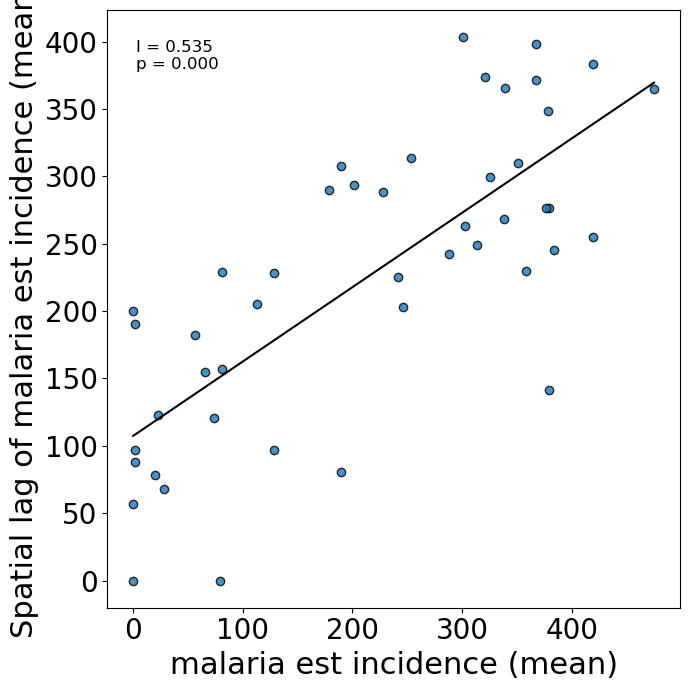

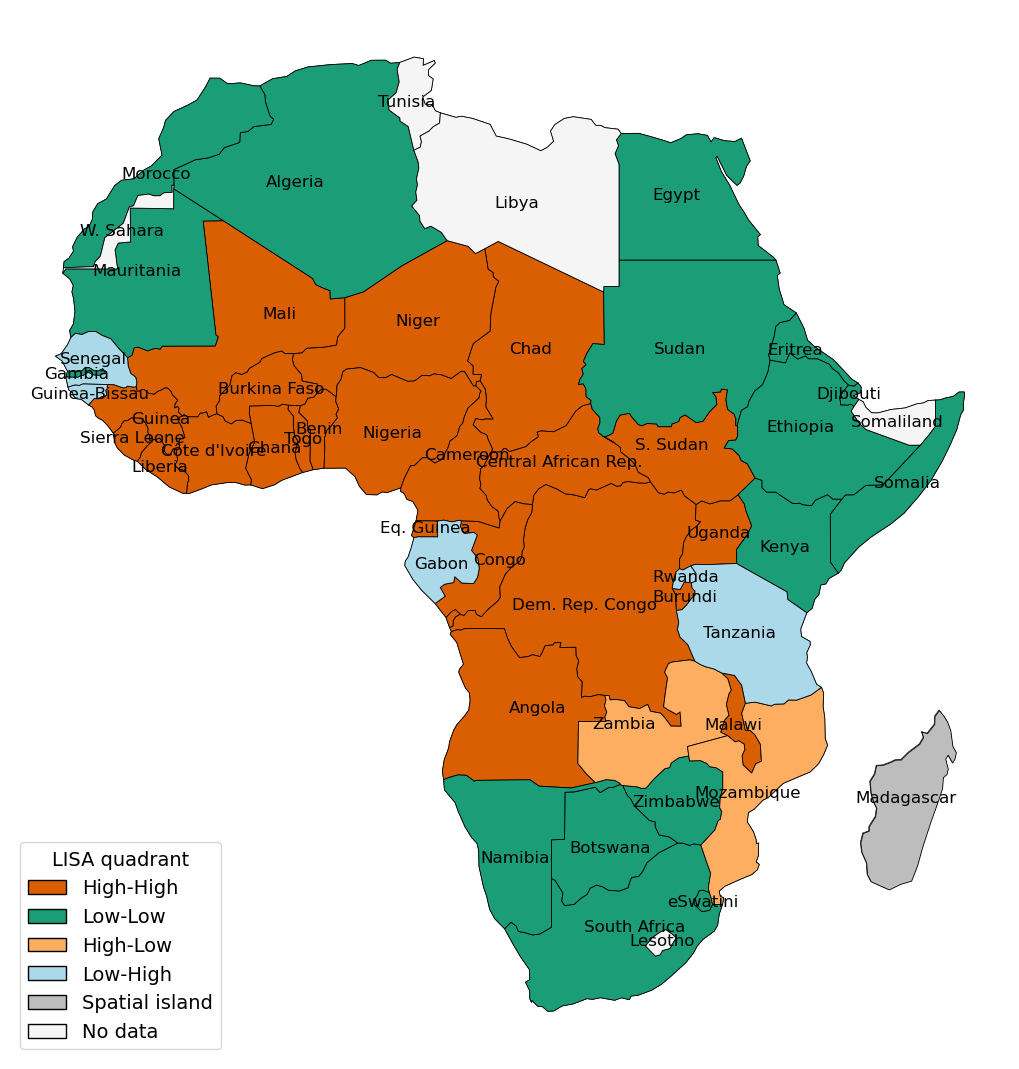

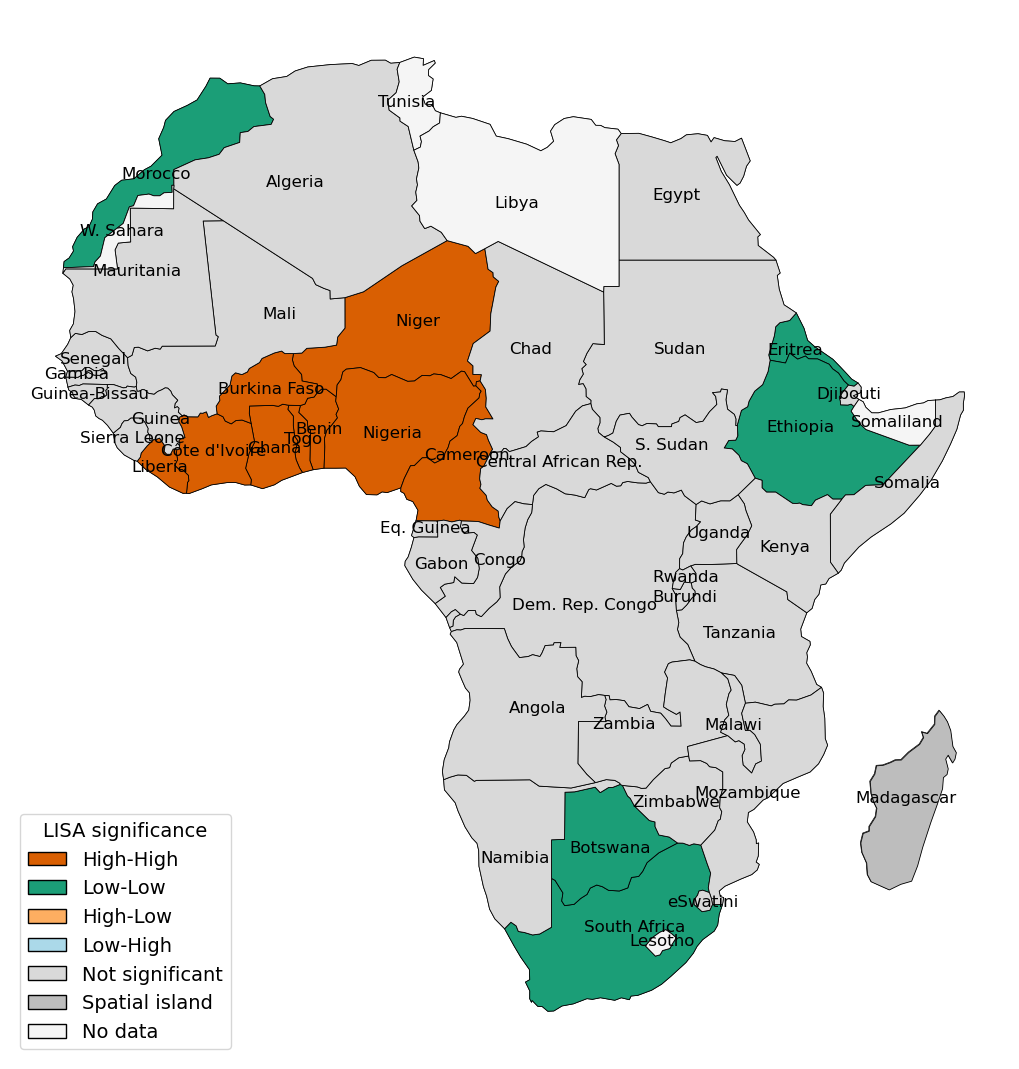

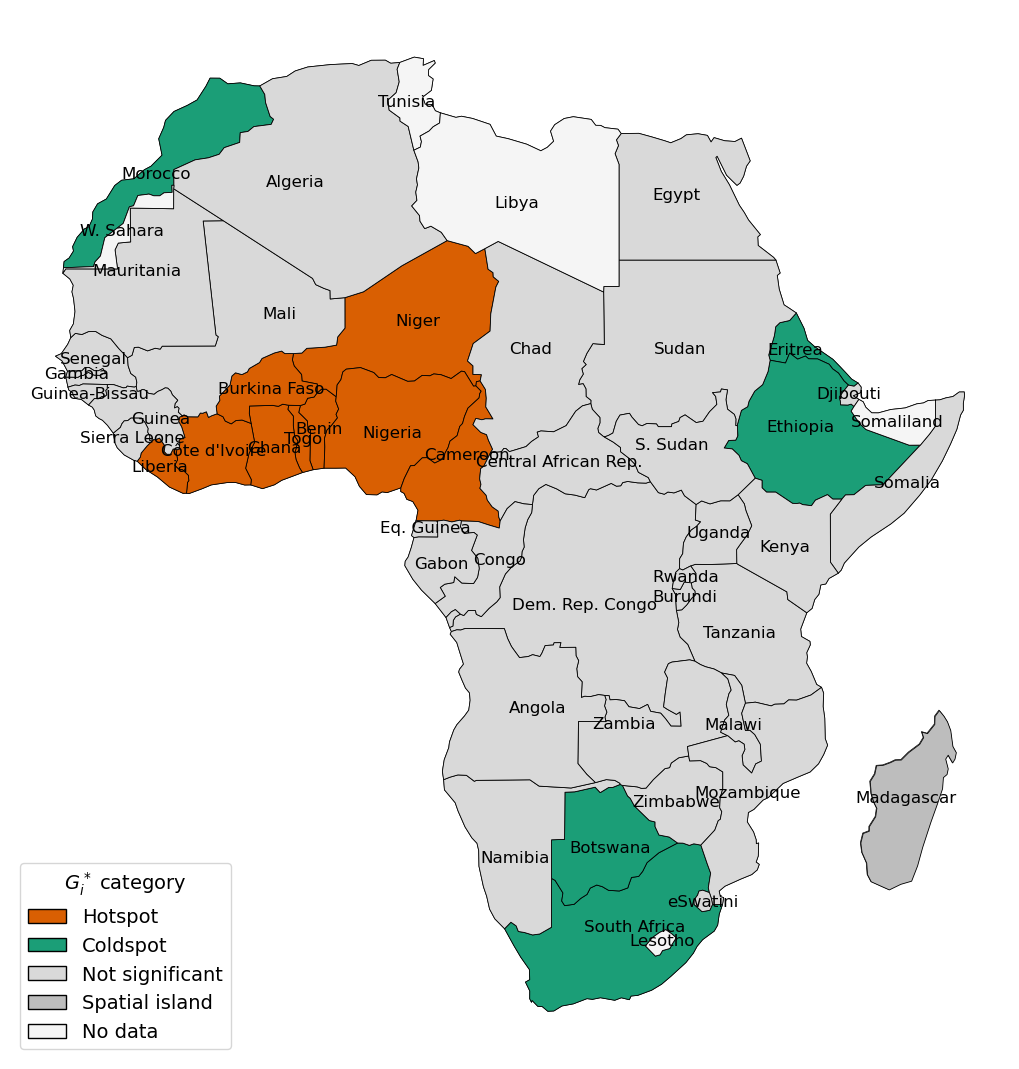

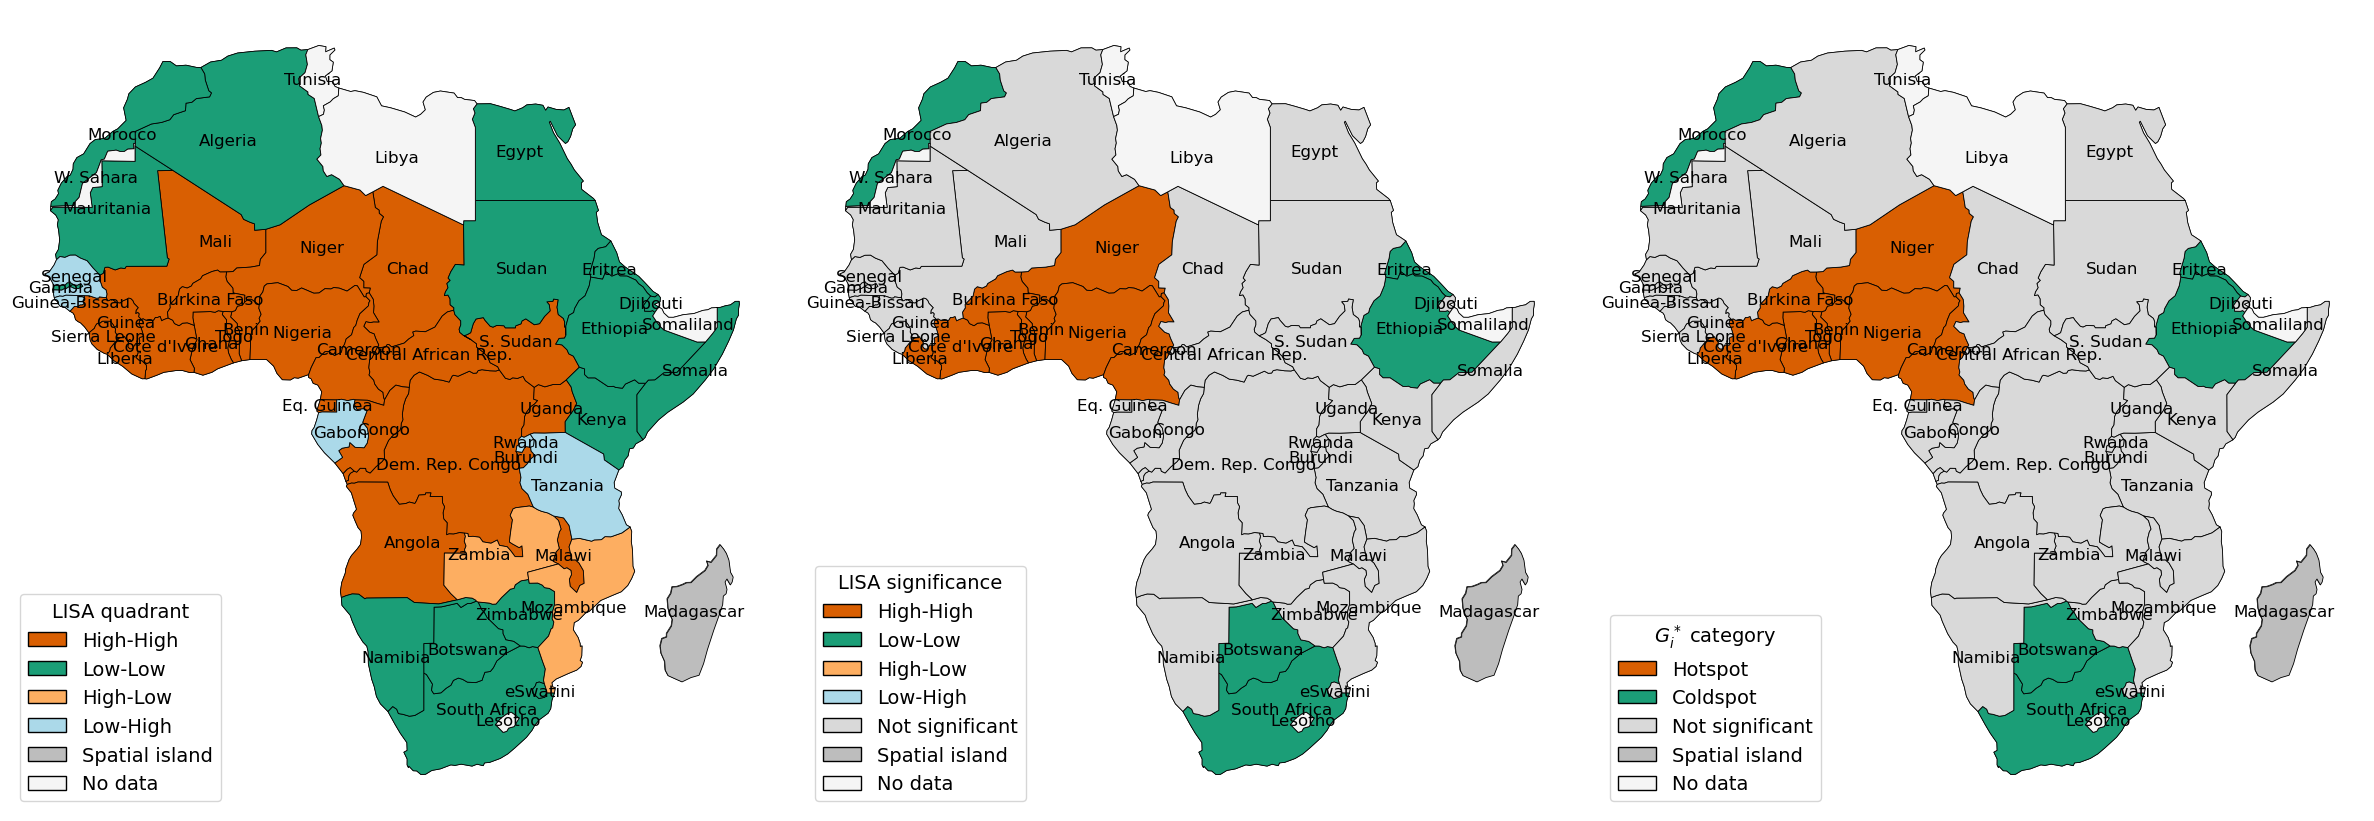


Done. Corrected spatial outputs saved in:
Geospatial/Africa_mean_malaria_est_incidence


In [9]:
# ============================================================
# CORRECTED STANDALONE SPATIAL ANALYSIS PIPELINE
# NO CLUSTERING
##  %pip install package
# Corrections included:
#   1. Explicit handling of spatial islands such as Madagascar
#   2. Correct Getis--Ord Gi* calculation using star=True
#   3. island_weight=np.nan for local inference
#   4. Explicit replacement of island statistics and p-values with NaN
#   5. Correct hotspot/coldspot classification when statistics are missing
#   6. Correct LISA classification for spatial islands
#   7. Spatial-island category added to legends and saved tables
#   8. Duplicate reporting block removed
#
# Supports:
#   - mean over study period
#   - sum over study period
#   - most recent year
#
# Supports:
#   - Africa
#   - whole world
# ============================================================

# ============================================================
# 0) IMPORTS
# ============================================================
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local


# ============================================================
# 1) GLOBAL DISPLAY + STYLE SETTINGS
# ============================================================
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 1000)

warnings.filterwarnings(
    "ignore",
    message="The weights matrix is not fully connected"
)


# ============================================================
# 2) USER SETTINGS
# ============================================================
DATA_PATH = "malaria-burden-all-WHO.csv"
ENCODING = "latin1"

WORLD_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

GEOGRAPHY = "Africa"                 # "Africa" or "World"
VALUE_COL_INPUT = "malaria_est_incidence"
SUMMARY_MODE = "mean"                # "mean", "sum", "latest_year"

ALPHA = 0.05
SEED = 42
N_PERM = 9999

# Plot switches
SHOW_LEGEND = True
SHOW_COUNTRY_LABELS = True

# Font settings
LABEL_FS = 22
TICK_FS = 20
LEGEND_FS = 14
MAP_LABEL_FS = 12

OUTDIR_BASE = (
    f"Geospatial/"
    f"{GEOGRAPHY}_{SUMMARY_MODE}_{VALUE_COL_INPUT}"
)
OUTDIR_TABLES = os.path.join(OUTDIR_BASE, "tables")
OUTDIR_FIGS = os.path.join(OUTDIR_BASE, "figures")

os.makedirs(OUTDIR_BASE, exist_ok=True)
os.makedirs(OUTDIR_TABLES, exist_ok=True)
os.makedirs(OUTDIR_FIGS, exist_ok=True)


# ============================================================
# 3) COUNTRY NAME HARMONISATION
# ============================================================
NAME_MAP = {
    "Cabo Verde": "Cape Verde",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Republic of the Congo": "Congo",
    "Eswatini": "eSwatini",
    "The Gambia": "Gambia",
    "Sao Tome and Principe": "São Tomé and Principe",
    "United Republic of Tanzania": "Tanzania",
    "Central African Republic": "Central African Rep.",
    "South Sudan": "S. Sudan",
    "Equatorial Guinea": "Eq. Guinea",
    "Syrian Arab Republic": "Syria",
    "Lao People's Democratic Republic": "Laos",
    "Viet Nam": "Vietnam",
    "Brunei Darussalam": "Brunei",
    "Iran (Islamic Republic of)": "Iran",
    "Russian Federation": "Russia",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Moldova, Republic of": "Moldova",
    "Türkiye": "Turkey",
    "Micronesia (Federated States of)": "Micronesia",
}


# ============================================================
# 4) DATA AND MAP HELPERS
# ============================================================
def load_data(data_path, encoding="latin1"):
    """Load the malaria dataset."""
    return pd.read_csv(data_path, encoding=encoding)


def load_world_map(world_url):
    """Load the Natural Earth country map."""
    world = gpd.read_file(world_url)

    world = world[world["NAME"] != "Antarctica"].copy()
    world = world[
        world.geometry.notna()
        & (~world.geometry.is_empty)
    ].copy()

    return world


def load_analysis_map(world_url, geography="Africa"):
    """Return the full world map and the requested analysis region."""
    world = load_world_map(world_url)

    if geography == "World":
        return world.copy(), world.copy()

    if geography == "Africa":
        region = world[world["CONTINENT"] == "Africa"].copy()
        region = region[
            region.geometry.notna()
            & (~region.geometry.is_empty)
        ].copy()

        return world, region

    raise ValueError("GEOGRAPHY must be 'Africa' or 'World'.")


def harmonise_country_names(
    df,
    country_col="Country",
    name_map=None
):
    """Harmonise country names between the data and map."""
    out = df.copy()
    out[country_col] = out[country_col].astype(str).str.strip()

    if name_map is not None:
        out[country_col] = out[country_col].replace(name_map)

    return out


def filter_df_to_map(
    df,
    map_gdf,
    country_col="Country",
    map_name_col="NAME"
):
    """Retain only countries represented in the selected map."""
    valid_names = set(
        map_gdf[map_name_col]
        .astype(str)
        .str.strip()
    )

    return df[
        df[country_col]
        .astype(str)
        .str.strip()
        .isin(valid_names)
    ].copy()


def compute_country_summary(
    df,
    country_col="Country",
    year_col="Year",
    value_col="malaria_est_incidence",
    summary_mode="mean"
):
    """Calculate a country-level mean, sum, or latest-year value."""
    temp = df[[country_col, year_col, value_col]].copy()

    temp[country_col] = (
        temp[country_col]
        .astype(str)
        .str.strip()
    )
    temp[year_col] = pd.to_numeric(
        temp[year_col],
        errors="coerce"
    )
    temp[value_col] = pd.to_numeric(
        temp[value_col],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=[country_col, year_col, value_col]
    ).copy()

    if summary_mode == "latest_year":
        latest_year = int(temp[year_col].max())

        temp = temp[
            temp[year_col] == latest_year
        ].copy()

        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = latest_year
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "mean":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .mean()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    if summary_mode == "sum":
        out = (
            temp.groupby(country_col, as_index=False)[value_col]
            .sum()
            .rename(
                columns={
                    country_col: "Country",
                    value_col: "summary_value"
                }
            )
            .sort_values(
                "summary_value",
                ascending=False
            )
            .reset_index(drop=True)
        )

        out["analysis_year"] = np.nan
        out["summary_mode"] = summary_mode
        return out

    raise ValueError(
        "SUMMARY_MODE must be 'mean', 'sum', or 'latest_year'."
    )


def merge_to_map(
    region_gdf,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
):
    """Merge the country summary values onto the geographic map."""
    return region_gdf.merge(
        country_summary,
        left_on=map_name_col,
        right_on=country_col,
        how="left"
    )


def add_country_labels(
    ax,
    gdf,
    label_col="NAME",
    fontsize=8,
    fontweight="normal",
    color="black"
):
    """Add country names at representative points."""
    if gdf.empty:
        return

    for _, row in gdf.iterrows():
        if pd.isna(row[label_col]):
            continue

        if row.geometry is None or row.geometry.is_empty:
            continue

        point = row.geometry.representative_point()

        ax.text(
            point.x,
            point.y,
            str(row[label_col]),
            fontsize=fontsize,
            ha="center",
            va="center",
            fontweight=fontweight,
            color=color
        )


# ============================================================
# 5) SPATIAL CLASSIFICATION HELPERS
# ============================================================
def lisa_category_sig(row, alpha=0.05):
    """Classify statistically significant local Moran results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if (
        pd.isna(row["local_I"])
        or pd.isna(row["local_p"])
        or pd.isna(row["quadrant"])
    ):
        return "No data"

    if row["local_p"] >= alpha:
        return "Not significant"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "Not significant"
    )


def lisa_quadrant_only(row):
    """Return the LISA quadrant regardless of significance."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    if pd.isna(row["quadrant"]):
        return "No data"

    quadrant_map = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return quadrant_map.get(
        int(row["quadrant"]),
        "No data"
    )


def gi_category(row, alpha=0.05):
    """Classify statistically significant Getis--Ord Gi* results."""
    if bool(row.get("Spatial_Island", False)):
        return "Spatial island"

    gi_z = row["GiZ"]
    gi_p = row["GiP"]

    if pd.isna(gi_z) or pd.isna(gi_p):
        return "No data"

    if gi_p >= alpha:
        return "Not significant"

    if gi_z > 0:
        return "Hotspot"

    if gi_z < 0:
        return "Coldspot"

    return "Not significant"


# ============================================================
# 6) SPATIAL STATISTICS
# ============================================================
def compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=0.05,
    seed=42,
    n_perm=9999
):
    """
    Calculate Global Moran's I, Local Moran's I, and Getis--Ord Gi*.

    Spatial islands are retained in the output but excluded from
    local inferential interpretation because Queen contiguity
    provides them with no geographic neighbors.
    """
    region_stats = region_map.dropna(
        subset=[value_col]
    ).copy()

    region_stats = region_stats[
        region_stats.geometry.notna()
        & (~region_stats.geometry.is_empty)
    ].copy()

    region_stats = (
        region_stats
        .sort_values("NAME")
        .reset_index(drop=True)
    )

    if len(region_stats) < 3:
        raise ValueError(
            "At least three countries with valid geometry and "
            "outcome data are required."
        )

    # --------------------------------------------------------
    # Queen-contiguity spatial weights
    # --------------------------------------------------------
    w = Queen.from_dataframe(
        region_stats,
        use_index=False
    )

    w.transform = "r"

    y = region_stats[value_col].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Identify spatial islands
    # --------------------------------------------------------
    island_indices = set(w.islands)

    region_stats["Spatial_Island"] = [
        idx in island_indices
        for idx in range(len(region_stats))
    ]

    print("\nSpatial islands under Queen contiguity:")

    if island_indices:
        for idx in sorted(island_indices):
            print(
                f"  Index {idx}: "
                f"{region_stats.loc[idx, 'NAME']}"
            )
    else:
        print("  None")

    # --------------------------------------------------------
    # Global Moran's I
    # --------------------------------------------------------
    moran = Moran(
        y,
        w,
        permutations=n_perm
    )

    # --------------------------------------------------------
    # Local Moran's I
    # --------------------------------------------------------
    lisa_obj = Moran_Local(
        y,
        w,
        permutations=n_perm,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["local_I"] = lisa_obj.Is
    region_stats["local_p"] = lisa_obj.p_sim
    region_stats["quadrant"] = lisa_obj.q

    # Explicitly remove invalid island results
    island_mask = region_stats["Spatial_Island"]

    region_stats.loc[
        island_mask,
        ["local_I", "local_p", "quadrant"]
    ] = np.nan

    region_stats["LISA_Category_Sig"] = (
        region_stats.apply(
            lambda row: lisa_category_sig(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    region_stats["LISA_Category_All"] = (
        region_stats.apply(
            lisa_quadrant_only,
            axis=1
        )
    )

    # --------------------------------------------------------
    # Local Getis--Ord Gi*
    # star=True is required for Gi*
    # --------------------------------------------------------
    g_local = G_Local(
        y,
        w,
        transform="R",
        permutations=n_perm,
        star=True,
        seed=seed,
        island_weight=np.nan
    )

    region_stats["GiZ"] = g_local.Zs
    region_stats["GiP"] = g_local.p_sim

    # Explicitly remove invalid island results
    region_stats.loc[
        island_mask,
        ["GiZ", "GiP"]
    ] = np.nan

    region_stats["Gi_Category"] = (
        region_stats.apply(
            lambda row: gi_category(
                row,
                alpha=alpha
            ),
            axis=1
        )
    )

    # --------------------------------------------------------
    # Merge LISA results back to full regional map
    # --------------------------------------------------------
    region_lisa = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "local_I",
                "local_p",
                "quadrant",
                "LISA_Category_Sig",
                "LISA_Category_All"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_lisa["LISA_Category_Sig"] = (
        region_lisa["LISA_Category_Sig"]
        .fillna("No data")
    )

    region_lisa["LISA_Category_All"] = (
        region_lisa["LISA_Category_All"]
        .fillna("No data")
    )

    # --------------------------------------------------------
    # Merge Gi* results back to full regional map
    # --------------------------------------------------------
    region_gi = region_map.merge(
        region_stats[
            [
                "NAME",
                value_col,
                "Spatial_Island",
                "GiZ",
                "GiP",
                "Gi_Category"
            ]
        ],
        on="NAME",
        how="left"
    )

    region_gi["Gi_Category"] = (
        region_gi["Gi_Category"]
        .fillna("No data")
    )

    return {
        "region_stats": region_stats,
        "w": w,
        "y": y,
        "moran": moran,
        "lisa_obj": lisa_obj,
        "g_local": g_local,
        "region_lisa": region_lisa,
        "region_gi": region_gi,
        "island_indices": sorted(island_indices)
    }


# ============================================================
# 7) PLOTTING FUNCTIONS
# ============================================================
def plot_moran_scatter(
    y,
    w,
    moran,
    xlabel,
    ylabel,
    out_png,
    out_pdf,
    figsize=(7, 7)
):
    """Plot the global Moran scatterplot."""
    lag_y = w.sparse.dot(y)

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        y,
        lag_y,
        edgecolor="black",
        alpha=0.8
    )

    coef = np.polyfit(y, lag_y, 1)
    x_line = np.linspace(
        y.min(),
        y.max(),
        100
    )
    y_line = (
        coef[0] * x_line
        + coef[1]
    )

    ax.plot(
        x_line,
        y_line,
        color="black",
        linewidth=1.5
    )

    ax.set_xlabel(
        xlabel,
        fontsize=LABEL_FS
    )
    ax.set_ylabel(
        ylabel,
        fontsize=LABEL_FS
    )

    ax.tick_params(
        axis="x",
        labelsize=TICK_FS
    )
    ax.tick_params(
        axis="y",
        labelsize=TICK_FS
    )

    ax.grid(False)

    ax.text(
        0.05,
        0.95,
        (
            f"I = {moran.I:.3f}\n"
            f"p = {moran.p_sim:.3f}"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12
    )

    plt.tight_layout()
    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_quadrant_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot all LISA quadrants, regardless of significance."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_All"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA quadrant",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_lisa_significance_map(
    base_gdf,
    region_lisa,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant LISA clusters and outliers."""
    color_map = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_lisa[
            region_lisa["LISA_Category_Sig"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_lisa[
            region_lisa.geometry.notna()
            & (~region_lisa.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title="LISA significance",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_gi_map(
    base_gdf,
    region_gi,
    out_png,
    out_pdf,
    figsize=(10, 12),
    show_legend=True,
    show_labels=True
):
    """Plot statistically significant Getis--Ord Gi* results."""
    color_map = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    base_gdf.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5,
        aspect=1
    )

    for category, color in color_map.items():
        subset = region_gi[
            region_gi["Gi_Category"] == category
        ].copy()

        subset = subset[
            subset.geometry.notna()
            & (~subset.geometry.is_empty)
        ].copy()

        if not subset.empty:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.6,
                aspect=1
            )

    if show_labels:
        label_gdf = region_gi[
            region_gi.geometry.notna()
            & (~region_gi.geometry.is_empty)
        ].copy()

        add_country_labels(
            ax,
            label_gdf,
            label_col="NAME",
            fontsize=MAP_LABEL_FS
        )

    if show_legend:
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor="black",
                label=category
            )
            for category, color in color_map.items()
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower left",
            fontsize=LEGEND_FS,
            frameon=True,
            title=r"$G_i^*$ category",
            title_fontsize=LEGEND_FS
        )

    ax.set_axis_off()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def plot_combined_lisa_sig_gi(
    base_gdf,
    region_lisa,
    region_gi,
    out_png,
    out_pdf,
    figsize=(24, 10),
    show_legend=True,
    show_labels=True
):
    """Plot LISA quadrant, significant LISA, and Gi* maps together."""
    lisa_quad_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    lisa_sig_colors = {
        "High-High": "#d95f02",
        "Low-Low": "#1b9e77",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    gi_colors = {
        "Hotspot": "#d95f02",
        "Coldspot": "#1b9e77",
        "Not significant": "#d9d9d9",
        "Spatial island": "#bdbdbd",
        "No data": "#f5f5f5"
    }

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize
    )

    panels = [
        (
            axes[0],
            region_lisa,
            "LISA_Category_All",
            lisa_quad_colors,
            "LISA quadrant"
        ),
        (
            axes[1],
            region_lisa,
            "LISA_Category_Sig",
            lisa_sig_colors,
            "LISA significance"
        ),
        (
            axes[2],
            region_gi,
            "Gi_Category",
            gi_colors,
            r"$G_i^*$ category"
        )
    ]

    for ax, gdf, category_col, color_map, legend_title in panels:
        base_gdf.plot(
            ax=ax,
            color="white",
            edgecolor="black",
            linewidth=0.5,
            aspect=1
        )

        for category, color in color_map.items():
            subset = gdf[
                gdf[category_col] == category
            ].copy()

            subset = subset[
                subset.geometry.notna()
                & (~subset.geometry.is_empty)
            ].copy()

            if not subset.empty:
                subset.plot(
                    ax=ax,
                    color=color,
                    edgecolor="black",
                    linewidth=0.6,
                    aspect=1
                )

        if show_labels:
            label_gdf = gdf[
                gdf.geometry.notna()
                & (~gdf.geometry.is_empty)
            ].copy()

            add_country_labels(
                ax,
                label_gdf,
                label_col="NAME",
                fontsize=MAP_LABEL_FS
            )

        if show_legend:
            legend_elements = [
                Patch(
                    facecolor=color,
                    edgecolor="black",
                    label=category
                )
                for category, color in color_map.items()
            ]

            ax.legend(
                handles=legend_elements,
                loc="lower left",
                fontsize=LEGEND_FS,
                frameon=True,
                title=legend_title,
                title_fontsize=LEGEND_FS
            )

        ax.set_axis_off()

    plt.tight_layout()

    plt.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        out_pdf,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


# ============================================================
# 8) LOAD DATA
# ============================================================
df = load_data(
    DATA_PATH,
    ENCODING
)

df = harmonise_country_names(
    df,
    country_col="Country",
    name_map=NAME_MAP
)

required_cols = [
    "Country",
    "Year",
    VALUE_COL_INPUT
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Input data is missing required columns: {missing_cols}"
    )

world_full, analysis_map = load_analysis_map(
    WORLD_URL,
    GEOGRAPHY
)

df_use = filter_df_to_map(
    df,
    analysis_map,
    country_col="Country",
    map_name_col="NAME"
)

print(f"Rows in input data: {len(df):,}")
print(
    f"Rows retained for {GEOGRAPHY}: "
    f"{len(df_use):,}"
)
print(
    f"Countries retained for {GEOGRAPHY}: "
    f"{df_use['Country'].nunique()}"
)


# ============================================================
# 9) COUNTRY SUMMARY
# ============================================================
country_summary = compute_country_summary(
    df_use,
    country_col="Country",
    year_col="Year",
    value_col=VALUE_COL_INPUT,
    summary_mode=SUMMARY_MODE
)

country_summary.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        "country_summary.csv"
    ),
    index=False
)

print("\nTop countries by summary value:")
print(country_summary.head(10))


# ============================================================
# 10) MERGE TO MAP
# ============================================================
region_map = merge_to_map(
    analysis_map,
    country_summary,
    map_name_col="NAME",
    country_col="Country"
)

region_map.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        "map_attributes.csv"
    ),
    index=False
)

print(
    "\nCountries matched on map:",
    region_map["summary_value"]
    .notna()
    .sum()
)


# ============================================================
# 11) SPATIAL ANALYSIS
# ============================================================
spatial_results = compute_spatial_statistics(
    region_map,
    value_col="summary_value",
    alpha=ALPHA,
    seed=SEED,
    n_perm=N_PERM
)

region_stats = spatial_results["region_stats"]
w = spatial_results["w"]
y = spatial_results["y"]
moran = spatial_results["moran"]
region_lisa = spatial_results["region_lisa"]
region_gi = spatial_results["region_gi"]


# ============================================================
# 12) SAVE TABLES
# ============================================================
pd.DataFrame(
    {
        "Metric": [
            "Global Moran's I",
            "Permutation p-value"
        ],
        "Value": [
            moran.I,
            moran.p_sim
        ]
    }
).to_csv(
    os.path.join(
        OUTDIR_TABLES,
        "global_morans_I_results.csv"
    ),
    index=False
)

region_stats.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        "region_stats_with_local_stats.csv"
    ),
    index=False
)

region_lisa.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        "lisa_results.csv"
    ),
    index=False
)

region_gi.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        "gi_results.csv"
    ),
    index=False
)

quadrant_map = {
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
}

lisa_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "Quadrant": region_stats["quadrant"],
        "Quadrant_Label": (
            region_stats["quadrant"]
            .map(quadrant_map)
        ),
        "Local_I": region_stats["local_I"],
        "p_value": region_stats["local_p"],
        "Final_Category_Sig": (
            region_stats["LISA_Category_Sig"]
        ),
        "Final_Category_All": (
            region_stats["LISA_Category_All"]
        )
    }
)

lisa_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        "lisa_diagnostic_table.csv"
    ),
    index=False
)

gi_diag = pd.DataFrame(
    {
        "Country": region_stats["NAME"],
        "summary_value": region_stats["summary_value"],
        "Spatial_Island": region_stats["Spatial_Island"],
        "GiZ": region_stats["GiZ"],
        "GiP": region_stats["GiP"],
        "Gi_Category": region_stats["Gi_Category"]
    }
)

gi_diag.to_csv(
    os.path.join(
        OUTDIR_TABLES,
        "gi_diagnostic_table.csv"
    ),
    index=False
)


# ============================================================
# 13) PRINT AND SAVE SIGNIFICANT SPATIAL GROUPS
# ============================================================
print("\n" + "=" * 70)
print("SIGNIFICANT LISA CLUSTERS")
print("=" * 70)

hh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

ll_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lh_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Low-High"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

hl_countries = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "High-Low"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

lisa_islands = (
    region_lisa[
        region_lisa["LISA_Category_Sig"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHigh-High clusters ({len(hh_countries)} countries):"
)
print(", ".join(hh_countries) or "None")

print(
    f"\nLow-Low clusters ({len(ll_countries)} countries):"
)
print(", ".join(ll_countries) or "None")

print(
    f"\nLow-High outliers ({len(lh_countries)} countries):"
)
print(", ".join(lh_countries) or "None")

print(
    f"\nHigh-Low outliers ({len(hl_countries)} countries):"
)
print(", ".join(hl_countries) or "None")

print(
    f"\nSpatial islands ({len(lisa_islands)} countries):"
)
print(", ".join(lisa_islands) or "None")

print("\n" + "=" * 70)
print("GETIS--ORD Gi* HOTSPOTS / COLDSPOTS")
print("=" * 70)

hotspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Hotspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

coldspot_countries = (
    region_gi[
        region_gi["Gi_Category"] == "Coldspot"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

gi_islands = (
    region_gi[
        region_gi["Gi_Category"] == "Spatial island"
    ]["NAME"]
    .dropna()
    .sort_values()
    .tolist()
)

print(
    f"\nHotspots ({len(hotspot_countries)} countries):"
)
print(", ".join(hotspot_countries) or "None")

print(
    f"\nColdspots ({len(coldspot_countries)} countries):"
)
print(", ".join(coldspot_countries) or "None")

print(
    f"\nSpatial islands ({len(gi_islands)} countries):"
)
print(", ".join(gi_islands) or "None")

with open(
    os.path.join(
        OUTDIR_TABLES,
        "significant_spatial_groups.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write("SIGNIFICANT LISA CLUSTERS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"High-High ({len(hh_countries)} countries)\n"
    )
    file.write(
        (", ".join(hh_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-Low ({len(ll_countries)} countries)\n"
    )
    file.write(
        (", ".join(ll_countries) or "None") + "\n\n"
    )

    file.write(
        f"Low-High ({len(lh_countries)} countries)\n"
    )
    file.write(
        (", ".join(lh_countries) or "None") + "\n\n"
    )

    file.write(
        f"High-Low ({len(hl_countries)} countries)\n"
    )
    file.write(
        (", ".join(hl_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(lisa_islands)} countries)\n"
    )
    file.write(
        (", ".join(lisa_islands) or "None") + "\n\n"
    )

    file.write("GETIS--ORD Gi* RESULTS\n")
    file.write("=" * 60 + "\n\n")

    file.write(
        f"Hotspots ({len(hotspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(hotspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Coldspots ({len(coldspot_countries)} countries)\n"
    )
    file.write(
        (", ".join(coldspot_countries) or "None") + "\n\n"
    )

    file.write(
        f"Spatial islands ({len(gi_islands)} countries)\n"
    )
    file.write(
        (", ".join(gi_islands) or "None") + "\n"
    )


# ============================================================
# 14) BUILD AXIS LABELS
# ============================================================
if SUMMARY_MODE == "latest_year":
    latest_year = int(
        country_summary["analysis_year"]
        .dropna()
        .iloc[0]
    )

    legend_label = (
        f"{VALUE_COL_INPUT.replace('_', ' ')} "
        f"in {latest_year}"
    )
else:
    latest_year = None

    legend_label = (
        f"{VALUE_COL_INPUT.replace('_', ' ')} "
        f"({SUMMARY_MODE})"
    )

figsize_main = (
    (10, 12)
    if GEOGRAPHY == "Africa"
    else (20, 10)
)


# ============================================================
# 15) MORAN SCATTERPLOT
# ============================================================
plot_moran_scatter(
    y=y,
    w=w,
    moran=moran,
    xlabel=legend_label,
    ylabel=f"Spatial lag of {legend_label}",
    out_png=os.path.join(
        OUTDIR_FIGS,
        "moran_scatter.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        "moran_scatter.pdf"
    ),
    figsize=(7, 7)
)


# ============================================================
# 16) LISA QUADRANT MAP
# ============================================================
plot_lisa_quadrant_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        "lisa_quadrant_map.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        "lisa_quadrant_map.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 17) LISA SIGNIFICANCE MAP
# ============================================================
plot_lisa_significance_map(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    out_png=os.path.join(
        OUTDIR_FIGS,
        "lisa_significance_map.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        "lisa_significance_map.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 18) GETIS--ORD Gi* MAP
# ============================================================
plot_gi_map(
    base_gdf=analysis_map,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        "gi_star_map.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        "gi_star_map.pdf"
    ),
    figsize=figsize_main,
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 19) COMBINED LISA + LISA SIGNIFICANCE + Gi* FIGURE
# ============================================================
plot_combined_lisa_sig_gi(
    base_gdf=analysis_map,
    region_lisa=region_lisa,
    region_gi=region_gi,
    out_png=os.path.join(
        OUTDIR_FIGS,
        "combined_lisa_sig_gi_star.png"
    ),
    out_pdf=os.path.join(
        OUTDIR_FIGS,
        "combined_lisa_sig_gi_star.pdf"
    ),
    figsize=(
        (24, 10)
        if GEOGRAPHY == "Africa"
        else (30, 10)
    ),
    show_legend=SHOW_LEGEND,
    show_labels=SHOW_COUNTRY_LABELS
)


# ============================================================
# 20) WORKFLOW SUMMARY
# ============================================================
with open(
    os.path.join(
        OUTDIR_BASE,
        "workflow_summary.txt"
    ),
    "w",
    encoding="utf-8"
) as file:
    file.write(
        "Corrected spatial-only analysis completed.\n\n"
    )

    file.write(f"Input file: {DATA_PATH}\n")
    file.write(f"Geography: {GEOGRAPHY}\n")
    file.write(f"Variable: {VALUE_COL_INPUT}\n")
    file.write(f"Summary mode: {SUMMARY_MODE}\n")

    if latest_year is not None:
        file.write(f"Analysis year: {latest_year}\n")

    file.write(f"Alpha: {ALPHA}\n")
    file.write(f"Seed: {SEED}\n")
    file.write(f"Permutations: {N_PERM}\n")
    file.write("Spatial weights: Queen contiguity\n")
    file.write("Local Getis--Ord statistic: Gi* (star=True)\n")
    file.write(
        "Spatial-island treatment: retained but local "
        "statistics set to missing\n"
    )
    file.write(f"Show legend: {SHOW_LEGEND}\n")
    file.write(
        f"Show country labels: {SHOW_COUNTRY_LABELS}\n\n"
    )

    file.write("Outputs:\n")
    file.write("- country_summary.csv\n")
    file.write("- map_attributes.csv\n")
    file.write("- global_morans_I_results.csv\n")
    file.write("- region_stats_with_local_stats.csv\n")
    file.write("- lisa_results.csv\n")
    file.write("- gi_results.csv\n")
    file.write("- lisa_diagnostic_table.csv\n")
    file.write("- gi_diagnostic_table.csv\n")
    file.write("- significant_spatial_groups.txt\n")
    file.write("- moran_scatter.png/.pdf\n")
    file.write("- lisa_quadrant_map.png/.pdf\n")
    file.write("- lisa_significance_map.png/.pdf\n")
    file.write("- gi_star_map.png/.pdf\n")
    file.write("- combined_lisa_sig_gi_star.png/.pdf\n")

print(
    f"\nDone. Corrected spatial outputs saved in:\n"
    f"{OUTDIR_BASE}"
)


In [12]:
# ============================================================
# STANDALONE SCRIPT:
# COMBINE INCIDENCE + MORTALITY GETIS--ORD Gi* RESULTS
#
# Features:
# - Loads incidence and mortality Gi* result tables
# - Handles NAME and/or Country columns
# - Prevents duplicate Country-column errors
# - Merges both outcomes by country
# - Prints the complete summary table
# - Formats p-values as "a × 10^b" instead of e-notation
# - Saves CSV, Excel, TXT, and publication-ready LaTeX
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# 0) SETTINGS
# ============================================================

# Set this to the folder containing "Publication-1".
# Leave as Path.cwd() when the notebook/script is already running
# from the project folder.
PROJECT_ROOT = Path.cwd()

BASE_DIR = PROJECT_ROOT / "Geospatial"
OUTDIR_FINAL = BASE_DIR / "Spatial_Summary"
OUTDIR_FINAL.mkdir(parents=True, exist_ok=True)

SUMMARY_MODE_TO_COMBINE = "mean"   # "mean", "sum", "latest_year"
GEOGRAPHY = "Africa"

# These should match your spatial-analysis input column names.
INCIDENCE_INPUT = "malaria_est_incidence"
MORTALITY_INPUT = "malaria_est_mortality"


# ============================================================
# 1) BUILD EXPECTED FILE PATHS
# ============================================================

# Expected tagged filenames produced by the updated spatial pipeline:
# gi_results_{VALUE_COL_INPUT}_{SUMMARY_MODE}.csv

INC_GI_FILE = (
    BASE_DIR
    / f"{GEOGRAPHY}_{SUMMARY_MODE_TO_COMBINE}_{INCIDENCE_INPUT}"
    / "tables"
    / f"gi_results_{INCIDENCE_INPUT}_{SUMMARY_MODE_TO_COMBINE}.csv"
)

MORT_GI_FILE = (
    BASE_DIR
    / f"{GEOGRAPHY}_{SUMMARY_MODE_TO_COMBINE}_{MORTALITY_INPUT}"
    / "tables"
    / f"gi_results_{MORTALITY_INPUT}_{SUMMARY_MODE_TO_COMBINE}.csv"
)


# ============================================================
# 2) ROBUST FILE SEARCH
# ============================================================

def find_result_file(expected_path, outcome_input, summary_mode):
    """
    Use the expected path when available.

    Otherwise, search recursively under BASE_DIR for a likely
    Gi* result file matching the outcome and summary mode.
    """
    if expected_path.exists():
        return expected_path

    patterns = [
        f"gi_results_{outcome_input}_{summary_mode}.csv",
        f"*gi_results*{outcome_input}*{summary_mode}*.csv",
        f"*{summary_mode}*{outcome_input}*gi_results*.csv",
        f"*{outcome_input}*{summary_mode}*.csv",
    ]

    matches = []

    if BASE_DIR.exists():
        for pattern in patterns:
            matches.extend(BASE_DIR.rglob(pattern))

    matches = list(dict.fromkeys(matches))

    if len(matches) == 1:
        print(
            "\nExpected file not found, but one matching file was located:"
        )
        print(matches[0].resolve())
        return matches[0]

    if len(matches) > 1:
        print(
            f"\nExpected file was not found:\n{expected_path.resolve()}"
        )
        print("\nPossible matches:")

        for i, path in enumerate(matches, start=1):
            print(f"{i}. {path.resolve()}")

        raise FileNotFoundError(
            "\nMultiple candidate files were found. "
            "Set INC_GI_FILE or MORT_GI_FILE directly to the correct file."
        )

    raise FileNotFoundError(
        f"\nCould not find the expected file:\n"
        f"{expected_path.resolve()}\n\n"
        f"Check PROJECT_ROOT, folder names, SUMMARY_MODE_TO_COMBINE, "
        f"and the saved Gi* filenames."
    )


INC_GI_FILE = find_result_file(
    INC_GI_FILE,
    INCIDENCE_INPUT,
    SUMMARY_MODE_TO_COMBINE
)

MORT_GI_FILE = find_result_file(
    MORT_GI_FILE,
    MORTALITY_INPUT,
    SUMMARY_MODE_TO_COMBINE
)

print("\nIncidence Gi* file:")
print(INC_GI_FILE.resolve())

print("\nMortality Gi* file:")
print(MORT_GI_FILE.resolve())


# ============================================================
# 3) LOAD TABLES
# ============================================================

inc_gi_raw = pd.read_csv(INC_GI_FILE)
mort_gi_raw = pd.read_csv(MORT_GI_FILE)


# ============================================================
# 4) HELPER FUNCTIONS
# ============================================================

def remove_duplicate_columns(df):
    """
    Remove duplicated column names, keeping the first occurrence.
    """
    return df.loc[:, ~df.columns.duplicated()].copy()


def prepare_gi_table(df, prefix):
    """
    Prepare one Gi* result table for merging.

    Expected possible columns:
    - NAME or Country
    - GiZ
    - GiP
    - Gi_Category
    """
    out = remove_duplicate_columns(df.copy())

    # --------------------------------------------------------
    # Create one clean Country column
    # --------------------------------------------------------
    if "Country" not in out.columns and "NAME" in out.columns:
        out = out.rename(columns={"NAME": "Country"})

    elif "Country" in out.columns and "NAME" in out.columns:
        out["Country"] = out["Country"].fillna(out["NAME"])
        out = out.drop(columns=["NAME"])

    if "Country" not in out.columns:
        raise ValueError(
            f"No country column found for {prefix}. "
            "Expected either 'Country' or 'NAME'."
        )

    # --------------------------------------------------------
    # Check required Gi* columns
    # --------------------------------------------------------
    required_cols = ["GiZ", "GiP", "Gi_Category"]
    missing = [
        col for col in required_cols
        if col not in out.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required Gi* columns for {prefix}: {missing}\n"
            f"Available columns: {list(out.columns)}"
        )

    # --------------------------------------------------------
    # Rename columns for outcome-specific merging
    # --------------------------------------------------------
    out = out.rename(
        columns={
            "GiZ": f"{prefix}_GiZ",
            "GiP": f"{prefix}_P",
            "Gi_Category": f"{prefix}_Category"
        }
    )

    keep_cols = [
        "Country",
        f"{prefix}_GiZ",
        f"{prefix}_P",
        f"{prefix}_Category"
    ]

    out = out[keep_cols].copy()

    # --------------------------------------------------------
    # Clean countries
    # --------------------------------------------------------
    out["Country"] = (
        out["Country"]
        .astype("string")
        .str.strip()
    )

    out = out.dropna(subset=["Country"])
    out = out[out["Country"] != ""]

    out = out.drop_duplicates(
        subset="Country",
        keep="first"
    )

    return out


def format_number(x, decimals=3):
    """
    Format Gi* statistics to a fixed number of decimal places.
    """
    if pd.isna(x):
        return ""

    return f"{float(x):.{decimals}f}"


def format_pvalue_display(x):
    """
    Format p-values as:
        3.100 × 10^-3

    rather than:
        3.100e-03
    """
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "0"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)

    return f"{mantissa:.3f} × 10^{exponent}"


def format_pvalue_latex(x):
    """
    Format p-values for LaTeX as:
        $3.100\\times10^{-3}$
    """
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "$0$"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)

    return rf"${mantissa:.3f}\times10^{{{exponent}}}$"


def latex_escape(text):
    """
    Escape LaTeX special characters.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    replacements = [
        ("\\", r"\textbackslash{}"),
        ("&", r"\&"),
        ("%", r"\%"),
        ("$", r"\$"),
        ("#", r"\#"),
        ("_", r"\_"),
        ("{", r"\{"),
        ("}", r"\}"),
        ("~", r"\textasciitilde{}"),
        ("^", r"\textasciicircum{}"),
    ]

    for old, new in replacements:
        text = text.replace(old, new)

    return text


# ============================================================
# 5) PREPARE INCIDENCE + MORTALITY TABLES
# ============================================================

inc_gi = prepare_gi_table(
    inc_gi_raw,
    "Incidence"
)

mort_gi = prepare_gi_table(
    mort_gi_raw,
    "Mortality"
)


# ============================================================
# 6) MERGE INCIDENCE + MORTALITY
# ============================================================

gi_summary_numeric = inc_gi.merge(
    mort_gi,
    on="Country",
    how="outer",
    validate="one_to_one"
)

gi_summary_numeric = remove_duplicate_columns(
    gi_summary_numeric
)

gi_summary_numeric = (
    gi_summary_numeric
    .sort_values("Country")
    .reset_index(drop=True)
)

# Ensure numeric columns remain numeric in exported CSV/Excel
numeric_cols = [
    "Incidence_GiZ",
    "Incidence_P",
    "Mortality_GiZ",
    "Mortality_P"
]

for col in numeric_cols:
    gi_summary_numeric[col] = pd.to_numeric(
        gi_summary_numeric[col],
        errors="coerce"
    )


# ============================================================
# 7) CREATE PRINT/DISPLAY TABLE
# ============================================================

gi_summary_display = gi_summary_numeric.copy()

gi_summary_display["Incidence_GiZ"] = (
    gi_summary_display["Incidence_GiZ"]
    .apply(format_number)
)

gi_summary_display["Mortality_GiZ"] = (
    gi_summary_display["Mortality_GiZ"]
    .apply(format_number)
)

gi_summary_display["Incidence_P"] = (
    gi_summary_display["Incidence_P"]
    .apply(format_pvalue_display)
)

gi_summary_display["Mortality_P"] = (
    gi_summary_display["Mortality_P"]
    .apply(format_pvalue_display)
)

# Optional clearer display column names
gi_summary_display = gi_summary_display.rename(
    columns={
        "Incidence_GiZ": "Incidence Gi*",
        "Incidence_P": "Incidence P-value",
        "Incidence_Category": "Incidence Category",
        "Mortality_GiZ": "Mortality Gi*",
        "Mortality_P": "Mortality P-value",
        "Mortality_Category": "Mortality Category"
    }
)


# ============================================================
# 8) PRINT COMPLETE SUMMARY TABLE
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)

print("\n")
print("=" * 170)
print("GETIS--ORD Gi* SUMMARY TABLE: MALARIA INCIDENCE AND MORTALITY")
print("=" * 170)

print(
    gi_summary_display.to_string(
        index=False,
        justify="left",
        na_rep=""
    )
)

print("=" * 170)
print(f"Total countries: {len(gi_summary_display)}")
print("=" * 170)


# ============================================================
# 9) SAVE CSV + EXCEL
# ============================================================

OUTPUT_TAG = (
    f"{SUMMARY_MODE_TO_COMBINE}_incidence_mortality_gi_summary"
)

csv_numeric_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}_numeric.csv"
)

csv_display_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}_formatted.csv"
)

xlsx_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.xlsx"
)

# Numeric CSV preserves numeric p-values for further analysis
gi_summary_numeric.to_csv(
    csv_numeric_file,
    index=False
)

# Formatted CSV displays × 10^ notation
gi_summary_display.to_csv(
    csv_display_file,
    index=False
)

# Excel keeps numeric values
gi_summary_numeric.to_excel(
    xlsx_file,
    index=False
)


# ============================================================
# 10) SAVE PRINTABLE TEXT TABLE
# ============================================================

txt_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.txt"
)

with txt_file.open(
    "w",
    encoding="utf-8"
) as file:

    file.write("=" * 170 + "\n")
    file.write(
        "GETIS--ORD Gi* SUMMARY TABLE: "
        "MALARIA INCIDENCE AND MORTALITY\n"
    )
    file.write("=" * 170 + "\n\n")

    file.write(
        gi_summary_display.to_string(
            index=False,
            justify="left",
            na_rep=""
        )
    )

    file.write("\n\n")
    file.write(
        f"Total countries: {len(gi_summary_display)}\n"
    )


# ============================================================
# 11) SAVE LATEX TABLE
# ============================================================

latex_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.tex"
)

summary_caption = {
    "mean": "mean over 2000--2024",
    "sum": "cumulative burden over 2000--2024",
    "latest_year": "2024"
}.get(
    SUMMARY_MODE_TO_COMBINE,
    SUMMARY_MODE_TO_COMBINE.replace("_", " ")
)

with latex_file.open(
    "w",
    encoding="utf-8"
) as file:

    file.write(r"\begin{table}[htbp]" + "\n")
    file.write(r"\centering" + "\n")

    file.write(
        rf"\caption{{Summary of spatial clustering measured using "
        rf"Getis--Ord $G_i^*$ statistics for malaria incidence and "
        rf"mortality ({summary_caption}).}}"
        + "\n"
    )

    file.write(
        rf"\label{{Stab:spatial_auto_gi_{SUMMARY_MODE_TO_COMBINE}}}"
        + "\n"
    )

    file.write(r"\small" + "\n")
    file.write(r"\resizebox{\textwidth}{!}{%" + "\n")
    file.write(r"\begin{tabular}{lcccccc}" + "\n")
    file.write(r"\hline" + "\n")

    file.write(
        r"& \multicolumn{3}{c}{Malaria incidence} "
        r"& \multicolumn{3}{c}{Malaria mortality} \\"
        + "\n"
    )

    file.write(
        r"\cline{2-4} \cline{5-7}"
        + "\n"
    )

    file.write(
        r"Country "
        r"& $G_i^*$ "
        r"& $P$-value "
        r"& Category "
        r"& $G_i^*$ "
        r"& $P$-value "
        r"& Category \\"
        + "\n"
    )

    file.write(r"\hline" + "\n")

    for _, row in gi_summary_numeric.iterrows():

        country = latex_escape(
            row.get("Country", "")
        )

        inc_giz = format_number(
            row.get("Incidence_GiZ", np.nan)
        )

        inc_p = format_pvalue_latex(
            row.get("Incidence_P", np.nan)
        )

        inc_cat = latex_escape(
            row.get("Incidence_Category", "")
        )

        mort_giz = format_number(
            row.get("Mortality_GiZ", np.nan)
        )

        mort_p = format_pvalue_latex(
            row.get("Mortality_P", np.nan)
        )

        mort_cat = latex_escape(
            row.get("Mortality_Category", "")
        )

        file.write(
            f"{country} "
            f"& {inc_giz} "
            f"& {inc_p} "
            f"& {inc_cat} "
            f"& {mort_giz} "
            f"& {mort_p} "
            f"& {mort_cat} "
            r"\\"
            + "\n"
        )

    file.write(r"\hline" + "\n")
    file.write(r"\end{tabular}%" + "\n")
    file.write(r"}" + "\n")
    file.write(r"\end{table}" + "\n")


# ============================================================
# 12) DONE
# ============================================================

print("\nFiles saved successfully:")
print(f"Numeric CSV:   {csv_numeric_file.resolve()}")
print(f"Formatted CSV: {csv_display_file.resolve()}")
print(f"Excel:         {xlsx_file.resolve()}")
print(f"Text table:    {txt_file.resolve()}")
print(f"LaTeX table:   {latex_file.resolve()}")



Incidence Gi* file:
C:\Users\lubna\OneDrive - Meharry Medical College\Documents\Meharry 2023\Meharry - Research\Megan-capstone-Spring-2026\My-Work\Geospatial\Africa_mean_malaria_est_incidence\tables\gi_results_malaria_est_incidence_mean.csv

Mortality Gi* file:
C:\Users\lubna\OneDrive - Meharry Medical College\Documents\Meharry 2023\Meharry - Research\Megan-capstone-Spring-2026\My-Work\Geospatial\Africa_mean_malaria_est_mortality\tables\gi_results_malaria_est_mortality_mean.csv


GETIS--ORD Gi* SUMMARY TABLE: MALARIA INCIDENCE AND MORTALITY
Country              Incidence Gi* Incidence P-value Incidence Category Mortality Gi* Mortality P-value Mortality Category
             Algeria -0.360        3.970 × 10^-1     Not significant    -0.037        3.003 × 10^-1     Not significant   
              Angola  0.107        4.350 × 10^-1     Not significant     0.107        4.138 × 10^-1     Not significant   
               Benin  1.208        2.600 × 10^-3             Hotspot     1.343     

In [13]:
# ============================================================
# STANDALONE SCRIPT:
# COMBINE INCIDENCE + MORTALITY GETIS--ORD Gi* RESULTS
#
# Features:
# - Loads incidence and mortality Gi* result tables
# - Handles NAME and/or Country columns
# - Prevents duplicate Country-column errors
# - Merges both outcomes by country
# - Prints the complete summary table
# - Formats p-values as "a × 10^b" instead of e-notation
# - Saves CSV, Excel, TXT, and publication-ready LaTeX
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# 0) SETTINGS
# ============================================================

# Set this to the folder containing "Publication-1".
# Leave as Path.cwd() when the notebook/script is already running
# from the project folder.
PROJECT_ROOT = Path.cwd()

BASE_DIR = PROJECT_ROOT / "Geospatial"
OUTDIR_FINAL = BASE_DIR / "Spatial_Summary"
OUTDIR_FINAL.mkdir(parents=True, exist_ok=True)

SUMMARY_MODE_TO_COMBINE = "latest_year"   # "mean", "sum", "latest_year"
GEOGRAPHY = "Africa"

# These should match your spatial-analysis input column names.
INCIDENCE_INPUT = "malaria_est_incidence"
MORTALITY_INPUT = "malaria_est_mortality"


# ============================================================
# 1) BUILD EXPECTED FILE PATHS
# ============================================================

# Expected tagged filenames produced by the updated spatial pipeline:
# gi_results_{VALUE_COL_INPUT}_{SUMMARY_MODE}.csv

INC_GI_FILE = (
    BASE_DIR
    / f"{GEOGRAPHY}_{SUMMARY_MODE_TO_COMBINE}_{INCIDENCE_INPUT}"
    / "tables"
    / f"gi_results_{INCIDENCE_INPUT}_{SUMMARY_MODE_TO_COMBINE}.csv"
)

MORT_GI_FILE = (
    BASE_DIR
    / f"{GEOGRAPHY}_{SUMMARY_MODE_TO_COMBINE}_{MORTALITY_INPUT}"
    / "tables"
    / f"gi_results_{MORTALITY_INPUT}_{SUMMARY_MODE_TO_COMBINE}.csv"
)


# ============================================================
# 2) ROBUST FILE SEARCH
# ============================================================

def find_result_file(expected_path, outcome_input, summary_mode):
    """
    Use the expected path when available.

    Otherwise, search recursively under BASE_DIR for a likely
    Gi* result file matching the outcome and summary mode.
    """
    if expected_path.exists():
        return expected_path

    patterns = [
        f"gi_results_{outcome_input}_{summary_mode}.csv",
        f"*gi_results*{outcome_input}*{summary_mode}*.csv",
        f"*{summary_mode}*{outcome_input}*gi_results*.csv",
        f"*{outcome_input}*{summary_mode}*.csv",
    ]

    matches = []

    if BASE_DIR.exists():
        for pattern in patterns:
            matches.extend(BASE_DIR.rglob(pattern))

    matches = list(dict.fromkeys(matches))

    if len(matches) == 1:
        print(
            "\nExpected file not found, but one matching file was located:"
        )
        print(matches[0].resolve())
        return matches[0]

    if len(matches) > 1:
        print(
            f"\nExpected file was not found:\n{expected_path.resolve()}"
        )
        print("\nPossible matches:")

        for i, path in enumerate(matches, start=1):
            print(f"{i}. {path.resolve()}")

        raise FileNotFoundError(
            "\nMultiple candidate files were found. "
            "Set INC_GI_FILE or MORT_GI_FILE directly to the correct file."
        )

    raise FileNotFoundError(
        f"\nCould not find the expected file:\n"
        f"{expected_path.resolve()}\n\n"
        f"Check PROJECT_ROOT, folder names, SUMMARY_MODE_TO_COMBINE, "
        f"and the saved Gi* filenames."
    )


INC_GI_FILE = find_result_file(
    INC_GI_FILE,
    INCIDENCE_INPUT,
    SUMMARY_MODE_TO_COMBINE
)

MORT_GI_FILE = find_result_file(
    MORT_GI_FILE,
    MORTALITY_INPUT,
    SUMMARY_MODE_TO_COMBINE
)

print("\nIncidence Gi* file:")
print(INC_GI_FILE.resolve())

print("\nMortality Gi* file:")
print(MORT_GI_FILE.resolve())


# ============================================================
# 3) LOAD TABLES
# ============================================================

inc_gi_raw = pd.read_csv(INC_GI_FILE)
mort_gi_raw = pd.read_csv(MORT_GI_FILE)


# ============================================================
# 4) HELPER FUNCTIONS
# ============================================================

def remove_duplicate_columns(df):
    """
    Remove duplicated column names, keeping the first occurrence.
    """
    return df.loc[:, ~df.columns.duplicated()].copy()


def prepare_gi_table(df, prefix):
    """
    Prepare one Gi* result table for merging.

    Expected possible columns:
    - NAME or Country
    - GiZ
    - GiP
    - Gi_Category
    """
    out = remove_duplicate_columns(df.copy())

    # --------------------------------------------------------
    # Create one clean Country column
    # --------------------------------------------------------
    if "Country" not in out.columns and "NAME" in out.columns:
        out = out.rename(columns={"NAME": "Country"})

    elif "Country" in out.columns and "NAME" in out.columns:
        out["Country"] = out["Country"].fillna(out["NAME"])
        out = out.drop(columns=["NAME"])

    if "Country" not in out.columns:
        raise ValueError(
            f"No country column found for {prefix}. "
            "Expected either 'Country' or 'NAME'."
        )

    # --------------------------------------------------------
    # Check required Gi* columns
    # --------------------------------------------------------
    required_cols = ["GiZ", "GiP", "Gi_Category"]
    missing = [
        col for col in required_cols
        if col not in out.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required Gi* columns for {prefix}: {missing}\n"
            f"Available columns: {list(out.columns)}"
        )

    # --------------------------------------------------------
    # Rename columns for outcome-specific merging
    # --------------------------------------------------------
    out = out.rename(
        columns={
            "GiZ": f"{prefix}_GiZ",
            "GiP": f"{prefix}_P",
            "Gi_Category": f"{prefix}_Category"
        }
    )

    keep_cols = [
        "Country",
        f"{prefix}_GiZ",
        f"{prefix}_P",
        f"{prefix}_Category"
    ]

    out = out[keep_cols].copy()

    # --------------------------------------------------------
    # Clean countries
    # --------------------------------------------------------
    out["Country"] = (
        out["Country"]
        .astype("string")
        .str.strip()
    )

    out = out.dropna(subset=["Country"])
    out = out[out["Country"] != ""]

    out = out.drop_duplicates(
        subset="Country",
        keep="first"
    )

    return out


def format_number(x, decimals=3):
    """
    Format Gi* statistics to a fixed number of decimal places.
    """
    if pd.isna(x):
        return ""

    return f"{float(x):.{decimals}f}"


def format_pvalue_display(x):
    """
    Format p-values as:
        3.100 × 10^-3

    rather than:
        3.100e-03
    """
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "0"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)

    return f"{mantissa:.3f} × 10^{exponent}"


def format_pvalue_latex(x):
    """
    Format p-values for LaTeX as:
        $3.100\\times10^{-3}$
    """
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "$0$"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)

    return rf"${mantissa:.3f}\times10^{{{exponent}}}$"


def latex_escape(text):
    """
    Escape LaTeX special characters.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    replacements = [
        ("\\", r"\textbackslash{}"),
        ("&", r"\&"),
        ("%", r"\%"),
        ("$", r"\$"),
        ("#", r"\#"),
        ("_", r"\_"),
        ("{", r"\{"),
        ("}", r"\}"),
        ("~", r"\textasciitilde{}"),
        ("^", r"\textasciicircum{}"),
    ]

    for old, new in replacements:
        text = text.replace(old, new)

    return text


# ============================================================
# 5) PREPARE INCIDENCE + MORTALITY TABLES
# ============================================================

inc_gi = prepare_gi_table(
    inc_gi_raw,
    "Incidence"
)

mort_gi = prepare_gi_table(
    mort_gi_raw,
    "Mortality"
)


# ============================================================
# 6) MERGE INCIDENCE + MORTALITY
# ============================================================

gi_summary_numeric = inc_gi.merge(
    mort_gi,
    on="Country",
    how="outer",
    validate="one_to_one"
)

gi_summary_numeric = remove_duplicate_columns(
    gi_summary_numeric
)

gi_summary_numeric = (
    gi_summary_numeric
    .sort_values("Country")
    .reset_index(drop=True)
)

# Ensure numeric columns remain numeric in exported CSV/Excel
numeric_cols = [
    "Incidence_GiZ",
    "Incidence_P",
    "Mortality_GiZ",
    "Mortality_P"
]

for col in numeric_cols:
    gi_summary_numeric[col] = pd.to_numeric(
        gi_summary_numeric[col],
        errors="coerce"
    )


# ============================================================
# 7) CREATE PRINT/DISPLAY TABLE
# ============================================================

gi_summary_display = gi_summary_numeric.copy()

gi_summary_display["Incidence_GiZ"] = (
    gi_summary_display["Incidence_GiZ"]
    .apply(format_number)
)

gi_summary_display["Mortality_GiZ"] = (
    gi_summary_display["Mortality_GiZ"]
    .apply(format_number)
)

gi_summary_display["Incidence_P"] = (
    gi_summary_display["Incidence_P"]
    .apply(format_pvalue_display)
)

gi_summary_display["Mortality_P"] = (
    gi_summary_display["Mortality_P"]
    .apply(format_pvalue_display)
)

# Optional clearer display column names
gi_summary_display = gi_summary_display.rename(
    columns={
        "Incidence_GiZ": "Incidence Gi*",
        "Incidence_P": "Incidence P-value",
        "Incidence_Category": "Incidence Category",
        "Mortality_GiZ": "Mortality Gi*",
        "Mortality_P": "Mortality P-value",
        "Mortality_Category": "Mortality Category"
    }
)


# ============================================================
# 8) PRINT COMPLETE SUMMARY TABLE
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)

print("\n")
print("=" * 170)
print("GETIS--ORD Gi* SUMMARY TABLE: MALARIA INCIDENCE AND MORTALITY")
print("=" * 170)

print(
    gi_summary_display.to_string(
        index=False,
        justify="left",
        na_rep=""
    )
)

print("=" * 170)
print(f"Total countries: {len(gi_summary_display)}")
print("=" * 170)


# ============================================================
# 9) SAVE CSV + EXCEL
# ============================================================

OUTPUT_TAG = (
    f"{SUMMARY_MODE_TO_COMBINE}_incidence_mortality_gi_summary"
)

csv_numeric_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}_numeric.csv"
)

csv_display_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}_formatted.csv"
)

xlsx_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.xlsx"
)

# Numeric CSV preserves numeric p-values for further analysis
gi_summary_numeric.to_csv(
    csv_numeric_file,
    index=False
)

# Formatted CSV displays × 10^ notation
gi_summary_display.to_csv(
    csv_display_file,
    index=False
)

# Excel keeps numeric values
gi_summary_numeric.to_excel(
    xlsx_file,
    index=False
)


# ============================================================
# 10) SAVE PRINTABLE TEXT TABLE
# ============================================================

txt_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.txt"
)

with txt_file.open(
    "w",
    encoding="utf-8"
) as file:

    file.write("=" * 170 + "\n")
    file.write(
        "GETIS--ORD Gi* SUMMARY TABLE: "
        "MALARIA INCIDENCE AND MORTALITY\n"
    )
    file.write("=" * 170 + "\n\n")

    file.write(
        gi_summary_display.to_string(
            index=False,
            justify="left",
            na_rep=""
        )
    )

    file.write("\n\n")
    file.write(
        f"Total countries: {len(gi_summary_display)}\n"
    )


# ============================================================
# 11) SAVE LATEX TABLE
# ============================================================

latex_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.tex"
)

summary_caption = {
    "mean": "mean over 2000--2024",
    "sum": "cumulative burden over 2000--2024",
    "latest_year": "2024"
}.get(
    SUMMARY_MODE_TO_COMBINE,
    SUMMARY_MODE_TO_COMBINE.replace("_", " ")
)

with latex_file.open(
    "w",
    encoding="utf-8"
) as file:

    file.write(r"\begin{table}[htbp]" + "\n")
    file.write(r"\centering" + "\n")

    file.write(
        rf"\caption{{Summary of spatial clustering measured using "
        rf"Getis--Ord $G_i^*$ statistics for malaria incidence and "
        rf"mortality ({summary_caption}).}}"
        + "\n"
    )

    file.write(
        rf"\label{{Stab:spatial_auto_gi_{SUMMARY_MODE_TO_COMBINE}}}"
        + "\n"
    )

    file.write(r"\small" + "\n")
    file.write(r"\resizebox{\textwidth}{!}{%" + "\n")
    file.write(r"\begin{tabular}{lcccccc}" + "\n")
    file.write(r"\hline" + "\n")

    file.write(
        r"& \multicolumn{3}{c}{Malaria incidence} "
        r"& \multicolumn{3}{c}{Malaria mortality} \\"
        + "\n"
    )

    file.write(
        r"\cline{2-4} \cline{5-7}"
        + "\n"
    )

    file.write(
        r"Country "
        r"& $G_i^*$ "
        r"& $P$-value "
        r"& Category "
        r"& $G_i^*$ "
        r"& $P$-value "
        r"& Category \\"
        + "\n"
    )

    file.write(r"\hline" + "\n")

    for _, row in gi_summary_numeric.iterrows():

        country = latex_escape(
            row.get("Country", "")
        )

        inc_giz = format_number(
            row.get("Incidence_GiZ", np.nan)
        )

        inc_p = format_pvalue_latex(
            row.get("Incidence_P", np.nan)
        )

        inc_cat = latex_escape(
            row.get("Incidence_Category", "")
        )

        mort_giz = format_number(
            row.get("Mortality_GiZ", np.nan)
        )

        mort_p = format_pvalue_latex(
            row.get("Mortality_P", np.nan)
        )

        mort_cat = latex_escape(
            row.get("Mortality_Category", "")
        )

        file.write(
            f"{country} "
            f"& {inc_giz} "
            f"& {inc_p} "
            f"& {inc_cat} "
            f"& {mort_giz} "
            f"& {mort_p} "
            f"& {mort_cat} "
            r"\\"
            + "\n"
        )

    file.write(r"\hline" + "\n")
    file.write(r"\end{tabular}%" + "\n")
    file.write(r"}" + "\n")
    file.write(r"\end{table}" + "\n")


# ============================================================
# 12) DONE
# ============================================================

print("\nFiles saved successfully:")
print(f"Numeric CSV:   {csv_numeric_file.resolve()}")
print(f"Formatted CSV: {csv_display_file.resolve()}")
print(f"Excel:         {xlsx_file.resolve()}")
print(f"Text table:    {txt_file.resolve()}")
print(f"LaTeX table:   {latex_file.resolve()}")



Incidence Gi* file:
C:\Users\lubna\OneDrive - Meharry Medical College\Documents\Meharry 2023\Meharry - Research\Megan-capstone-Spring-2026\My-Work\Geospatial\Africa_latest_year_malaria_est_incidence\tables\gi_results_malaria_est_incidence_latest_year.csv

Mortality Gi* file:
C:\Users\lubna\OneDrive - Meharry Medical College\Documents\Meharry 2023\Meharry - Research\Megan-capstone-Spring-2026\My-Work\Geospatial\Africa_latest_year_malaria_est_mortality\tables\gi_results_malaria_est_mortality_latest_year.csv


GETIS--ORD Gi* SUMMARY TABLE: MALARIA INCIDENCE AND MORTALITY
Country              Incidence Gi* Incidence P-value Incidence Category Mortality Gi* Mortality P-value Mortality Category
             Algeria -0.268        4.926 × 10^-1     Not significant     0.139        1.633 × 10^-1     Not significant   
              Angola  0.303        3.387 × 10^-1     Not significant    -0.028        4.642 × 10^-1     Not significant   
               Benin  1.132        7.000 × 10^-3       

In [17]:
# ============================================================
# STANDALONE SCRIPT:
# COMBINE INCIDENCE + MORTALITY LISA RESULTS
#
# Final columns:
# Country
# Incidence_LISA
# Incidence_P
# Incidence_Sig
# Incidence_Quadrant
# Mortality_LISA
# Mortality_P
# Mortality_Sig
# Mortality_Quadrant
#
# Features:
# - Loads incidence and mortality LISA result tables
# - Handles NAME and/or Country columns
# - Prevents duplicate Country-column errors
# - Merges both outcomes by country
# - Prints the complete combined summary table
# - Formats p-values as "a × 10^b" instead of e-notation
# - Saves numeric CSV, formatted CSV, Excel, TXT, and LaTeX
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# 0) SETTINGS
# ============================================================

# Set this to the folder containing "Publication-1".
# Leave as Path.cwd() if the notebook/script is already running
# from the project folder.
PROJECT_ROOT = Path.cwd()

BASE_DIR = PROJECT_ROOT / "Geospatial"
OUTDIR_FINAL = BASE_DIR / "Spatial_Summary"
OUTDIR_FINAL.mkdir(parents=True, exist_ok=True)

SUMMARY_MODE_TO_COMBINE = "mean"   # "mean", "sum", "latest_year"
GEOGRAPHY = "Africa"

INCIDENCE_INPUT = "malaria_est_incidence"
MORTALITY_INPUT = "malaria_est_mortality"


# ============================================================
# 1) BUILD EXPECTED FILE PATHS
# ============================================================

# Expected filenames from the spatial pipeline:
# lisa_results_{VALUE_COL_INPUT}_{SUMMARY_MODE}.csv

INC_LISA_FILE = (
    BASE_DIR
    / f"{GEOGRAPHY}_{SUMMARY_MODE_TO_COMBINE}_{INCIDENCE_INPUT}"
    / "tables"
    / f"lisa_results_{INCIDENCE_INPUT}_{SUMMARY_MODE_TO_COMBINE}.csv"
)

MORT_LISA_FILE = (
    BASE_DIR
    / f"{GEOGRAPHY}_{SUMMARY_MODE_TO_COMBINE}_{MORTALITY_INPUT}"
    / "tables"
    / f"lisa_results_{MORTALITY_INPUT}_{SUMMARY_MODE_TO_COMBINE}.csv"
)


# ============================================================
# 2) ROBUST FILE SEARCH
# ============================================================

def find_result_file(expected_path, outcome_input, summary_mode):
    """
    Use the expected file path when available.

    Otherwise, search recursively under BASE_DIR for a likely
    LISA results file matching the outcome and summary mode.
    """
    if expected_path.exists():
        return expected_path

    patterns = [
        f"lisa_results_{outcome_input}_{summary_mode}.csv",
        f"*lisa_results*{outcome_input}*{summary_mode}*.csv",
        f"*{summary_mode}*{outcome_input}*lisa_results*.csv",
        f"*{outcome_input}*{summary_mode}*lisa*.csv",
    ]

    matches = []

    if BASE_DIR.exists():
        for pattern in patterns:
            matches.extend(BASE_DIR.rglob(pattern))

    matches = list(dict.fromkeys(matches))

    if len(matches) == 1:
        print(
            "\nExpected file not found, but one matching file was located:"
        )
        print(matches[0].resolve())
        return matches[0]

    if len(matches) > 1:
        print(
            f"\nExpected file was not found:\n{expected_path.resolve()}"
        )
        print("\nPossible matches:")

        for i, path in enumerate(matches, start=1):
            print(f"{i}. {path.resolve()}")

        raise FileNotFoundError(
            "\nMultiple candidate files were found. "
            "Set INC_LISA_FILE or MORT_LISA_FILE directly."
        )

    raise FileNotFoundError(
        f"\nCould not find the expected file:\n"
        f"{expected_path.resolve()}\n\n"
        f"Check PROJECT_ROOT, folder names, SUMMARY_MODE_TO_COMBINE, "
        f"and the saved LISA filenames."
    )


INC_LISA_FILE = find_result_file(
    INC_LISA_FILE,
    INCIDENCE_INPUT,
    SUMMARY_MODE_TO_COMBINE
)

MORT_LISA_FILE = find_result_file(
    MORT_LISA_FILE,
    MORTALITY_INPUT,
    SUMMARY_MODE_TO_COMBINE
)

print("\nIncidence LISA file:")
print(INC_LISA_FILE.resolve())

print("\nMortality LISA file:")
print(MORT_LISA_FILE.resolve())


# ============================================================
# 3) LOAD TABLES
# ============================================================

inc_lisa_raw = pd.read_csv(INC_LISA_FILE)
mort_lisa_raw = pd.read_csv(MORT_LISA_FILE)


# ============================================================
# 4) HELPER FUNCTIONS
# ============================================================

def remove_duplicate_columns(df):
    """
    Remove duplicate column names, keeping the first occurrence.
    """
    return df.loc[:, ~df.columns.duplicated()].copy()


def clean_country_column(df):
    """
    Create one clean Country column from NAME and/or Country.
    """
    out = remove_duplicate_columns(df.copy())

    if "Country" not in out.columns and "NAME" in out.columns:
        out = out.rename(columns={"NAME": "Country"})

    elif "Country" in out.columns and "NAME" in out.columns:
        out["Country"] = out["Country"].fillna(out["NAME"])
        out = out.drop(columns=["NAME"])

    if "Country" not in out.columns:
        raise ValueError(
            "No country column found. Expected either 'Country' or 'NAME'."
        )

    out["Country"] = (
        out["Country"]
        .astype("string")
        .str.strip()
    )

    out = out.dropna(subset=["Country"])
    out = out[out["Country"] != ""]

    return out


def quadrant_to_label(value):
    """
    Convert numeric LISA quadrant codes to labels.

    PySAL convention:
    1 = High-High
    2 = Low-High
    3 = Low-Low
    4 = High-Low
    """
    if pd.isna(value):
        return ""

    try:
        value = int(float(value))
    except (TypeError, ValueError):
        return str(value)

    mapping = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return mapping.get(value, "")


def derive_significance(out):
    """
    Return a significance label from available LISA columns.

    Priority:
    1. LISA_Category_Sig
    2. Final_Category_Sig
    3. local_p and Spatial_Island
    """
    if "LISA_Category_Sig" in out.columns:
        return out["LISA_Category_Sig"].astype("string")

    if "Final_Category_Sig" in out.columns:
        return out["Final_Category_Sig"].astype("string")

    result = pd.Series(
        "Not significant",
        index=out.index,
        dtype="string"
    )

    if "Spatial_Island" in out.columns:
        island_mask = out["Spatial_Island"].fillna(False).astype(bool)
        result.loc[island_mask] = "Spatial island"

    if "local_p" in out.columns:
        missing_mask = pd.to_numeric(
            out["local_p"],
            errors="coerce"
        ).isna()

        result.loc[
            missing_mask
            & (result != "Spatial island")
        ] = "No data"

        significant_mask = (
            pd.to_numeric(
                out["local_p"],
                errors="coerce"
            ) < 0.05
        )

        result.loc[
            significant_mask
            & (result != "Spatial island")
        ] = "Significant"

    return result


def prepare_lisa_table(df, prefix):
    """
    Prepare one LISA result table for merging.

    Expected possible columns:
    - NAME or Country
    - local_I or Local_I
    - local_p or p_value
    - quadrant or Quadrant / Quadrant_Label
    - LISA_Category_Sig or Final_Category_Sig
    """
    out = clean_country_column(df)

    # --------------------------------------------------------
    # Resolve Local Moran's I column
    # --------------------------------------------------------
    lisa_candidates = [
        "local_I",
        "Local_I",
        "LISA",
        "Local_Morans_I"
    ]

    lisa_col = next(
        (col for col in lisa_candidates if col in out.columns),
        None
    )

    if lisa_col is None:
        raise ValueError(
            f"No Local Moran's I column found for {prefix}.\n"
            f"Available columns: {list(out.columns)}"
        )

    # --------------------------------------------------------
    # Resolve p-value column
    # --------------------------------------------------------
    p_candidates = [
        "local_p",
        "p_value",
        "P-value",
        "P_value"
    ]

    p_col = next(
        (col for col in p_candidates if col in out.columns),
        None
    )

    if p_col is None:
        raise ValueError(
            f"No LISA p-value column found for {prefix}.\n"
            f"Available columns: {list(out.columns)}"
        )

    # --------------------------------------------------------
    # Resolve quadrant column
    # --------------------------------------------------------
    if "Quadrant_Label" in out.columns:
        quadrant_series = out["Quadrant_Label"].astype("string")

    elif "LISA_Category_All" in out.columns:
        quadrant_series = out["LISA_Category_All"].astype("string")

    elif "Final_Category_All" in out.columns:
        quadrant_series = out["Final_Category_All"].astype("string")

    elif "quadrant" in out.columns:
        quadrant_series = out["quadrant"].apply(quadrant_to_label)

    elif "Quadrant" in out.columns:
        quadrant_series = out["Quadrant"].apply(quadrant_to_label)

    else:
        quadrant_series = pd.Series(
            "",
            index=out.index,
            dtype="string"
        )

    # --------------------------------------------------------
    # Resolve significance column
    # --------------------------------------------------------
    sig_series = derive_significance(out)

    # Convert detailed significant cluster labels to
    # "Significant" while preserving islands and no-data rows.
    sig_clean = sig_series.copy()

    detailed_clusters = {
        "High-High",
        "Low-Low",
        "Low-High",
        "High-Low"
    }

    sig_clean = sig_clean.apply(
        lambda value: (
            "Significant"
            if str(value) in detailed_clusters
            else str(value)
        )
    )

    # --------------------------------------------------------
    # Construct outcome-specific table
    # --------------------------------------------------------
    prepared = pd.DataFrame(
        {
            "Country": out["Country"],
            f"{prefix}_LISA": pd.to_numeric(
                out[lisa_col],
                errors="coerce"
            ),
            f"{prefix}_P": pd.to_numeric(
                out[p_col],
                errors="coerce"
            ),
            f"{prefix}_Sig": sig_clean,
            f"{prefix}_Quadrant": quadrant_series
        }
    )

    prepared = prepared.drop_duplicates(
        subset="Country",
        keep="first"
    )

    return prepared


def format_number(x, decimals=3):
    """
    Format Local Moran's I values.
    """
    if pd.isna(x):
        return ""

    return f"{float(x):.{decimals}f}"


def format_pvalue_display(x):
    """
    Format p-values as:
        3.100 × 10^-3

    rather than:
        3.100e-03
    """
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "0"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)

    return f"{mantissa:.3f} × 10^{exponent}"


def format_pvalue_latex(x):
    """
    Format p-values for LaTeX.
    """
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "$0$"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)

    return rf"${mantissa:.3f}\times10^{{{exponent}}}$"


def latex_escape(text):
    """
    Escape LaTeX special characters.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    replacements = [
        ("\\", r"\textbackslash{}"),
        ("&", r"\&"),
        ("%", r"\%"),
        ("$", r"\$"),
        ("#", r"\#"),
        ("_", r"\_"),
        ("{", r"\{"),
        ("}", r"\}"),
        ("~", r"\textasciitilde{}"),
        ("^", r"\textasciicircum{}"),
    ]

    for old, new in replacements:
        text = text.replace(old, new)

    return text


# ============================================================
# 5) PREPARE INCIDENCE + MORTALITY TABLES
# ============================================================

inc_lisa = prepare_lisa_table(
    inc_lisa_raw,
    "Incidence"
)

mort_lisa = prepare_lisa_table(
    mort_lisa_raw,
    "Mortality"
)


# ============================================================
# 6) MERGE INCIDENCE + MORTALITY
# ============================================================

lisa_summary_numeric = inc_lisa.merge(
    mort_lisa,
    on="Country",
    how="outer",
    validate="one_to_one"
)

lisa_summary_numeric = remove_duplicate_columns(
    lisa_summary_numeric
)

lisa_summary_numeric = (
    lisa_summary_numeric
    .sort_values("Country")
    .reset_index(drop=True)
)

numeric_cols = [
    "Incidence_LISA",
    "Incidence_P",
    "Mortality_LISA",
    "Mortality_P"
]

for col in numeric_cols:
    lisa_summary_numeric[col] = pd.to_numeric(
        lisa_summary_numeric[col],
        errors="coerce"
    )


# ============================================================
# 7) CREATE PRINT/DISPLAY TABLE
# ============================================================

lisa_summary_display = lisa_summary_numeric.copy()

lisa_summary_display["Incidence_LISA"] = (
    lisa_summary_display["Incidence_LISA"]
    .apply(format_number)
)

lisa_summary_display["Mortality_LISA"] = (
    lisa_summary_display["Mortality_LISA"]
    .apply(format_number)
)

lisa_summary_display["Incidence_P"] = (
    lisa_summary_display["Incidence_P"]
    .apply(format_pvalue_display)
)

lisa_summary_display["Mortality_P"] = (
    lisa_summary_display["Mortality_P"]
    .apply(format_pvalue_display)
)


# ============================================================
# 8) PRINT COMPLETE SUMMARY TABLE
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 2400)
pd.set_option("display.max_colwidth", None)

print("\n")
print("=" * 220)
print("LOCAL MORAN'S I (LISA) SUMMARY TABLE: MALARIA INCIDENCE AND MORTALITY")
print("=" * 220)

print(
    lisa_summary_display.to_string(
        index=False,
        justify="left",
        na_rep=""
    )
)

print("=" * 220)
print(f"Total countries: {len(lisa_summary_display)}")
print("=" * 220)


# ============================================================
# 9) SAVE CSV + EXCEL
# ============================================================

OUTPUT_TAG = (
    f"{SUMMARY_MODE_TO_COMBINE}_incidence_mortality_lisa_summary"
)

csv_numeric_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}_numeric.csv"
)

csv_display_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}_formatted.csv"
)

xlsx_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.xlsx"
)

lisa_summary_numeric.to_csv(
    csv_numeric_file,
    index=False
)

lisa_summary_display.to_csv(
    csv_display_file,
    index=False
)

lisa_summary_numeric.to_excel(
    xlsx_file,
    index=False
)


# ============================================================
# 10) SAVE PRINTABLE TEXT TABLE
# ============================================================

txt_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.txt"
)

with txt_file.open(
    "w",
    encoding="utf-8"
) as file:

    file.write("=" * 220 + "\n")
    file.write(
        "LOCAL MORAN'S I (LISA) SUMMARY TABLE: "
        "MALARIA INCIDENCE AND MORTALITY\n"
    )
    file.write("=" * 220 + "\n\n")

    file.write(
        lisa_summary_display.to_string(
            index=False,
            justify="left",
            na_rep=""
        )
    )

    file.write("\n\n")
    file.write(
        f"Total countries: {len(lisa_summary_display)}\n"
    )


# ============================================================
# 11) SAVE LATEX TABLE
# ============================================================

latex_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.tex"
)

summary_caption = {
    "mean": "mean over 2000--2024",
    "sum": "cumulative burden over 2000--2024",
    "latest_year": "2024"
}.get(
    SUMMARY_MODE_TO_COMBINE,
    SUMMARY_MODE_TO_COMBINE.replace("_", " ")
)

with latex_file.open(
    "w",
    encoding="utf-8"
) as file:

    file.write(r"\begin{table}[htbp]" + "\n")
    file.write(r"\centering" + "\n")

    file.write(
        rf"\caption{{Summary of spatial autocorrelation measured using "
        rf"Local Moran's $I$ statistics for malaria incidence and "
        rf"mortality ({summary_caption}).}}"
        + "\n"
    )

    file.write(
        rf"\label{{Stab:spatial_auto_lisa_{SUMMARY_MODE_TO_COMBINE}}}"
        + "\n"
    )

    file.write(r"\small" + "\n")
    file.write(r"\resizebox{\textwidth}{!}{%" + "\n")
    file.write(r"\begin{tabular}{lcccccccc}" + "\n")
    file.write(r"\hline" + "\n")

    file.write(
        r"& \multicolumn{4}{c}{Malaria incidence} "
        r"& \multicolumn{4}{c}{Malaria mortality} \\"
        + "\n"
    )

    file.write(
        r"\cline{2-5} \cline{6-9}"
        + "\n"
    )

    file.write(
        r"Country "
        r"& Local Moran's $I$ "
        r"& $P$-value "
        r"& Significance "
        r"& Quadrant "
        r"& Local Moran's $I$ "
        r"& $P$-value "
        r"& Significance "
        r"& Quadrant \\"
        + "\n"
    )

    file.write(r"\hline" + "\n")

    for _, row in lisa_summary_numeric.iterrows():

        country = latex_escape(
            row.get("Country", "")
        )

        inc_lisa_value = format_number(
            row.get("Incidence_LISA", np.nan)
        )

        inc_p = format_pvalue_latex(
            row.get("Incidence_P", np.nan)
        )

        inc_sig = latex_escape(
            row.get("Incidence_Sig", "")
        )

        inc_quad = latex_escape(
            row.get("Incidence_Quadrant", "")
        )

        mort_lisa_value = format_number(
            row.get("Mortality_LISA", np.nan)
        )

        mort_p = format_pvalue_latex(
            row.get("Mortality_P", np.nan)
        )

        mort_sig = latex_escape(
            row.get("Mortality_Sig", "")
        )

        mort_quad = latex_escape(
            row.get("Mortality_Quadrant", "")
        )

        file.write(
            f"{country} "
            f"& {inc_lisa_value} "
            f"& {inc_p} "
            f"& {inc_sig} "
            f"& {inc_quad} "
            f"& {mort_lisa_value} "
            f"& {mort_p} "
            f"& {mort_sig} "
            f"& {mort_quad} "
            r"\\"
            + "\n"
        )

    file.write(r"\hline" + "\n")
    file.write(r"\end{tabular}%" + "\n")
    file.write(r"}" + "\n")
    file.write(r"\end{table}" + "\n")


# ============================================================
# 12) DONE
# ============================================================

print("\nFiles saved successfully:")
print(f"Numeric CSV:   {csv_numeric_file.resolve()}")
print(f"Formatted CSV: {csv_display_file.resolve()}")
print(f"Excel:         {xlsx_file.resolve()}")
print(f"Text table:    {txt_file.resolve()}")
print(f"LaTeX table:   {latex_file.resolve()}")



Incidence LISA file:
C:\Users\lubna\OneDrive - Meharry Medical College\Documents\Meharry 2023\Meharry - Research\Megan-capstone-Spring-2026\My-Work\Geospatial\Africa_mean_malaria_est_incidence\tables\lisa_results_malaria_est_incidence_mean.csv

Mortality LISA file:
C:\Users\lubna\OneDrive - Meharry Medical College\Documents\Meharry 2023\Meharry - Research\Megan-capstone-Spring-2026\My-Work\Geospatial\Africa_mean_malaria_est_mortality\tables\lisa_results_malaria_est_mortality_mean.csv


LOCAL MORAN'S I (LISA) SUMMARY TABLE: MALARIA INCIDENCE AND MORTALITY
Country              Incidence_LISA Incidence_P   Incidence_Sig   Incidence_Quadrant Mortality_LISA Mortality_P   Mortality_Sig   Mortality_Quadrant
             Algeria  0.124         3.970 × 10^-1 Not significant        Low-Low     -0.318         3.003 × 10^-1 Not significant       Low-High    
              Angola  0.016         4.350 × 10^-1 Not significant      High-High      0.017         4.138 × 10^-1 Not significant      High-

In [16]:
# ============================================================
# STANDALONE SCRIPT:
# COMBINE INCIDENCE + MORTALITY LISA RESULTS
#
# Final columns:
# Country
# Incidence_LISA
# Incidence_P
# Incidence_Sig
# Incidence_Quadrant
# Mortality_LISA
# Mortality_P
# Mortality_Sig
# Mortality_Quadrant
#
# Features:
# - Loads incidence and mortality LISA result tables
# - Handles NAME and/or Country columns
# - Prevents duplicate Country-column errors
# - Merges both outcomes by country
# - Prints the complete combined summary table
# - Formats p-values as "a × 10^b" instead of e-notation
# - Saves numeric CSV, formatted CSV, Excel, TXT, and LaTeX
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# 0) SETTINGS
# ============================================================

# Set this to the folder containing "Publication-1".
# Leave as Path.cwd() if the notebook/script is already running
# from the project folder.
PROJECT_ROOT = Path.cwd()

BASE_DIR = PROJECT_ROOT / "Geospatial"
OUTDIR_FINAL = BASE_DIR / "Spatial_Summary"
OUTDIR_FINAL.mkdir(parents=True, exist_ok=True)

SUMMARY_MODE_TO_COMBINE = "latest_year"   # "mean", "sum", "latest_year"
GEOGRAPHY = "Africa"

INCIDENCE_INPUT = "malaria_est_incidence"
MORTALITY_INPUT = "malaria_est_mortality"


# ============================================================
# 1) BUILD EXPECTED FILE PATHS
# ============================================================

# Expected filenames from the spatial pipeline:
# lisa_results_{VALUE_COL_INPUT}_{SUMMARY_MODE}.csv

INC_LISA_FILE = (
    BASE_DIR
    / f"{GEOGRAPHY}_{SUMMARY_MODE_TO_COMBINE}_{INCIDENCE_INPUT}"
    / "tables"
    / f"lisa_results_{INCIDENCE_INPUT}_{SUMMARY_MODE_TO_COMBINE}.csv"
)

MORT_LISA_FILE = (
    BASE_DIR
    / f"{GEOGRAPHY}_{SUMMARY_MODE_TO_COMBINE}_{MORTALITY_INPUT}"
    / "tables"
    / f"lisa_results_{MORTALITY_INPUT}_{SUMMARY_MODE_TO_COMBINE}.csv"
)


# ============================================================
# 2) ROBUST FILE SEARCH
# ============================================================

def find_result_file(expected_path, outcome_input, summary_mode):
    """
    Use the expected file path when available.

    Otherwise, search recursively under BASE_DIR for a likely
    LISA results file matching the outcome and summary mode.
    """
    if expected_path.exists():
        return expected_path

    patterns = [
        f"lisa_results_{outcome_input}_{summary_mode}.csv",
        f"*lisa_results*{outcome_input}*{summary_mode}*.csv",
        f"*{summary_mode}*{outcome_input}*lisa_results*.csv",
        f"*{outcome_input}*{summary_mode}*lisa*.csv",
    ]

    matches = []

    if BASE_DIR.exists():
        for pattern in patterns:
            matches.extend(BASE_DIR.rglob(pattern))

    matches = list(dict.fromkeys(matches))

    if len(matches) == 1:
        print(
            "\nExpected file not found, but one matching file was located:"
        )
        print(matches[0].resolve())
        return matches[0]

    if len(matches) > 1:
        print(
            f"\nExpected file was not found:\n{expected_path.resolve()}"
        )
        print("\nPossible matches:")

        for i, path in enumerate(matches, start=1):
            print(f"{i}. {path.resolve()}")

        raise FileNotFoundError(
            "\nMultiple candidate files were found. "
            "Set INC_LISA_FILE or MORT_LISA_FILE directly."
        )

    raise FileNotFoundError(
        f"\nCould not find the expected file:\n"
        f"{expected_path.resolve()}\n\n"
        f"Check PROJECT_ROOT, folder names, SUMMARY_MODE_TO_COMBINE, "
        f"and the saved LISA filenames."
    )


INC_LISA_FILE = find_result_file(
    INC_LISA_FILE,
    INCIDENCE_INPUT,
    SUMMARY_MODE_TO_COMBINE
)

MORT_LISA_FILE = find_result_file(
    MORT_LISA_FILE,
    MORTALITY_INPUT,
    SUMMARY_MODE_TO_COMBINE
)

print("\nIncidence LISA file:")
print(INC_LISA_FILE.resolve())

print("\nMortality LISA file:")
print(MORT_LISA_FILE.resolve())


# ============================================================
# 3) LOAD TABLES
# ============================================================

inc_lisa_raw = pd.read_csv(INC_LISA_FILE)
mort_lisa_raw = pd.read_csv(MORT_LISA_FILE)


# ============================================================
# 4) HELPER FUNCTIONS
# ============================================================

def remove_duplicate_columns(df):
    """
    Remove duplicate column names, keeping the first occurrence.
    """
    return df.loc[:, ~df.columns.duplicated()].copy()


def clean_country_column(df):
    """
    Create one clean Country column from NAME and/or Country.
    """
    out = remove_duplicate_columns(df.copy())

    if "Country" not in out.columns and "NAME" in out.columns:
        out = out.rename(columns={"NAME": "Country"})

    elif "Country" in out.columns and "NAME" in out.columns:
        out["Country"] = out["Country"].fillna(out["NAME"])
        out = out.drop(columns=["NAME"])

    if "Country" not in out.columns:
        raise ValueError(
            "No country column found. Expected either 'Country' or 'NAME'."
        )

    out["Country"] = (
        out["Country"]
        .astype("string")
        .str.strip()
    )

    out = out.dropna(subset=["Country"])
    out = out[out["Country"] != ""]

    return out


def quadrant_to_label(value):
    """
    Convert numeric LISA quadrant codes to labels.

    PySAL convention:
    1 = High-High
    2 = Low-High
    3 = Low-Low
    4 = High-Low
    """
    if pd.isna(value):
        return ""

    try:
        value = int(float(value))
    except (TypeError, ValueError):
        return str(value)

    mapping = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    return mapping.get(value, "")


def derive_significance(out):
    """
    Return a significance label from available LISA columns.

    Priority:
    1. LISA_Category_Sig
    2. Final_Category_Sig
    3. local_p and Spatial_Island
    """
    if "LISA_Category_Sig" in out.columns:
        return out["LISA_Category_Sig"].astype("string")

    if "Final_Category_Sig" in out.columns:
        return out["Final_Category_Sig"].astype("string")

    result = pd.Series(
        "Not significant",
        index=out.index,
        dtype="string"
    )

    if "Spatial_Island" in out.columns:
        island_mask = out["Spatial_Island"].fillna(False).astype(bool)
        result.loc[island_mask] = "Spatial island"

    if "local_p" in out.columns:
        missing_mask = pd.to_numeric(
            out["local_p"],
            errors="coerce"
        ).isna()

        result.loc[
            missing_mask
            & (result != "Spatial island")
        ] = "No data"

        significant_mask = (
            pd.to_numeric(
                out["local_p"],
                errors="coerce"
            ) < 0.05
        )

        result.loc[
            significant_mask
            & (result != "Spatial island")
        ] = "Significant"

    return result


def prepare_lisa_table(df, prefix):
    """
    Prepare one LISA result table for merging.

    Expected possible columns:
    - NAME or Country
    - local_I or Local_I
    - local_p or p_value
    - quadrant or Quadrant / Quadrant_Label
    - LISA_Category_Sig or Final_Category_Sig
    """
    out = clean_country_column(df)

    # --------------------------------------------------------
    # Resolve Local Moran's I column
    # --------------------------------------------------------
    lisa_candidates = [
        "local_I",
        "Local_I",
        "LISA",
        "Local_Morans_I"
    ]

    lisa_col = next(
        (col for col in lisa_candidates if col in out.columns),
        None
    )

    if lisa_col is None:
        raise ValueError(
            f"No Local Moran's I column found for {prefix}.\n"
            f"Available columns: {list(out.columns)}"
        )

    # --------------------------------------------------------
    # Resolve p-value column
    # --------------------------------------------------------
    p_candidates = [
        "local_p",
        "p_value",
        "P-value",
        "P_value"
    ]

    p_col = next(
        (col for col in p_candidates if col in out.columns),
        None
    )

    if p_col is None:
        raise ValueError(
            f"No LISA p-value column found for {prefix}.\n"
            f"Available columns: {list(out.columns)}"
        )

    # --------------------------------------------------------
    # Resolve quadrant column
    # --------------------------------------------------------
    if "Quadrant_Label" in out.columns:
        quadrant_series = out["Quadrant_Label"].astype("string")

    elif "LISA_Category_All" in out.columns:
        quadrant_series = out["LISA_Category_All"].astype("string")

    elif "Final_Category_All" in out.columns:
        quadrant_series = out["Final_Category_All"].astype("string")

    elif "quadrant" in out.columns:
        quadrant_series = out["quadrant"].apply(quadrant_to_label)

    elif "Quadrant" in out.columns:
        quadrant_series = out["Quadrant"].apply(quadrant_to_label)

    else:
        quadrant_series = pd.Series(
            "",
            index=out.index,
            dtype="string"
        )

    # --------------------------------------------------------
    # Resolve significance column
    # --------------------------------------------------------
    sig_series = derive_significance(out)

    # Convert detailed significant cluster labels to
    # "Significant" while preserving islands and no-data rows.
    sig_clean = sig_series.copy()

    detailed_clusters = {
        "High-High",
        "Low-Low",
        "Low-High",
        "High-Low"
    }

    sig_clean = sig_clean.apply(
        lambda value: (
            "Significant"
            if str(value) in detailed_clusters
            else str(value)
        )
    )

    # --------------------------------------------------------
    # Construct outcome-specific table
    # --------------------------------------------------------
    prepared = pd.DataFrame(
        {
            "Country": out["Country"],
            f"{prefix}_LISA": pd.to_numeric(
                out[lisa_col],
                errors="coerce"
            ),
            f"{prefix}_P": pd.to_numeric(
                out[p_col],
                errors="coerce"
            ),
            f"{prefix}_Sig": sig_clean,
            f"{prefix}_Quadrant": quadrant_series
        }
    )

    prepared = prepared.drop_duplicates(
        subset="Country",
        keep="first"
    )

    return prepared


def format_number(x, decimals=3):
    """
    Format Local Moran's I values.
    """
    if pd.isna(x):
        return ""

    return f"{float(x):.{decimals}f}"


def format_pvalue_display(x):
    """
    Format p-values as:
        3.100 × 10^-3

    rather than:
        3.100e-03
    """
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "0"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)

    return f"{mantissa:.3f} × 10^{exponent}"


def format_pvalue_latex(x):
    """
    Format p-values for LaTeX.
    """
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "$0$"

    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)

    return rf"${mantissa:.3f}\times10^{{{exponent}}}$"


def latex_escape(text):
    """
    Escape LaTeX special characters.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    replacements = [
        ("\\", r"\textbackslash{}"),
        ("&", r"\&"),
        ("%", r"\%"),
        ("$", r"\$"),
        ("#", r"\#"),
        ("_", r"\_"),
        ("{", r"\{"),
        ("}", r"\}"),
        ("~", r"\textasciitilde{}"),
        ("^", r"\textasciicircum{}"),
    ]

    for old, new in replacements:
        text = text.replace(old, new)

    return text


# ============================================================
# 5) PREPARE INCIDENCE + MORTALITY TABLES
# ============================================================

inc_lisa = prepare_lisa_table(
    inc_lisa_raw,
    "Incidence"
)

mort_lisa = prepare_lisa_table(
    mort_lisa_raw,
    "Mortality"
)


# ============================================================
# 6) MERGE INCIDENCE + MORTALITY
# ============================================================

lisa_summary_numeric = inc_lisa.merge(
    mort_lisa,
    on="Country",
    how="outer",
    validate="one_to_one"
)

lisa_summary_numeric = remove_duplicate_columns(
    lisa_summary_numeric
)

lisa_summary_numeric = (
    lisa_summary_numeric
    .sort_values("Country")
    .reset_index(drop=True)
)

numeric_cols = [
    "Incidence_LISA",
    "Incidence_P",
    "Mortality_LISA",
    "Mortality_P"
]

for col in numeric_cols:
    lisa_summary_numeric[col] = pd.to_numeric(
        lisa_summary_numeric[col],
        errors="coerce"
    )


# ============================================================
# 7) CREATE PRINT/DISPLAY TABLE
# ============================================================

lisa_summary_display = lisa_summary_numeric.copy()

lisa_summary_display["Incidence_LISA"] = (
    lisa_summary_display["Incidence_LISA"]
    .apply(format_number)
)

lisa_summary_display["Mortality_LISA"] = (
    lisa_summary_display["Mortality_LISA"]
    .apply(format_number)
)

lisa_summary_display["Incidence_P"] = (
    lisa_summary_display["Incidence_P"]
    .apply(format_pvalue_display)
)

lisa_summary_display["Mortality_P"] = (
    lisa_summary_display["Mortality_P"]
    .apply(format_pvalue_display)
)


# ============================================================
# 8) PRINT COMPLETE SUMMARY TABLE
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 2400)
pd.set_option("display.max_colwidth", None)

print("\n")
print("=" * 220)
print("LOCAL MORAN'S I (LISA) SUMMARY TABLE: MALARIA INCIDENCE AND MORTALITY")
print("=" * 220)

print(
    lisa_summary_display.to_string(
        index=False,
        justify="left",
        na_rep=""
    )
)

print("=" * 220)
print(f"Total countries: {len(lisa_summary_display)}")
print("=" * 220)


# ============================================================
# 9) SAVE CSV + EXCEL
# ============================================================

OUTPUT_TAG = (
    f"{SUMMARY_MODE_TO_COMBINE}_incidence_mortality_lisa_summary"
)

csv_numeric_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}_numeric.csv"
)

csv_display_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}_formatted.csv"
)

xlsx_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.xlsx"
)

lisa_summary_numeric.to_csv(
    csv_numeric_file,
    index=False
)

lisa_summary_display.to_csv(
    csv_display_file,
    index=False
)

lisa_summary_numeric.to_excel(
    xlsx_file,
    index=False
)


# ============================================================
# 10) SAVE PRINTABLE TEXT TABLE
# ============================================================

txt_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.txt"
)

with txt_file.open(
    "w",
    encoding="utf-8"
) as file:

    file.write("=" * 220 + "\n")
    file.write(
        "LOCAL MORAN'S I (LISA) SUMMARY TABLE: "
        "MALARIA INCIDENCE AND MORTALITY\n"
    )
    file.write("=" * 220 + "\n\n")

    file.write(
        lisa_summary_display.to_string(
            index=False,
            justify="left",
            na_rep=""
        )
    )

    file.write("\n\n")
    file.write(
        f"Total countries: {len(lisa_summary_display)}\n"
    )


# ============================================================
# 11) SAVE LATEX TABLE
# ============================================================

latex_file = (
    OUTDIR_FINAL
    / f"{OUTPUT_TAG}.tex"
)

summary_caption = {
    "mean": "mean over 2000--2024",
    "sum": "cumulative burden over 2000--2024",
    "latest_year": "2024"
}.get(
    SUMMARY_MODE_TO_COMBINE,
    SUMMARY_MODE_TO_COMBINE.replace("_", " ")
)

with latex_file.open(
    "w",
    encoding="utf-8"
) as file:

    file.write(r"\begin{table}[htbp]" + "\n")
    file.write(r"\centering" + "\n")

    file.write(
        rf"\caption{{Summary of spatial autocorrelation measured using "
        rf"Local Moran's $I$ statistics for malaria incidence and "
        rf"mortality ({summary_caption}).}}"
        + "\n"
    )

    file.write(
        rf"\label{{Stab:spatial_auto_lisa_{SUMMARY_MODE_TO_COMBINE}}}"
        + "\n"
    )

    file.write(r"\small" + "\n")
    file.write(r"\resizebox{\textwidth}{!}{%" + "\n")
    file.write(r"\begin{tabular}{lcccccccc}" + "\n")
    file.write(r"\hline" + "\n")

    file.write(
        r"& \multicolumn{4}{c}{Malaria incidence} "
        r"& \multicolumn{4}{c}{Malaria mortality} \\"
        + "\n"
    )

    file.write(
        r"\cline{2-5} \cline{6-9}"
        + "\n"
    )

    file.write(
        r"Country "
        r"& Local Moran's $I$ "
        r"& $P$-value "
        r"& Significance "
        r"& Quadrant "
        r"& Local Moran's $I$ "
        r"& $P$-value "
        r"& Significance "
        r"& Quadrant \\"
        + "\n"
    )

    file.write(r"\hline" + "\n")

    for _, row in lisa_summary_numeric.iterrows():

        country = latex_escape(
            row.get("Country", "")
        )

        inc_lisa_value = format_number(
            row.get("Incidence_LISA", np.nan)
        )

        inc_p = format_pvalue_latex(
            row.get("Incidence_P", np.nan)
        )

        inc_sig = latex_escape(
            row.get("Incidence_Sig", "")
        )

        inc_quad = latex_escape(
            row.get("Incidence_Quadrant", "")
        )

        mort_lisa_value = format_number(
            row.get("Mortality_LISA", np.nan)
        )

        mort_p = format_pvalue_latex(
            row.get("Mortality_P", np.nan)
        )

        mort_sig = latex_escape(
            row.get("Mortality_Sig", "")
        )

        mort_quad = latex_escape(
            row.get("Mortality_Quadrant", "")
        )

        file.write(
            f"{country} "
            f"& {inc_lisa_value} "
            f"& {inc_p} "
            f"& {inc_sig} "
            f"& {inc_quad} "
            f"& {mort_lisa_value} "
            f"& {mort_p} "
            f"& {mort_sig} "
            f"& {mort_quad} "
            r"\\"
            + "\n"
        )

    file.write(r"\hline" + "\n")
    file.write(r"\end{tabular}%" + "\n")
    file.write(r"}" + "\n")
    file.write(r"\end{table}" + "\n")


# ============================================================
# 12) DONE
# ============================================================

print("\nFiles saved successfully:")
print(f"Numeric CSV:   {csv_numeric_file.resolve()}")
print(f"Formatted CSV: {csv_display_file.resolve()}")
print(f"Excel:         {xlsx_file.resolve()}")
print(f"Text table:    {txt_file.resolve()}")
print(f"LaTeX table:   {latex_file.resolve()}")



Incidence LISA file:
C:\Users\lubna\OneDrive - Meharry Medical College\Documents\Meharry 2023\Meharry - Research\Megan-capstone-Spring-2026\My-Work\Geospatial\Africa_latest_year_malaria_est_incidence\tables\lisa_results_malaria_est_incidence_latest_year.csv

Mortality LISA file:
C:\Users\lubna\OneDrive - Meharry Medical College\Documents\Meharry 2023\Meharry - Research\Megan-capstone-Spring-2026\My-Work\Geospatial\Africa_latest_year_malaria_est_mortality\tables\lisa_results_malaria_est_mortality_latest_year.csv


LOCAL MORAN'S I (LISA) SUMMARY TABLE: MALARIA INCIDENCE AND MORTALITY
Country              Incidence_LISA Incidence_P   Incidence_Sig   Incidence_Quadrant Mortality_LISA Mortality_P   Mortality_Sig   Mortality_Quadrant
             Algeria -0.049         4.926 × 10^-1 Not significant       Low-High     -0.640         1.631 × 10^-1 Not significant       Low-High    
              Angola  0.139         3.387 × 10^-1 Not significant      High-High     -0.017         4.642 × 10^-